# Baza danych i ścieżki

In [2]:
#1.  Baza danych i ścieżki
#Instalacja i import duckdb

!pip install duckdb --quiet
import duckdb
import os

# Połączenie z bazą i ustawienie ścieżek
con = duckdb.connect("")
# Ścieżki do plików z danymi: origination (warunki kredytów) i performance (historia spłat)
origination_path = ""
performance_path = ""
filtered_path = performance_path
# Ścieżka do zapisu wynikowych danych i bazy
output_data_path = ""

Odmowa dostępu.


# Tworzenie zbioru do modelowania

## 1. Zbiór origination_all

In [ ]:
# 2. Tworzenie zbioru origination_all z plików tekstowych (origination data)                         - zbiór origination_all
# Łączenie plików zaczynających się od 'historical_data_' (bez 'time') w jedną tabelę origination_all

con.execute("DROP TABLE IF EXISTS origination_all")  # usunięcie starej wersji, jeśli istnieje
first = True  # flaga do stworzenia tabeli tylko raz

for f in sorted(os.listdir(origination_path)):  # przegląd plików w katalogu z origination
    if f.startswith("historical_data_") and "time" not in f:
        path = os.path.join(origination_path, f)
        print(f"Scalany plik: {f}")  # wypisanie nazw scalanych plików

        if first:
            # Pierwszy plik tworzy nową tabelę
            con.execute(f"""
                CREATE TABLE origination_all AS
                SELECT * FROM read_csv_auto('{path}', delim='|', header=False)
            """)
            first = False
        else:
            # Kolejne pliki są dodawane do istniejącej tabeli
            con.execute(f"""
                INSERT INTO origination_all
                SELECT * FROM read_csv_auto('{path}', delim='|', header=False)
            """)
# Zapis do pliku Parquet
con.execute("""
COPY origination_all
TO 'origination_all.parquet'
WITH (FORMAT PARQUET, COMPRESSION 'SNAPPY');
""").df()

## 2. Zbiór origination_all_named

In [ ]:
# 3. Nadanie nagłówków kolumnom w zbiorze origination_all                                            - zbiór origination_all_named
#========================================================
orig_cols = [
    "credit_score", "first_payment_date", "first_time_homebuyer_flag", "maturity_date",
    "msa", "mi_percentage", "number_of_units", "occupancy_status", "cltv", "dti", "upb",
    "ltv", "interest_rate", "channel", "ppm_flag", "amortization_type", "property_state",
    "property_type", "postal_code", "loan_id", "loan_purpose", "original_loan_term",
    "number_of_borrowers", "seller_name", "servicer_name", "super_conforming_flag",
    "pre_harp_loan_seq_number", "program_indicator", "harp_indicator",
    "property_valuation_method", "interest_only_indicator", "mi_cancellation_indicator"
]

con.execute("DROP TABLE IF EXISTS origination_all_named")
con.execute(f"""
    CREATE TABLE origination_all_named AS
    SELECT {', '.join([f'column{i:02} AS {col}' for i, col in enumerate(orig_cols)])}
    FROM origination_all
""")
# Zapis do pliku Parquet
con.execute("""
COPY origination_all_named
TO 'origination_all_named.parquet'
WITH (FORMAT PARQUET, COMPRESSION 'SNAPPY');
""").df()

In [2]:
con.execute("SELECT * FROM origination_all_named LIMIT 5").df()

,credit_score,first_payment_date,first_time_homebuyer_flag,maturity_date,msa,mi_percentage,number_of_units,occupancy_status,cltv,dti,...,number_of_borrowers,seller_name,servicer_name,super_conforming_flag,pre_harp_loan_seq_number,program_indicator,harp_indicator,property_valuation_method,interest_only_indicator,mi_cancellation_indicator
0,714,201705,N,204704,43580,25,1,P,87,42,...,01,Other sellers,Other servicers,None,None,9,None,2,N,N
1,809,201705,N,204704,<NA>,000,1,P,75,38,...,01,Other sellers,SPECIALIZED LOAN SERVICING LLC,None,None,9,None,2,N,7
2,745,201703,N,203202,33340,000,1,P,73,38,...,01,Other sellers,"PNC BANK, NA",None,None,9,None,2,N,7
3,717,201704,N,203203,<NA>,000,1,P,80,33,...,01,Other sellers,Other servicers,None,None,9,None,2,N,7
4,809,201704,N,204703,<NA>,000,1,P,80,39,...,01,Other sellers,Other servicers,None,None,9,None,2,N,7


In [5]:
con.execute("PRAGMA table_info(origination_all_named)").df()

,cid,name,type,notnull,dflt_value,pk
0,0,credit_score,BIGINT,False,None,False
1,1,first_payment_date,BIGINT,False,None,False
2,2,first_time_homebuyer_flag,VARCHAR,False,None,False
3,3,maturity_date,BIGINT,False,None,False
4,4,msa,BIGINT,False,None,False
5,5,mi_percentage,VARCHAR,False,None,False
6,6,number_of_units,BIGINT,False,None,False
7,7,occupancy_status,VARCHAR,False,None,False
8,8,cltv,BIGINT,False,None,False
9,9,dti,BIGINT,False,None,False


## 3. Zbiór origination_valid_loans

In [ ]:
# 4. Tworzenie tabeli origination_valid_loans poprzez wybór kredytów z właściwego zakresu dat       - zbiór origination_valid_loans
# Pozostają tylko te loan_id, których data pierwszej płatności:
# - nie jest późniejsza niż czerwiec 2022
# - i nie jest wcześniejsza niż 2017
#===================================

con.execute("""
    DROP TABLE IF EXISTS origination_valid_loans;

    CREATE TABLE origination_valid_loans AS
    SELECT DISTINCT loan_id
    FROM origination_all_named
    WHERE 
         TRY_CAST(
            CAST(first_payment_date AS VARCHAR)[1:4] || '-' ||
            CAST(first_payment_date AS VARCHAR)[5:6] || '-01'
            AS DATE
        ) <= DATE '2022-06-30'
        AND CAST(LEFT(CAST(first_payment_date AS VARCHAR), 4) AS INTEGER) >= 2017
""")
# Zapis do pliku Parquet
con.execute("""
COPY origination_valid_loans
TO 'origination_valid_loans.parquet'
WITH (FORMAT PARQUET, COMPRESSION 'SNAPPY');
""").df()

In [5]:
con.execute("PRAGMA table_info(origination_valid_loans)").df()

,cid,name,type,notnull,dflt_value,pk
0,0,loan_id,VARCHAR,False,None,False


## 4. Zbiór origination_for_base

In [ ]:
# 5. Tworzenie tabeli origination_for_base – zawiera pełne dane z momentu udzielenia kredytu,
# ograniczone do kredytów z lat 2017–2022Q2 na podstawie origination_valid_loans.
#===========================================================================================

con.execute("""
    DROP TABLE IF EXISTS origination_for_base;

    CREATE TABLE origination_for_base AS
    SELECT o.*
    FROM origination_all_named o
    INNER JOIN origination_valid_loans v USING (loan_id);
""")

# Zapis do pliku .parquet
con.execute("""
    COPY origination_for_base TO 
    'origination_for_base.parquet'
    WITH (FORMAT PARQUET, COMPRESSION 'SNAPPY');
""")

In [5]:
con.execute("""
    SELECT COUNT(*) AS n_loans
    FROM origination_valid_loans
""").df()

,n_loans
0,13206521


In [6]:
con.execute("""
    SELECT COUNT(*) AS n_loans
    FROM origination_for_base
""").df()

,n_loans
0,13206521


In [7]:
con.execute("""
    SELECT COUNT(*) AS n_loans
    FROM behavior_features
""").df()

,n_loans
0,13193072


In [10]:
con.execute("""
    SELECT COUNT(*) AS n_loans
    FROM modeling_base
""").df()

,n_loans
0,11494798


## 5. Zbiór performance_all

In [ ]:
# 6. Filtrowanie danych performance, aby pozostawić tylko                                       - zbiór performance_all
# te kredyty (loan_id), które znajdują się w origination_valid_loans.
#====================================================================

for f in sorted(os.listdir(performance_path)):
    if f.endswith(".txt"):
        input_path = os.path.join(performance_path, f)
        output_path = os.path.join(filtered_path, f"filtered_{f.replace('.txt', '.parquet')}")
        print(f"[INFO] Filtrowanie pliku: {f}")
        con.execute(f"""
            COPY (
                SELECT *
                FROM read_csv_auto('{input_path}', delim='|', header=False, ALL_VARCHAR=TRUE)
                WHERE column00 IN (SELECT loan_id FROM origination_valid_loans)
            )
            TO '{output_path}' (FORMAT 'parquet')
        """)

# 7. Scalanie przefiltrowanych plików performance
con.execute("DROP TABLE IF EXISTS performance_all")
con.execute(f"""
    CREATE TABLE performance_all AS
    SELECT *
    FROM read_parquet('{filtered_path}/filtered_*.parquet')
""")

# Zapis do pliku Parquet
con.execute("""
COPY performance_all
TO 'performance_all.parquet'
WITH (FORMAT PARQUET, COMPRESSION 'SNAPPY');
""").df()

6. Zbiór performance_all_named

In [ ]:
# 7. Nadanie nagłówków kolumnom w tabeli performance_all                                    - zbiór performance_all_named
con.execute("DROP TABLE IF EXISTS performance_all_named")
con.execute("""
    CREATE TABLE performance_all_named AS
    SELECT
        column00 AS loan_id,
        column01 AS monthly_reporting_period,
        column02 AS current_actual_upb,
        column03 AS current_loan_delinquency_status,
        column04 AS loan_age,
        column05 AS remaining_months_to_legal_maturity,
        column06 AS repurchase_date,
        column07 AS modification_flag,
        column08 AS zero_balance_code,
        column09 AS zero_balance_effective_date,
        column10 AS current_interest_rate,
        column11 AS current_deferred_upb,
        column12 AS ddlpi,
        column13 AS mi_recoveries,
        column14 AS net_sales_proceeds,
        column15 AS non_mi_recoveries,
        column16 AS expenses,
        column17 AS legal_costs,
        column18 AS maintenance_preservation_costs,
        column19 AS taxes_insurance,
        column20 AS misc_expenses,
        column21 AS actual_loss_calc,
        column22 AS mod_cost,
        column23 AS step_mod_flag,
        column24 AS def_payment_plan,
        column25 AS estimated_ltv,
        column26 AS zero_balance_removal_upb,
        column27 AS delinquent_accrued_interest,
        column28 AS delinquency_due_to_disaster,
        column29 AS borrower_assistance_status_code,
        column30 AS current_month_mod_cost,
        column31 AS interest_bearing_upb
    FROM performance_all
""")

# Zapis do pliku Parquet
con.execute("""
COPY performance_all_named
TO 'performance_all_named.parquet'
WITH (FORMAT PARQUET, COMPRESSION 'SNAPPY');
""").df()

In [6]:
con.execute("PRAGMA table_info(performance_all_named)").df()

,cid,name,type,notnull,dflt_value,pk
0,0,loan_id,VARCHAR,False,None,False
1,1,monthly_reporting_period,VARCHAR,False,None,False
2,2,current_actual_upb,VARCHAR,False,None,False
3,3,current_loan_delinquency_status,VARCHAR,False,None,False
4,4,loan_age,VARCHAR,False,None,False
5,5,remaining_months_to_legal_maturity,VARCHAR,False,None,False
6,6,repurchase_date,VARCHAR,False,None,False
7,7,modification_flag,VARCHAR,False,None,False
8,8,zero_balance_code,VARCHAR,False,None,False
9,9,zero_balance_effective_date,VARCHAR,False,None,False


## 6. Zbiór loans_with_cutoff

In [ ]:
# 8. Wyznaczenie daty cutoff dla każdego kredytu                                                 - zbiór loans_with_cutoff
# Dla każdego loan_id ustalana jest data graniczna (cutoff)
# jako 12 miesięcy po pierwszej spłacie kredytu.
# Służy to oddzieleniu okresu obserwacji od okresu predykcji (czy nastąpi default).
#==================================================================================

con.execute("""
CREATE OR REPLACE TABLE loans_with_cutoff AS
SELECT 
    loan_id,
    
    -- Parsowanie first_payment_date (np. 201705 to  2017-05-01)
    TRY_CAST(
        CAST(first_payment_date AS VARCHAR)[1:4] || '-' ||
        CAST(first_payment_date AS VARCHAR)[5:6] || '-01' 
        AS DATE
    ) AS first_payment_date_parsed,
    
    -- Dodanie 12 miesięcy do wyznaczenia cutoffu
    DATE_ADD(
        TRY_CAST(
            CAST(first_payment_date AS VARCHAR)[1:4] || '-' ||
            CAST(first_payment_date AS VARCHAR)[5:6] || '-01' 
            AS DATE),
        INTERVAL 12 MONTH
    ) AS cutoff_date

FROM origination_all_named
WHERE loan_id IN (SELECT loan_id FROM origination_valid_loans);
""")

# Zapis do pliku Parquet
con.execute("""
COPY loans_with_cutoff
TO 'loans_with_cutoff.parquet'
WITH (FORMAT PARQUET, COMPRESSION 'SNAPPY');
""").df()

In [ ]:
con.execute("PRAGMA table_info(performance_all_named)").df()

In [12]:
con.execute("SELECT * FROM loans_with_cutoff LIMIT 10").df()

,loan_id,first_payment_date_parsed,cutoff_date
0,F17Q20123278,2017-06-01,2018-06-01
1,F17Q20123279,2017-06-01,2018-06-01
2,F17Q20123280,2017-06-01,2018-06-01
3,F17Q20123281,2017-07-01,2018-07-01
4,F17Q20123282,2017-07-01,2018-07-01
5,F17Q20123283,2017-07-01,2018-07-01
6,F17Q20123284,2017-06-01,2018-06-01
7,F17Q20123285,2017-06-01,2018-06-01
8,F17Q20123286,2017-06-01,2018-06-01
9,F17Q20123287,2017-07-01,2018-07-01


## 7. Zbiór performance_with_cutoff

In [13]:
# 9. Dołączenie daty cutoff do danych performance – zbiór performance_with_cutoff               - zbiór performance_with_cutoff
# Dane o przebiegu spłat są łączone z informacją o dacie cutoff dla każdego loan_id
# Pozwala to odróżniać zdarzenia występujące przed i po cutoffie.
#==================================================================================
con.execute("""
DROP TABLE IF EXISTS performance_with_cutoff;

CREATE TABLE performance_with_cutoff AS
SELECT 
    p.*, 
    l.cutoff_date
FROM performance_all_named p
JOIN loans_with_cutoff l
USING (loan_id);
""")
con.execute("""
COPY performance_with_cutoff
TO 'performance_with_cutoff.parquet'
WITH (FORMAT PARQUET, COMPRESSION 'SNAPPY');
""").df()

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,Count
0,502695337


## 8. Zbiór performance_cutoff_only

In [ ]:
# 10. Tworzenie zbioru performance_cutoff_only.                                                  - zbiór performance_cutoff_only
# Ograniczenie historii do okresu przed cutoffem
# Zostają tylko miesiące spłaty przypadające NA LUB PRZED datą cutoff
# (12 miesięcy po rozpoczęciu kredytu).
# Zbiór będzie później wykorzystywany do konstruowania cech behawioralnych (feature engineering).
# Cechy opisujące kredyt muszą bazować tylko na danych, które były dostępne w momencie predykcji.
#===============================================================================================

con.execute("""
DROP TABLE IF EXISTS performance_cutoff_only;

CREATE TABLE performance_cutoff_only AS
SELECT *
FROM performance_with_cutoff
WHERE TRY_CAST(SUBSTR(monthly_reporting_period, 1, 4) || '-' || SUBSTR(monthly_reporting_period, 5, 2) || '-01' AS DATE)
      <= cutoff_date;
""")
con.execute("""
COPY performance_cutoff_only
TO 'performance_cutoff_only.parquet'
WITH (FORMAT PARQUET, COMPRESSION 'SNAPPY');
""").df()

In [ ]:
con.execute("PRAGMA table_info(performance_cutoff_only)").df()

In [ ]:
con.execute("SELECT COUNT(*) FROM performance_cutoff_only").df()

## 9. Zbiór early_defaults

In [ ]:
# 11. Tworzenie tabeli early_defaults – identyfikacja kredytów z objawami defaultu PRZED cutoffem   -  zbiór early_defaults
# Kredyty, które wykazały oznaki niewypłacalności lub negatywnych zdarzeń 
# przed lub w momencie cutoffu,
# muszą zostać odrzucone, ponieważ nie nadają się do predykcji – ich przyszłość już była znana.
# Sprawdzane są wszystkie 8 kryteriów występujących także przy konstrukcji default_flag:
# 1) Opóźnienia 90+ dni lub status RA
# 2) Zamknięcie kredytu z kodem stratnym (03, 06, 09, 96)
# 3) Modyfikacja pożyczki
# 4) Odkupienie przez sprzedawcę
# 5) Zaległe odsetki
# 6) Strata księgowa (windykacja, sprzedaż)
# 7) Zaległość z powodu katastrofy naturalnej
# 8) Aktywny plan pomocy kredytowej
#==================================

con.execute("""
CREATE OR REPLACE TABLE early_defaults AS
SELECT DISTINCT loan_id
FROM performance_with_cutoff
WHERE TRY_CAST(SUBSTR(monthly_reporting_period, 1, 4) || '-' || 
               SUBSTR(monthly_reporting_period, 5, 2) || '-01' AS DATE) <= cutoff_date
  AND (
        TRY_CAST(current_loan_delinquency_status AS INTEGER) >= 3 OR
        current_loan_delinquency_status = 'RA' OR
        zero_balance_code IN ('03', '06', '09', '96') OR
        modification_flag IN ('Y', 'P') OR
        repurchase_date IS NOT NULL OR
        TRY_CAST(delinquent_accrued_interest AS DOUBLE) > 0 OR
        TRY_CAST(actual_loss_calc AS DOUBLE) > 0 OR
        delinquency_due_to_disaster = 'Y' OR
        borrower_assistance_status_code IN ('F', 'R', 'T')
    )
""")

con.execute("""
COPY early_defaults
TO 'early_defaults.parquet'
WITH (FORMAT PARQUET, COMPRESSION 'SNAPPY');
""").df()

In [ ]:
con.execute(""" SELECT 
    COUNT(*) AS total_rows,
    SUM(CASE WHEN TRY_CAST(current_loan_delinquency_status AS INTEGER) >= 1 THEN 1 ELSE 0 END) AS any_delinquency,
    SUM(CASE WHEN TRY_CAST(actual_loss_calc AS DOUBLE) > 0 THEN 1 ELSE 0 END) AS any_loss,
    SUM(CASE WHEN modification_flag IN ('Y', 'P') THEN 1 ELSE 0 END) AS any_modification
FROM performance_with_cutoff
""").df()

In [ ]:
con.execute(""" SELECT DISTINCT loan_id, monthly_reporting_period, cutoff_date
FROM performance_with_cutoff
WHERE TRY_CAST(SUBSTR(monthly_reporting_period, 1, 4) || '-' || SUBSTR(monthly_reporting_period, 5, 2) || '-01' AS DATE) <= cutoff_date
LIMIT 100
""").df()

In [ ]:
con.execute(""" SELECT COUNT(*) 
FROM performance_with_cutoff 
WHERE TRY_CAST(current_loan_delinquency_status AS INTEGER) >= 1
""").df()

In [ ]:
con.execute("SELECT COUNT(*) FROM performance_with_cutoff").fetchall()

## 10. Zbiór behavior_features

In [ ]:
# 12. Tworzenie tabeli behavior_features – cechy behawioralne z pierwszych 12 miesięcy               - zbiór behavior_features
# Na podstawie zbioru performance_cutoff_only obliczane są cechy opisujące zachowanie klienta
# w pierwszym roku spłaty kredytu. Zawierają one m.in.:
# - aktywność: liczba miesięcy raportowanych, wiek kredytu
# - opóźnienia: maksymalne DPD, liczba miesięcy z DPD ≥ 30/60/90 dni
# - salda i zaległości: sumy i średnie zaległości, LTV, salda kredytowe
# - koszty: sumy kosztów windykacji, modyfikacji, kosztów prawnych itp.
# - binarne flagi: wystąpienie zdarzeń ryzykownych (restrukturyzacja, odkupienie, zaległości)
# Dane służą jako predyktory w modelach scoringowych – muszą opierać się wyłącznie na informacji dostępnej przed cutoffem.
#=========================================================================================================================

con.execute("""
CREATE OR REPLACE TABLE behavior_features AS
SELECT 
    loan_id,

    -- Aktywność kredytowa
    COUNT(*) AS months_reported,
    AVG(TRY_CAST(loan_age AS DOUBLE)) AS avg_loan_age,
    MAX(TRY_CAST(loan_age AS DOUBLE)) AS max_loan_age,

    -- Opóźnienia (DPD)
    MAX(TRY_CAST(current_loan_delinquency_status AS DOUBLE)) AS max_dpd,
    SUM(
        CASE 
            WHEN TRY_CAST(current_loan_delinquency_status AS DOUBLE) >= 1 THEN 1
            ELSE 0
        END
    ) AS months_30dpd,
    SUM(
        CASE 
            WHEN TRY_CAST(current_loan_delinquency_status AS DOUBLE) >= 2 THEN 1
            ELSE 0
        END
    ) AS months_60dpd,
    SUM(
        CASE 
            WHEN TRY_CAST(current_loan_delinquency_status AS DOUBLE) >= 3 THEN 1
            ELSE 0
        END
    ) AS months_90dpd,

    -- Salda i zaległości
    SUM(TRY_CAST(delinquent_accrued_interest AS DOUBLE)) AS sum_delinquent_interest,
    MAX(TRY_CAST(delinquent_accrued_interest AS DOUBLE)) AS max_delinquent_interest,
    AVG(TRY_CAST(current_actual_upb AS DOUBLE)) AS avg_actual_upb,
    AVG(TRY_CAST(interest_bearing_upb AS DOUBLE)) AS avg_interest_bearing_upb,
    AVG(TRY_CAST(estimated_ltv AS DOUBLE)) AS avg_estimated_ltv,

    -- Koszty
    SUM(TRY_CAST(actual_loss_calc AS DOUBLE)) AS sum_actual_loss,
    MAX(TRY_CAST(actual_loss_calc AS DOUBLE)) AS max_actual_loss,
    SUM(TRY_CAST(mod_cost AS DOUBLE)) AS sum_mod_cost,
    SUM(TRY_CAST(current_month_mod_cost AS DOUBLE)) AS sum_monthly_mod_cost,
    SUM(TRY_CAST(expenses AS DOUBLE)) AS sum_expenses,
    SUM(TRY_CAST(legal_costs AS DOUBLE)) AS sum_legal_costs,
    SUM(TRY_CAST(maintenance_preservation_costs AS DOUBLE)) AS sum_maintenance_costs,
    SUM(TRY_CAST(taxes_insurance AS DOUBLE)) AS sum_taxes_insurance,
    SUM(TRY_CAST(misc_expenses AS DOUBLE)) AS sum_misc_expenses,

    -- Flagi (binarne wskaźniki ryzyka)
    MAX(
        CASE 
            WHEN modification_flag IN ('Y', 'P') THEN 1
            ELSE 0
        END
    ) AS had_modification,

    MAX(
        CASE 
            WHEN borrower_assistance_status_code IN ('F', 'R', 'T') THEN 1
            ELSE 0
        END
    ) AS had_assistance,

    MAX(
        CASE 
            WHEN delinquency_due_to_disaster = 'Y' THEN 1
            ELSE 0
        END
    ) AS had_disaster_delinquency,

    MAX(
        CASE 
            WHEN TRY_CAST(actual_loss_calc AS DOUBLE) > 0 THEN 1
            ELSE 0
        END
    ) AS had_foreclosure_loss,

    MAX(
        CASE 
            WHEN TRY_CAST(delinquent_accrued_interest AS DOUBLE) > 0 THEN 1
            ELSE 0
        END
    ) AS had_delinquent_interest,

    MAX(
        CASE 
            WHEN step_mod_flag = 'Y' THEN 1
            ELSE 0
        END
    ) AS had_step_mod,

    MAX(
        CASE 
            WHEN def_payment_plan = 'Y' THEN 1
            ELSE 0
        END
    ) AS had_def_payment_plan,

    MAX(
        CASE 
            WHEN repurchase_date IS NOT NULL THEN 1
            ELSE 0
        END
    ) AS had_repurchase

FROM performance_with_cutoff
WHERE TRY_CAST(SUBSTR(monthly_reporting_period, 1, 4) || '-' || SUBSTR(monthly_reporting_period, 5, 2) || '-01' AS DATE) <= cutoff_date
GROUP BY loan_id;CREATE OR REPLACE TABLE behavior_features AS
SELECT 
    loan_id,

    -- Aktywność kredytowa
    COUNT(*) AS months_reported,
    AVG(TRY_CAST(loan_age AS DOUBLE)) AS avg_loan_age,
    MAX(TRY_CAST(loan_age AS DOUBLE)) AS max_loan_age,

    -- Opóźnienia (DPD)
    MAX(TRY_CAST(current_loan_delinquency_status AS DOUBLE)) AS max_dpd,
    SUM(
        CASE 
            WHEN TRY_CAST(current_loan_delinquency_status AS DOUBLE) >= 1 THEN 1
            ELSE 0
        END
    ) AS months_30dpd,
    SUM(
        CASE 
            WHEN TRY_CAST(current_loan_delinquency_status AS DOUBLE) >= 2 THEN 1
            ELSE 0
        END
    ) AS months_60dpd,
    SUM(
        CASE 
            WHEN TRY_CAST(current_loan_delinquency_status AS DOUBLE) >= 3 THEN 1
            ELSE 0
        END
    ) AS months_90dpd,

    -- Salda i zaległości
    SUM(TRY_CAST(delinquent_accrued_interest AS DOUBLE)) AS sum_delinquent_interest,
    MAX(TRY_CAST(delinquent_accrued_interest AS DOUBLE)) AS max_delinquent_interest,
    AVG(TRY_CAST(current_actual_upb AS DOUBLE)) AS avg_actual_upb,
    AVG(TRY_CAST(interest_bearing_upb AS DOUBLE)) AS avg_interest_bearing_upb,
    AVG(TRY_CAST(estimated_ltv AS DOUBLE)) AS avg_estimated_ltv,

    -- Koszty
    SUM(TRY_CAST(actual_loss_calc AS DOUBLE)) AS sum_actual_loss,
    MAX(TRY_CAST(actual_loss_calc AS DOUBLE)) AS max_actual_loss,
    SUM(TRY_CAST(mod_cost AS DOUBLE)) AS sum_mod_cost,
    SUM(TRY_CAST(current_month_mod_cost AS DOUBLE)) AS sum_monthly_mod_cost,
    SUM(TRY_CAST(expenses AS DOUBLE)) AS sum_expenses,
    SUM(TRY_CAST(legal_costs AS DOUBLE)) AS sum_legal_costs,
    SUM(TRY_CAST(maintenance_preservation_costs AS DOUBLE)) AS sum_maintenance_costs,
    SUM(TRY_CAST(taxes_insurance AS DOUBLE)) AS sum_taxes_insurance,
    SUM(TRY_CAST(misc_expenses AS DOUBLE)) AS sum_misc_expenses,

    -- Flagi (binarne wskaźniki ryzyka)
    MAX(
        CASE 
            WHEN modification_flag IN ('Y', 'P') THEN 1
            ELSE 0
        END
    ) AS had_modification,

    MAX(
        CASE 
            WHEN borrower_assistance_status_code IN ('F', 'R', 'T') THEN 1
            ELSE 0
        END
    ) AS had_assistance,

    MAX(
        CASE 
            WHEN delinquency_due_to_disaster = 'Y' THEN 1
            ELSE 0
        END
    ) AS had_disaster_delinquency,

    MAX(
        CASE 
            WHEN TRY_CAST(actual_loss_calc AS DOUBLE) > 0 THEN 1
            ELSE 0
        END
    ) AS had_foreclosure_loss,

    MAX(
        CASE 
            WHEN TRY_CAST(delinquent_accrued_interest AS DOUBLE) > 0 THEN 1
            ELSE 0
        END
    ) AS had_delinquent_interest,

    MAX(
        CASE 
            WHEN step_mod_flag = 'Y' THEN 1
            ELSE 0
        END
    ) AS had_step_mod,

    MAX(
        CASE 
            WHEN def_payment_plan = 'Y' THEN 1
            ELSE 0
        END
    ) AS had_def_payment_plan,

    MAX(
        CASE 
            WHEN repurchase_date IS NOT NULL THEN 1
            ELSE 0
        END
    ) AS had_repurchase

FROM performance_cutoff_only
GROUP BY loan_id;

""")

# Zapis do pliku Parquet
con.execute("""
COPY behavior_features
TO 'behavior_features.parquet'
WITH (FORMAT PARQUET, COMPRESSION 'SNAPPY');
""").df()


In [ ]:
con.execute("SELECT COUNT(*) FROM behavior_features").df()

In [ ]:
con.execute("PRAGMA table_info(performance_with_cutoff)").df()

## 11. Zbiór default_flag_after_cutoff

In [ ]:
# 13. Tworzenie tabeli default_flag_after_cutoff – finalna definicja zmiennej celu `default_flag`  -zbiór default_flag_after_cutoff
#================================================================================================
# Dla każdego `loan_id` analiza,, czy po dacie `cutoff_date` wystąpiło jedno
# z 8 zdarzeń świadczących o pogorszeniu sytuacji kredytobiorcy, które można 
# interpretować jako default:
#
#   (1) Opóźnienie 90+ dni lub przejęcie REO
#   (2) Zerowe saldo spowodowane stratami (zero_balance_code)
#   (3) Modyfikacja kredytu
#   (4) Odkup kredytu przez instytucję
#   (5) Zaległe odsetki
#   (6) Rzeczywista strata finansowa (actual loss)
#   (7) Opóźnienie spowodowane katastrofą naturalną
#   (8) Aktywny plan pomocy dla kredytobiorcy
#
# Wybór metody porównania dat:
# - `monthly_reporting_period` jest typu VARCHAR (np. '201703')
# - `cutoff_date` jest typu TIMESTAMP
# Konwersja `monthly_reporting_period` do formatu ISO ('YYYY-MM-DD') 
# przy użyciu `SUBSTR` i `TRY_CAST`, tworząc reprezentację daty jako pierwszy dzień miesiąca.
#===========================================================================================

con.execute("""
DROP TABLE IF EXISTS default_flag_after_cutoff;

CREATE TABLE default_flag_after_cutoff AS
SELECT 
    loan_id,

    -- 1. Opóźnienie 90+ dni lub REO
    MAX(CASE 
        WHEN TRY_CAST(current_loan_delinquency_status AS INTEGER) >= 3
             OR current_loan_delinquency_status = 'RA' THEN 1 
        ELSE 0 
    END) AS flag_delinquency_90_plus,

    -- 2. Zero balance from loss events
    MAX(CASE 
        WHEN zero_balance_code IN ('03', '06', '09', '96') THEN 1 
        ELSE 0 
    END) AS flag_loss_zero_balance_code,

    -- 3. Loan modification
    MAX(CASE 
        WHEN modification_flag IN ('Y', 'P') THEN 1 
        ELSE 0 
    END) AS flag_modification,

    -- 4. Repurchase
    MAX(CASE 
        WHEN repurchase_date IS NOT NULL THEN 1 
        ELSE 0 
    END) AS flag_repurchase,

    -- 5. Delinquent interest
    MAX(CASE 
        WHEN TRY_CAST(delinquent_accrued_interest AS DOUBLE) > 0 THEN 1 
        ELSE 0 
    END) AS flag_delinquent_interest,

    -- 6. Actual loss
    MAX(CASE 
        WHEN TRY_CAST(actual_loss_calc AS DOUBLE) > 0 THEN 1 
        ELSE 0 
    END) AS flag_foreclosure_writeoff,

    -- 7. Disaster-related delinquency
    MAX(CASE 
        WHEN delinquency_due_to_disaster = 'Y' THEN 1 
        ELSE 0 
    END) AS flag_disaster_delinquency,

    -- 8. Active assistance plan
    MAX(CASE 
        WHEN borrower_assistance_status_code IN ('F', 'R', 'T') THEN 1 
        ELSE 0 
    END) AS flag_assistance_active,

    -- Final default flag – if any of the above occurred
    MAX(CASE 
        WHEN 
            TRY_CAST(current_loan_delinquency_status AS INTEGER) >= 3 OR
            current_loan_delinquency_status = 'RA' OR
            zero_balance_code IN ('03', '06', '09', '96') OR
            modification_flag IN ('Y', 'P') OR
            repurchase_date IS NOT NULL OR
            TRY_CAST(delinquent_accrued_interest AS DOUBLE) > 0 OR
            TRY_CAST(actual_loss_calc AS DOUBLE) > 0 OR
            delinquency_due_to_disaster = 'Y' OR
            borrower_assistance_status_code IN ('F', 'R', 'T')
        THEN 1
        ELSE 0
    END) AS default_flag

FROM performance_with_cutoff

-- Bezpieczna konwersja '201703' to '2017-03-01' i rzutowanie na DATE
WHERE TRY_CAST(SUBSTR(monthly_reporting_period, 1, 4) || '-' || 
               SUBSTR(monthly_reporting_period, 5, 2) || '-01' AS DATE) > cutoff_date

GROUP BY loan_id;
""")

# Eksport wynikowej tabeli jako .parquet
con.execute("""
COPY default_flag_after_cutoff 
TO 'default_flag_after_cutoff.parquet' 
(FORMAT 'parquet', OVERWRITE_OR_IGNORE)
""")


In [4]:
con.execute("PRAGMA table_info(default_flag_after_cutoff)").df()

,cid,name,type,notnull,dflt_value,pk
0,0,loan_id,VARCHAR,False,None,False
1,1,flag_delinquency_90_plus,INTEGER,False,None,False
2,2,flag_loss_zero_balance_code,INTEGER,False,None,False
3,3,flag_modification,INTEGER,False,None,False
4,4,flag_repurchase,INTEGER,False,None,False
5,5,flag_delinquent_interest,INTEGER,False,None,False
6,6,flag_foreclosure_writeoff,INTEGER,False,None,False
7,7,flag_disaster_delinquency,INTEGER,False,None,False
8,8,flag_assistance_active,INTEGER,False,None,False
9,9,default_flag,INTEGER,False,None,False


## 12. Zbiór modeling_base

In [2]:
###################################### 
# 14. Tworzenie zbioru modeling_base #                                                              - zbiór modeling_base
######################################

# Zbiór modeling_base stanowi ostateczny zestaw obserwacji wykorzystywanych do budowy
# i porównania modeli predykcyjnych w ramach niniejszej analizy przed etapem usunięcia zmiennych, które mają 100% brakujących wartości.
# Powstaje on poprzez logiczne połączenie trzech kluczowych komponentów:

# 1. origination_for_base – zawiera pełne informacje dotyczące kredytów z momentu ich uruchomienia,
#    takie jak cechy socjoekonomiczne kredytobiorców, parametry kredytu, typ nieruchomości itd.
#    Dane te pochodzą z tabeli origination_all_named, ograniczonej wcześniej do kredytów uruchomionych
#    w latach 2017–2022Q2 (czyli do tzw. origination_valid_loans).

# 2. behavior_features – zestaw zmiennych behawioralnych, obliczonych na podstawie historii
#    spłat z pierwszych 12 miesięcy kredytu (okno obserwacyjne). Zawierają one np. informacje
#    o liczbie dni opóźnień, stabilności spłaty, zmianach salda itd. Dane te mają charakter dynamiczny
#    i odzwierciedlają zachowanie klienta w czasie.

# 3. default_flag_after_cutoff – zmienna celu (`default_flag`), która przyjmuje wartość 1, jeśli
#    po dacie cutoff (czyli po zakończeniu 12-miesięcznego okna obserwacyjnego) wystąpiło
#    przynajmniej jedno z ośmiu zdefiniowanych kryteriów defaultu (m.in. zaległość 90 dni, zwrot nieruchomości,
#    egzekucja, refinansowanie ze stratą itd.).

# Dodatkowo, zbiór jest filtrowany przy użyciu tabeli early_defaults, która zawiera kredyty, które
# zdefaultowały w trakcie 12 miesięcy obserwacji (czyli jeszcze przed cutoffem). Ich usunięcie z modeling_base
# zapobiega przeciekowi informacji (data leakage), ponieważ ich cechy behawioralne zawierałyby dane
# dotyczące okresu, w którym kredyt był już w stanie defaultu. Takie obserwacje naruszałyby założenie,
# że modele scoringowe prognozują przyszłość na podstawie przeszłości.

# W rezultacie modeling_base zawiera wyłącznie:
# - kredyty uruchomione w latach 2017–2022Q2,
# - które posiadają kompletne cechy origination i behavior_features,
# - które NIE zdefaultowały w ciągu pierwszych 12 miesięcy,
# - oraz które mają zdefiniowaną zmienną celu po cutoffie.

# Ten zbiór stanowi podstawę empirycznego porównania jakości predykcyjnej modeli scoringowych
# (regresja logistyczna, sieć neuronowa, las losowy, XGBoost i CatBoost) i jest wykorzystywany do dalszego
# podziału na zbiór treningowy i testowy.

con.execute("""
    DROP TABLE IF EXISTS modeling_base;

    CREATE TABLE modeling_base AS
    SELECT 
        o.*, 
        b.*, 
        d.default_flag
    FROM origination_for_base o
    JOIN behavior_features b USING (loan_id)
    JOIN default_flag_after_cutoff d USING (loan_id)
    LEFT JOIN early_defaults ed USING (loan_id)
    WHERE ed.loan_id IS NULL;  -- usunięcie kredytów z defaultem przed cutoffem
""")

# Zapis do pliku .parquet
con.execute("""
    COPY modeling_base TO 'modeling_base.parquet'
    WITH (FORMAT PARQUET, COMPRESSION 'SNAPPY');
""")


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

### 12.1. Sprawdzenie braków w zbiorze modeling_base

In [3]:
# 14.1 Sprawdzenie braków w zbiorze modeling_base
#================================================
import duckdb
import pandas as pd
con = duckdb.connect()

# Wczytanie danych
df = con.execute("""
    SELECT * FROM 'modeling_base.parquet'
""").df()

# Obliczenie liczby i procentu braków
missing_df = pd.DataFrame({
    'missing_count': df.isnull().sum(),
    'missing_percent': (df.isnull().sum() / len(df) * 100).round(4)
}).sort_values('missing_percent', ascending=False)

# Wyświetlenie tylko kolumn z brakami
print("Rozmiar zbioru:", df.shape)
print("\nKolumny z brakami:")
print(missing_df[missing_df['missing_count'] > 0])

# Dlaczego są braki w modeling_base, skoro nie było ich wcześniej?
# 1. Źródła danych:
#     origination_for_base – braków prawie brak (zero lub bardzo mało)
#     behavior_features – braki tylko w niektórych cechach behawioralnych, często wynikające z braku danych przed cutoffem
#     performance_with_cutoff – tylko obserwacje do daty cutoff (czyli max. pierwsze 12 miesięcy)
# 2. Przyczyna braków:
#     W behavior_features wiele cech (szczególnie koszty, straty, zaległości) zostało obliczonych na podstawie danych sprzed cutoffu, czyli np. pierwszych 12 miesięcy spłaty.
#     Jeśli klient nie miał żadnych kosztów windykacji ani strat w tym czasie, lub jeśli brakowało danych dla tych zmiennych w okresie obserwacji, to wynik będzie NULL.
#     Te cechy nie są brakami logicznymi, ale brakami wynikającymi z filtracji (cutoff).

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Rozmiar zbioru: (11494798, 63)

Kolumny z brakami:
                          missing_count  missing_percent
sum_delinquent_interest        11494798         100.0000
sum_misc_expenses              11494798         100.0000
sum_actual_loss                11494798         100.0000
max_actual_loss                11494798         100.0000
sum_mod_cost                   11494798         100.0000
max_delinquent_interest        11494798         100.0000
sum_expenses                   11494798         100.0000
sum_legal_costs                11494798         100.0000
sum_maintenance_costs          11494798         100.0000
sum_taxes_insurance            11494798         100.0000
sum_monthly_mod_cost           11494479          99.9972
pre_harp_loan_seq_number       11437285          99.4997
harp_indicator                 11437285          99.4997
super_conforming_flag          11096014          96.5307
msa                             1056637           9.1923


### 12.2. Tabele częstości dla zmiennych kategorycznych w zbiorze modeling_base

In [1]:
# 14.2 Tabele częstości dla zmiennych kategorycznych w zbiorze modeling_base (value_counts)
#=================================================

import duckdb
import pandas as pd

# Inicjalizacja danych
con = duckdb.connect()
modeling_base = con.execute("""
    SELECT * FROM read_parquet('modeling_base.parquet')
""").df()

import duckdb
import pandas as pd

# Inicjalizacja danych
con = duckdb.connect()
modeling_base = con.execute("""
    SELECT * FROM read_parquet('modeling_base.parquet')
""").df()

# Zmienne kategoryczne (bez loan_id)
cat_cols = modeling_base.select_dtypes(include=["object", "category"]).columns.tolist()
cat_cols = [col for col in cat_cols if col.lower() != 'loan_id']

# Wyświetlanie częstości
for col in cat_cols:
    print(f"\n Rozkład wartości dla kolumny: {col}")
    display(modeling_base[col].value_counts(dropna=False).to_frame(name='liczba_obserwacji'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))


 Rozkład wartości dla kolumny: first_time_homebuyer_flag


,liczba_obserwacji
first_time_homebuyer_flag,
N,9528345
Y,1966451
9,2



 Rozkład wartości dla kolumny: mi_percentage


...

,liczba_obserwacji
interest_only_indicator,
N,11494798



 Rozkład wartości dla kolumny: mi_cancellation_indicator


,liczba_obserwacji
mi_cancellation_indicator,
7,8659271
N,2222740
Y,612787



 Rozkład wartości dla kolumny: loan_id_1


,liczba_obserwacji
loan_id_1,
F18Q10246186,1
F17Q30238646,1
F17Q30238637,1
F17Q30238638,1
F17Q30238640,1
...,...
F21Q11492779,1
F21Q11492780,1
F21Q11492781,1


### 12.3. Przedziały wartości dla zmiennych liczbowych

In [3]:
# 14.3 Tabele częstości dla zmiennych liczbowych (przedziały)
# Tworzy przedziały wartości (bins=10) i pokazuje liczbę obserwacji
#==================================================================

import duckdb
import pandas as pd

# Inicjalizacja danych
con = duckdb.connect()
modeling_base = con.execute("""
    SELECT * FROM read_parquet('modeling_base.parquet')
""").df()

import numpy as np
import pandas as pd

num_cols = modeling_base.select_dtypes(include=[np.number]).columns.tolist()

# Przedziały i podgląd
for col in num_cols:
    try:
        print(f"\n Przedziały wartości dla: {col}")
        binned = pd.cut(modeling_base[col], bins=10)
        display(binned.value_counts(dropna=False).sort_index().to_frame(name='liczba_obserwacji'))
    except:
        continue

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))


 Przedziały wartości dla: credit_score


,liczba_obserwacji
credit_score,
"(290.301, 1269.9]",11492794
"(1269.9, 2239.8]",0
"(2239.8, 3209.7]",0
"(3209.7, 4179.6]",0
"(4179.6, 5149.5]",0
"(5149.5, 6119.4]",0
"(6119.4, 7089.3]",0
"(7089.3, 8059.2]",0
"(8059.2, 9029.1]",0



 Przedziały wartości dla: first_payment_date


,liczba_obserwacji
first_payment_date,
"(201701.496, 201752.4]",1068340
"(201752.4, 201802.8]",208413
"(201802.8, 201853.2]",978786
"(201853.2, 201903.6]",191473
"(201903.6, 201954.0]",966064
"(201954.0, 202004.4]",428493
"(202004.4, 202054.8]",2355309
"(202054.8, 202105.2]",1883327
"(202105.2, 202155.6]",2186994


...

,liczba_obserwacji
had_def_payment_plan,
"(-0.001, 0.1]",11494479
"(0.1, 0.2]",0
"(0.2, 0.3]",0
"(0.3, 0.4]",0
"(0.4, 0.5]",0
"(0.5, 0.6]",0
"(0.6, 0.7]",0
"(0.7, 0.8]",0
"(0.8, 0.9]",0



 Przedziały wartości dla: had_repurchase


,liczba_obserwacji
had_repurchase,
"(-0.001, -0.0008]",0
"(-0.0008, -0.0006]",0
"(-0.0006, -0.0004]",0
"(-0.0004, -0.0002]",0
"(-0.0002, 0.0]",11494798
"(0.0, 0.0002]",0
"(0.0002, 0.0004]",0
"(0.0004, 0.0006]",0
"(0.0006, 0.0008]",0



 Przedziały wartości dla: default_flag


,liczba_obserwacji
default_flag,
"(-0.001, 0.1]",11167505
"(0.1, 0.2]",0
"(0.2, 0.3]",0
"(0.3, 0.4]",0
"(0.4, 0.5]",0
"(0.5, 0.6]",0
"(0.6, 0.7]",0
"(0.7, 0.8]",0
"(0.8, 0.9]",0


### 12.4. Liczba unikalnych wartości w każdej zmiennej

In [1]:
# 13.4 Liczba unikalnych wartości w każdej kolumnie (w tym liczbowych i kategorycznych)
#======================================================================================
import pandas as pd

# Ustawienie opcji:
pd.set_option('display.max_rows', None)     
pd.set_option('display.max_columns', None)  
pd.set_option('display.width', None)        
pd.set_option('display.max_colwidth', None) 

# Wczytanie zbioru modeling_base
modeling_base = pd.read_parquet(
    'modeling_base.parquet'
)

# Liczba unikalnych wartości
unique_counts = modeling_base.nunique(dropna=False).sort_values(ascending=False)
display(unique_counts.to_frame(name="liczba_unikalnych_wartości"))


,liczba_unikalnych_wartości
loan_id_1,11494798
loan_id,11494798
avg_actual_upb,8337126
avg_interest_bearing_upb,8337116
pre_harp_loan_seq_number,57481
avg_estimated_ltv,28206
interest_rate,3898
upb,1347
postal_code,890
msa,461


## 13. Zbiór final_base

In [ ]:

####################################################################################################################################
# 14. Stworzenie zbioru final_base poprzez usunięcie zmiennych ze zbioru modeling_base, które mają 100% braków  - zbiór final_base #
####################################################################################################################################

# Na bazie powyższych analiz:
#Usunięto zmienne całkowicie puste (100% braków): 
# sum_delinquent_interest, sum_misc_expenses, sum_actual_loss, max_actual_loss, 
# sum_mod_cost, max_delinquent_interest, sum_expenses, sum_legal_costs, 
# sum_maintenance_costs, sum_taxes_insurance.

# Dodatkowo wykluczono niepotrzebne identyfikatory: loan_id_1, pre_harp_loan_seq_number,
# oraz zmienne o jednej unikalnej wartości (lub jednej + null), takie jak:
# had_foreclosure_loss, had_repurchase, had_step_mod, had_delinquent_interest,
# interest_only_indicator, had_disaster_delinquency, had_assistance, had_modification, 
# amortization_type, months_90dpd, ppm_flag.

# Celem było usunięcie cech bez wartości informacyjnej i przygotowanie zwartego zbioru do modelowania.

import pandas as pd

# Wczytanie zbioru modeling_base
modeling_base = pd.read_parquet(
    'modeling_base.parquet'
)

# Lista kolumn do usunięcia (100% missing)
cols_to_drop = [
    # 100% braków – nieinformatywne
    'sum_delinquent_interest',
    'sum_misc_expenses',
    'sum_actual_loss',
    'max_actual_loss',
    'sum_mod_cost',
    'max_delinquent_interest',
    'sum_expenses',
    'sum_legal_costs',
    'sum_maintenance_costs',
    'sum_taxes_insurance',

    # Techniczne / identyfikatory – nie wchodzą do modelu
    'loan_id_1',
    'pre_harp_loan_seq_number',

    # Flagi / zmienne z jedną wartością lub jedną + null – brak wariancji
    'had_foreclosure_loss',
    'had_repurchase',
    'had_step_mod',
    'had_delinquent_interest',
    'interest_only_indicator',
    'had_disaster_delinquency',
    'had_assistance',
    'had_modification',
    'amortization_type',
    'months_90dpd',
    'ppm_flag'
]
# Tworzenie finalnej wersji zbioru
final_base = modeling_base.drop(columns=cols_to_drop)

# Zapis finalnego zbioru
final_base.to_parquet(
    'final_base.parquet',
    index=False
)

print("Zbiór final_base został zapisany. Wymiary:", final_base.shape)

# EDA

## 1. Wstępne informacje o zbiorze

### 1.1 Default rate

In [3]:
# 1.0 Obliczenie default rate w final_base
#==========================================
import duckdb

con = duckdb.connect()
final_base = con.execute("""
    SELECT * FROM 'final_base.parquet'
""").df()
con.execute("""
    SELECT 
        ROUND(SUM(CASE WHEN default_flag = 1 THEN 1 ELSE 0 END) * 100.0 / COUNT(*), 2) AS default_rate_percent,
        COUNT(*) AS total_loans,
        SUM(CASE WHEN default_flag = 1 THEN 1 ELSE 0 END) AS defaulted_loans
    FROM final_base
""").df()

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,default_rate_percent,total_loans,defaulted_loans
0,2.85,11494798,327293.0


In [4]:
import duckdb

con = duckdb.connect()
con.execute("""
    CREATE TABLE final_base AS 
    SELECT * FROM 'final_base.parquet'
""")

# Sprawdzenie kolumn
con.execute("PRAGMA table_info(final_base)").df()

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,cid,name,type,notnull,dflt_value,pk
0,0,credit_score,BIGINT,False,None,False
1,1,first_payment_date,BIGINT,False,None,False
2,2,first_time_homebuyer_flag,VARCHAR,False,None,False
3,3,maturity_date,BIGINT,False,None,False
4,4,msa,DOUBLE,False,None,False
5,5,mi_percentage,VARCHAR,False,None,False
6,6,number_of_units,BIGINT,False,None,False
7,7,occupancy_status,VARCHAR,False,None,False
8,8,cltv,BIGINT,False,None,False
9,9,dti,BIGINT,False,None,False


### 1.2. Liczba obserwacji

In [5]:
# 1.1. Liczba obserwacji
#=======================
con.execute("""
    CREATE OR REPLACE TABLE final_base AS 
    SELECT * FROM read_parquet('final_base.parquet')
""")
con.execute("SELECT COUNT(*) AS n_rows FROM final_base").df()

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,n_rows
0,11494798


### 1.3. Typy zmiennych

In [4]:
# 1.2 Typy zmiennych
#===================
con.execute("DESCRIBE SELECT * FROM 'final_base.parquet'").df()

,column_name,column_type,null,key,default,extra
0,credit_score,BIGINT,YES,None,None,None
1,first_payment_date,BIGINT,YES,None,None,None
2,first_time_homebuyer_flag,VARCHAR,YES,None,None,None
3,maturity_date,BIGINT,YES,None,None,None
4,msa,DOUBLE,YES,None,None,None
5,mi_percentage,VARCHAR,YES,None,None,None
6,number_of_units,BIGINT,YES,None,None,None
7,occupancy_status,VARCHAR,YES,None,None,None
8,cltv,BIGINT,YES,None,None,None
9,dti,BIGINT,YES,None,None,None


### 1.4. Rozkład typów zmiennych i unikalne wartości

In [ ]:
# 1.3 Typy danych i ich rozkład
#==============================
import duckdb
import pandas as pd

# 1. Wczytanie danych z pliku Parquet do Pandas
con = duckdb.connect()
final_base = con.execute("""
    SELECT * 
    FROM read_parquet('final_base.parquet')
""").df()

# 2. Analiza typów danych i rozkładu
print("Rozkład typów danych (ile kolumn każdego typu):")
print(final_base.dtypes.value_counts())

# 3. Szczegóły: typ, liczba braków, liczba unikalnych wartości
type_summary = pd.DataFrame({
    'dtype': final_base.dtypes,
    'missing_count': final_base.isnull().sum(),
}).sort_values(by='dtype')

pd.set_option('display.max_rows', None)
print("\nSzczegółowy rozkład typów + liczba unikalnych wartości:")
print(type_summary)

### 1.5. Duplikaty

In [5]:
# 1.4 Sprawdzenie liczby unikalnych identyfikatorów
n_total = len(final_base)
n_unique_ids = final_base['loan_id'].nunique()
n_duplicate_ids = n_total - n_unique_ids

print(f"Liczba wszystkich rekordów: {n_total}")
print(f"Liczba unikalnych loan_id: {n_unique_ids}")
print(f"Liczba duplikatów (po loan_id): {n_duplicate_ids}")
print(f"Procent duplikatów: {n_duplicate_ids / n_total:.4%}")

Liczba wszystkich rekordów: 11494798
Liczba unikalnych loan_id: 11494798
Liczba duplikatów (po loan_id): 0
Procent duplikatów: 0.0000%


## 2. Analiza braków danych

In [2]:
!pip install missingno


[notice] A new release of pip is available: 24.2 -> 25.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


### 2.1. Liczba i procent braków dla każdej zmiennej

In [36]:
# 2.1 Liczba i procent braków dla każdej zmiennej
#================================================
import pandas as pd

# Wczytanie zbioru do Pandas
df = con.execute("SELECT * FROM final_base").df()

# Obliczenie braków i ich odsetka
missing_df = pd.DataFrame({
    'missing_count': df.isnull().sum(),
    'missing_percent': df.isnull().mean() * 100
}).sort_values(by='missing_percent', ascending=False)

# Wyświetlenie tylko zmiennych z brakami
missing_df = missing_df[missing_df['missing_count'] > 0]
pd.set_option('display.max_rows', None)
print(missing_df)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

                       missing_count  missing_percent
sum_monthly_mod_cost        11494479        99.997225
harp_indicator              11437285        99.499661
super_conforming_flag       11096014        96.530744
msa                          1056637         9.192306


### 2.2. Wizualizacja braków danych

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

<Figure size 1200x600 with 0 Axes>

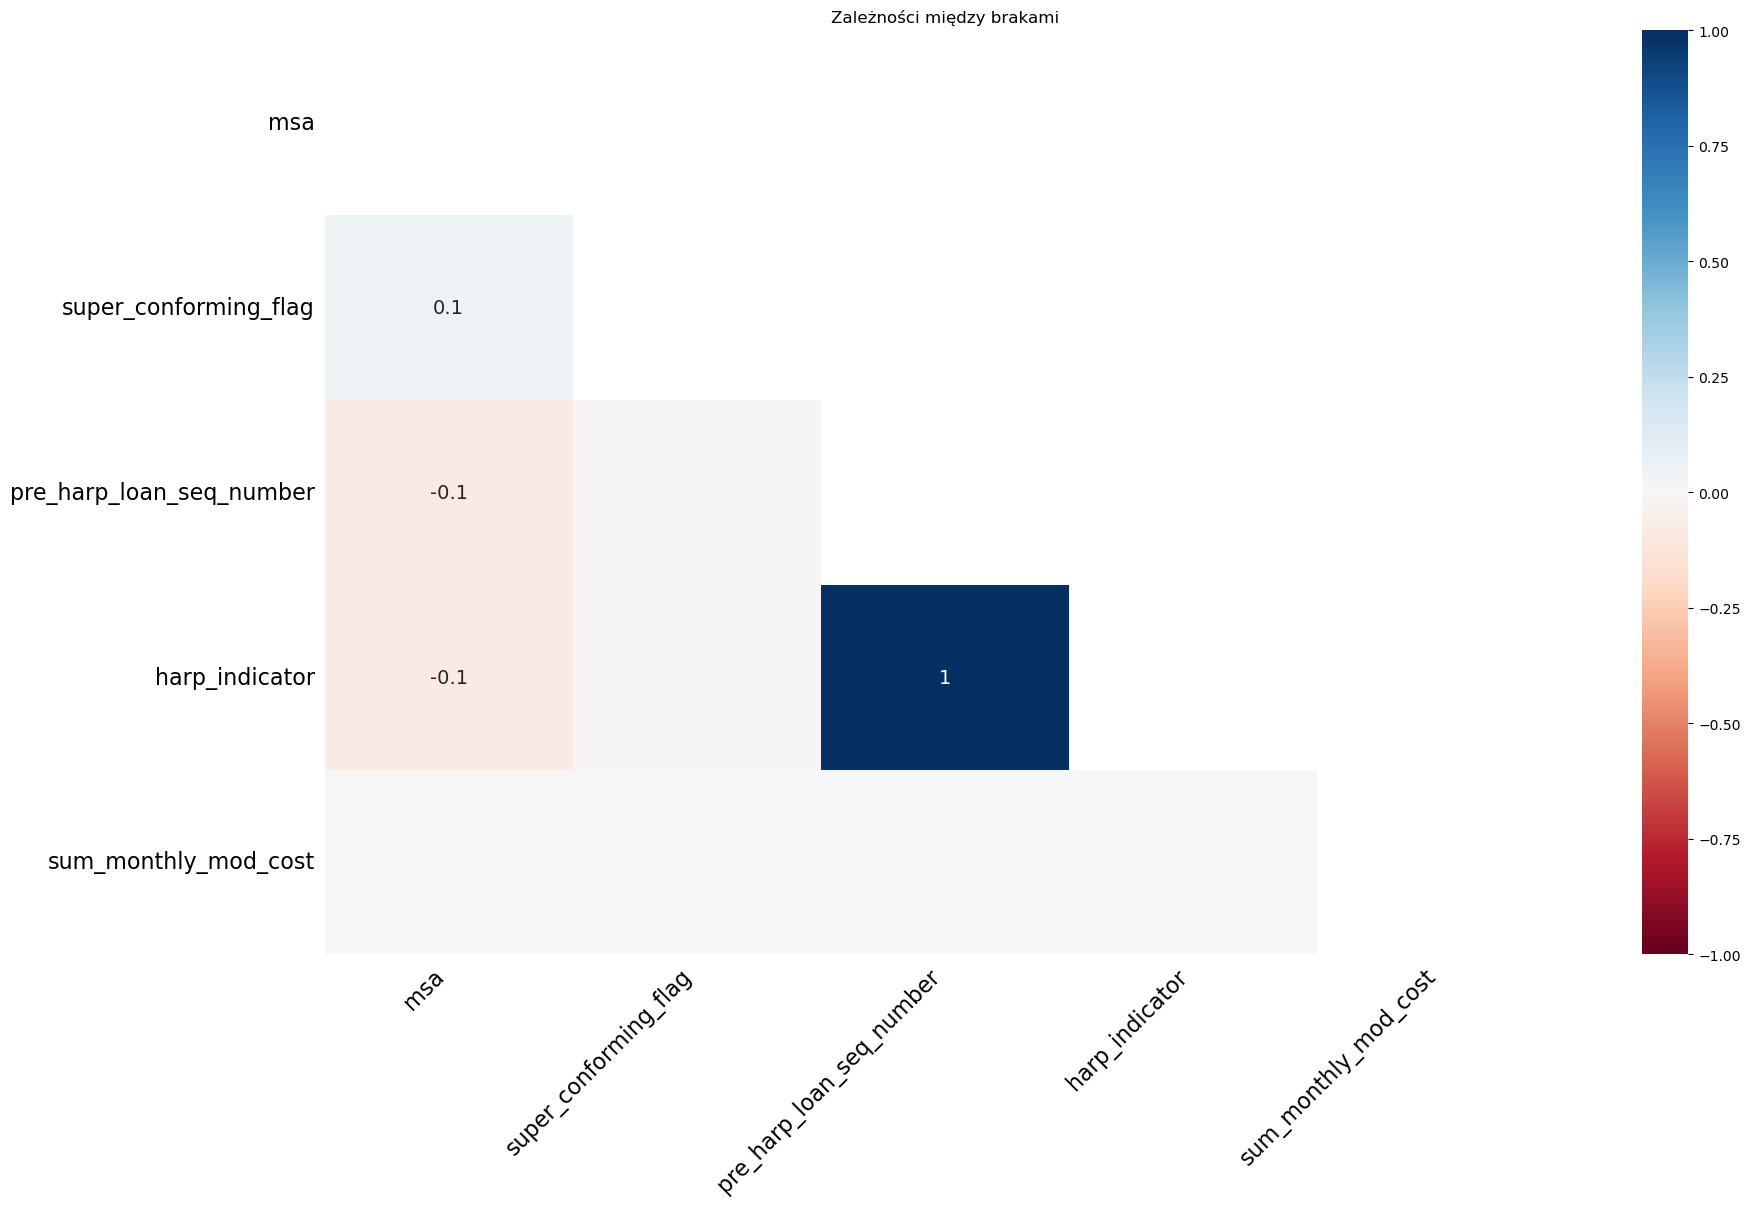

<Figure size 1200x400 with 0 Axes>

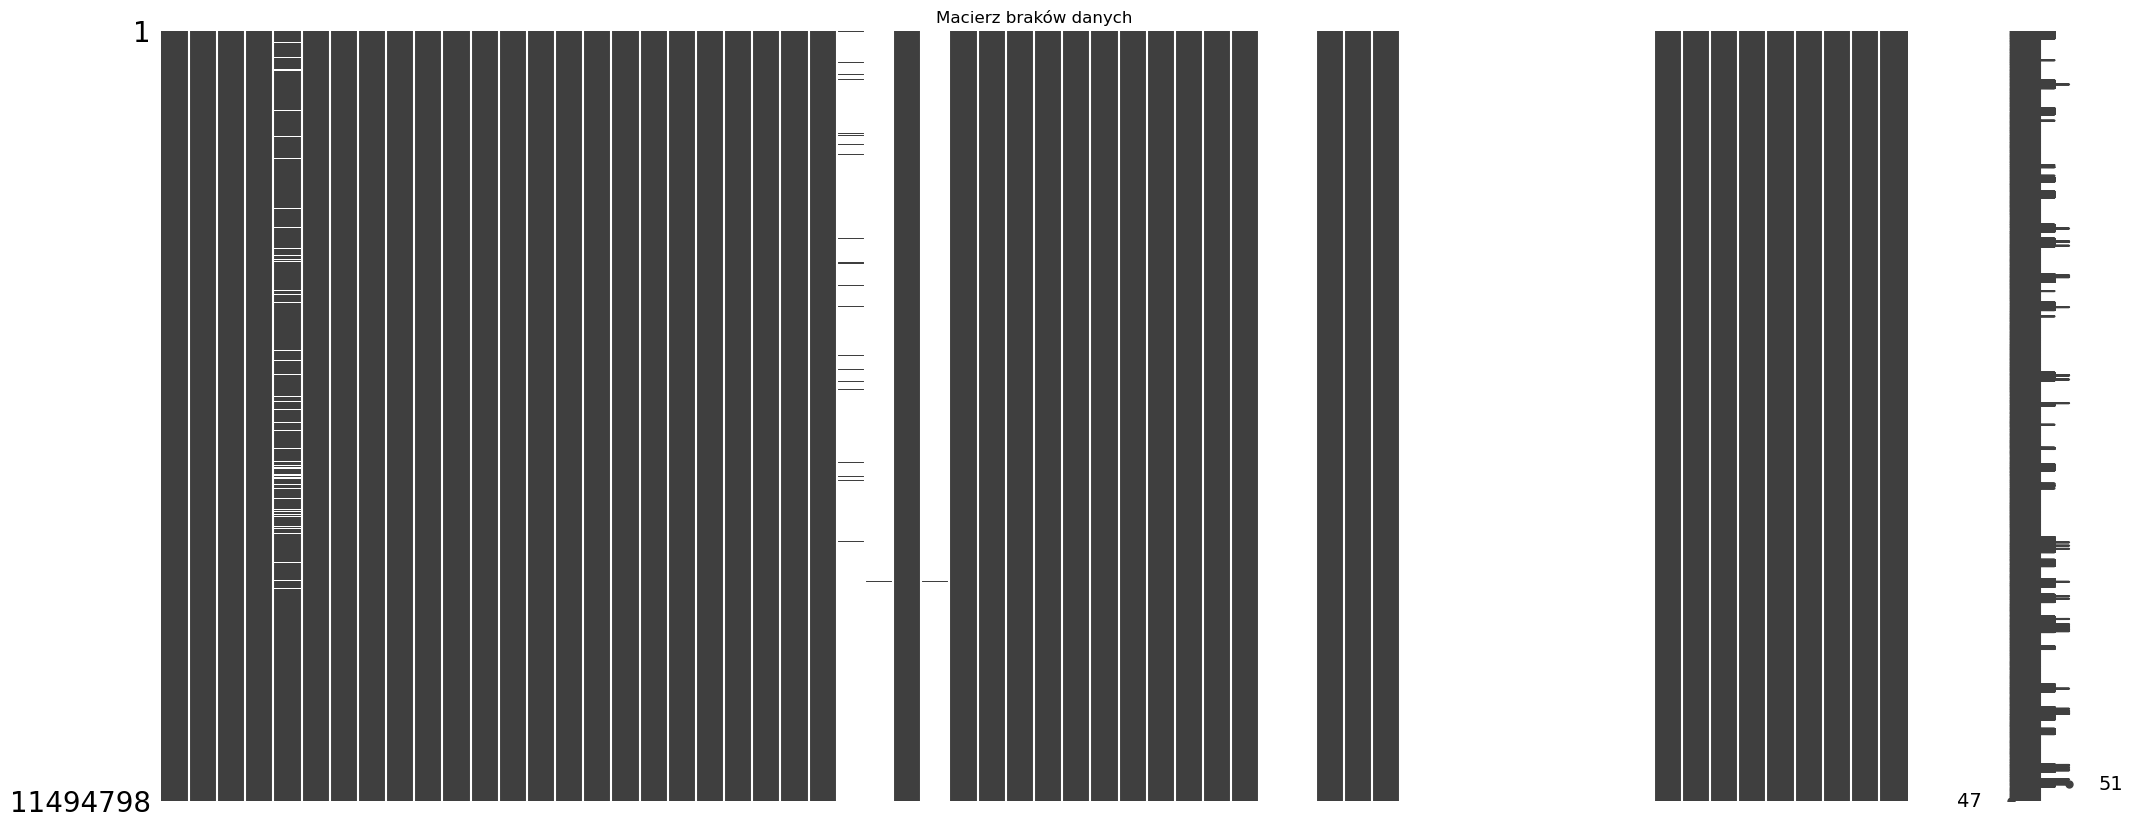

In [1]:
# 2.2 Wizualizacja braków danych
# Heatmapa wygenerowana przez bibliotekę missingno przedstawia korelacje pomiędzy występowaniem braków danych w różnych zmiennych.
# Widoczne są jedynie kolumny zawierające braki.
# Kolorystyka i wartości liczbowej korelacji wskazują, w jakim stopniu braki w jednej zmiennej współwystępują z brakami w innej. 
# Z kolei macierz obecności danych wizualizuje brakujące wartości w układzie kolumny-obserwacje.
# Przeważająca większość zmiennych nie posiada braków, stąd dominacja czarnych (pełnych) pasków.
#==============================================================================================

import duckdb
import pandas as pd
import missingno as msno
import matplotlib.pyplot as plt

# Połączenie i wczytanie danych
con = duckdb.connect()
df = con.execute("""
    SELECT * FROM 'modeling_base.parquet'
""").df()

# Wykluczenie loan_id
excluded = ['loan_id']
df = df.drop(columns=[col for col in df.columns if col.lower() in excluded])

# Heatmapa zależności braków
plt.figure(figsize=(12,6))
msno.heatmap(df)
plt.title("Zależności między brakami")
plt.show()

# Macierz obecności
plt.figure(figsize=(12,4))
msno.matrix(df)
plt.title("Macierz braków danych")
plt.show()


### 2.3. Wstępna weryfikacja mechanizmu braków (MCAR/MAR/MNAR)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))


 Zmienna: msa (braków: 1056637)


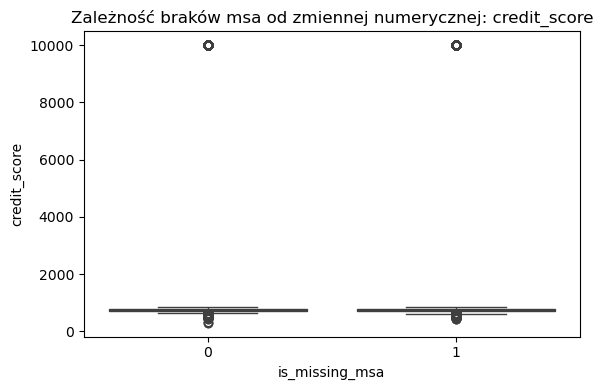

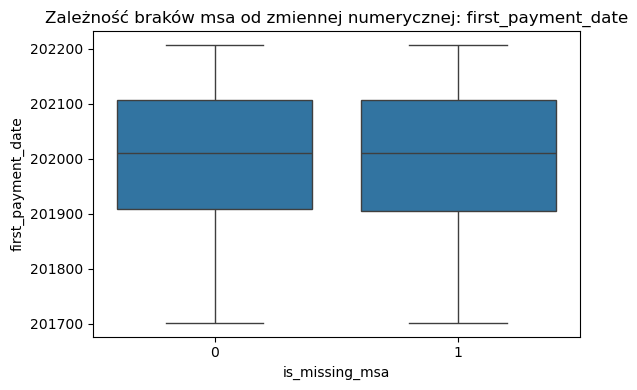

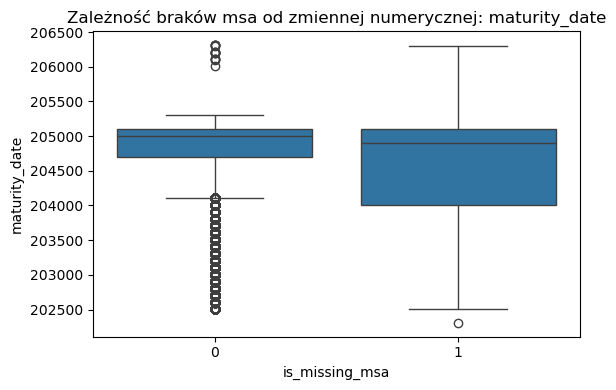

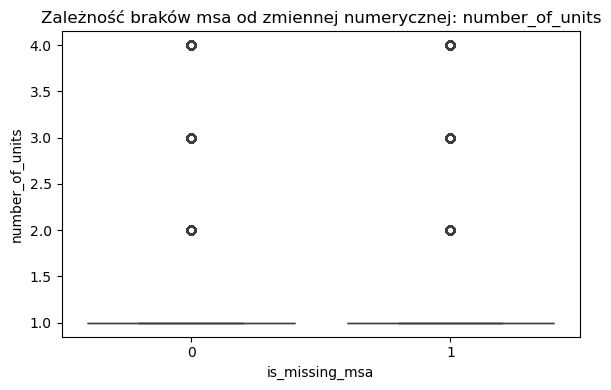

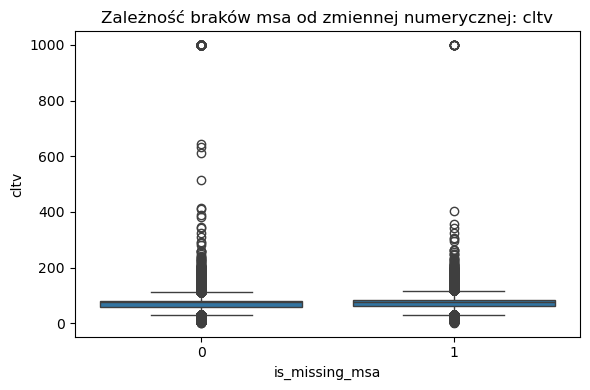

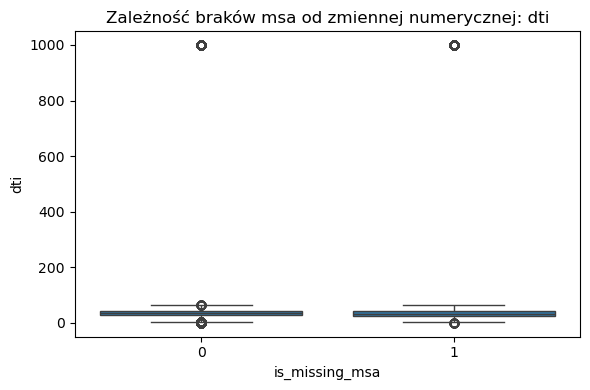

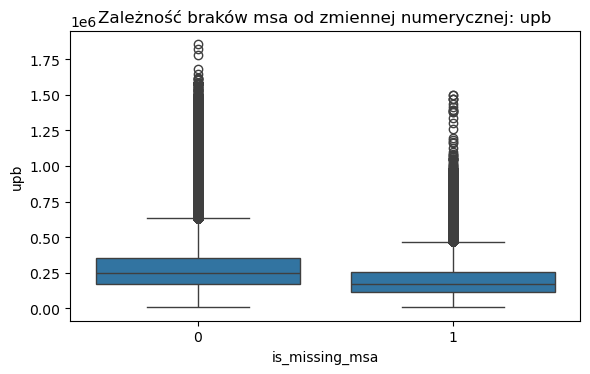

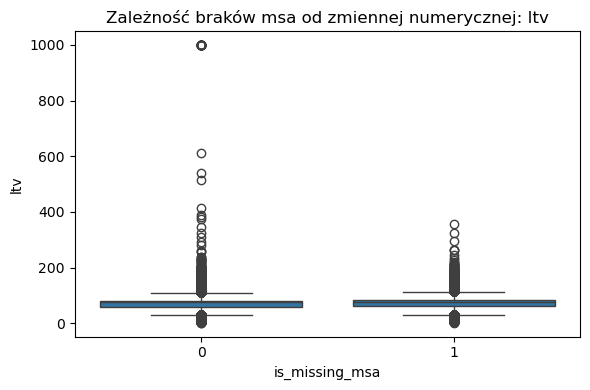

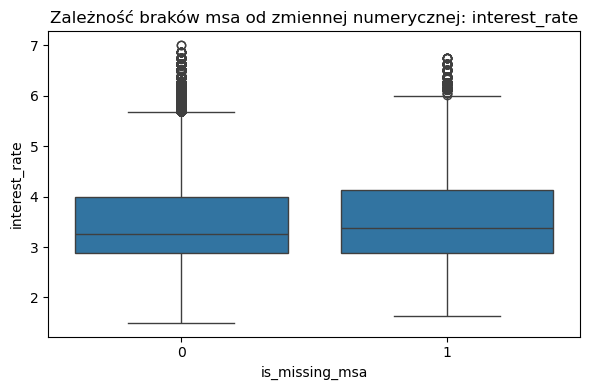

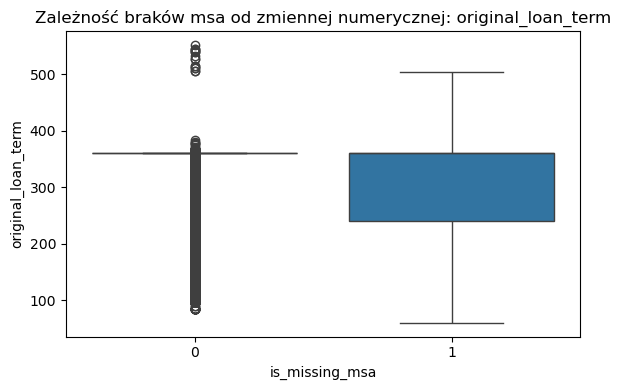

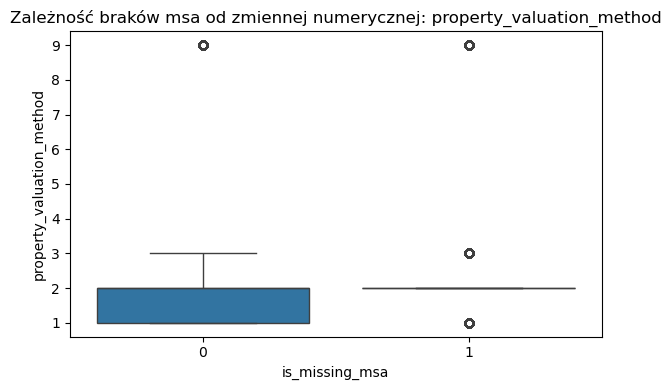

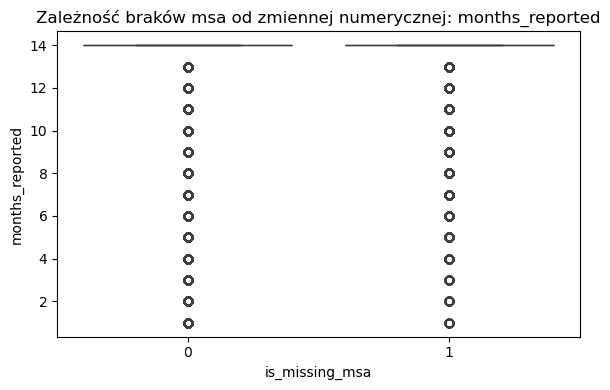

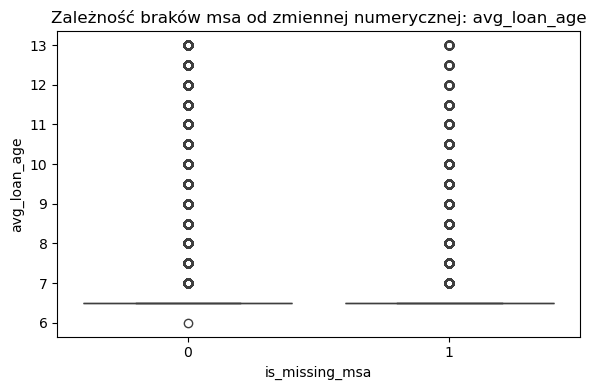

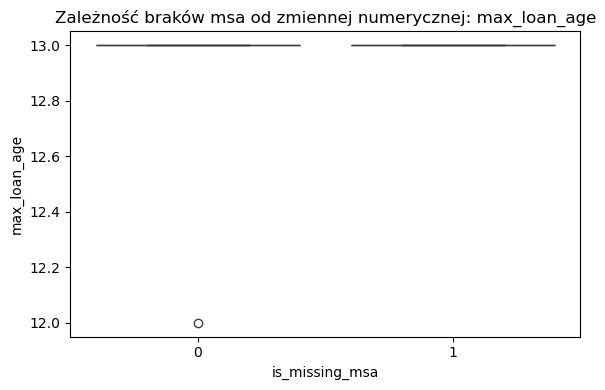

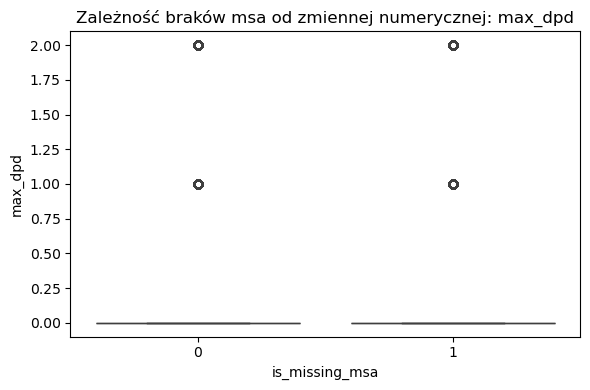

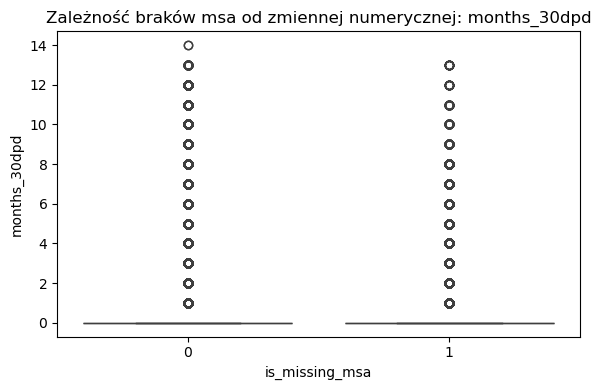

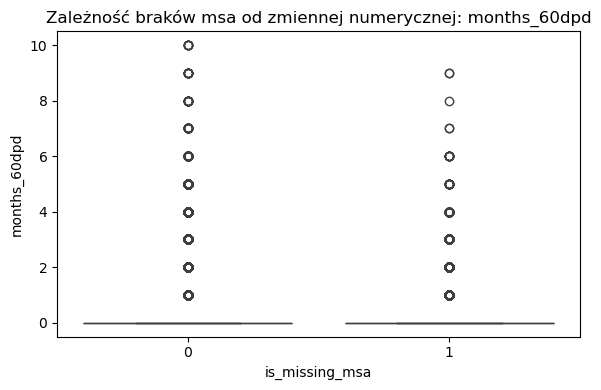

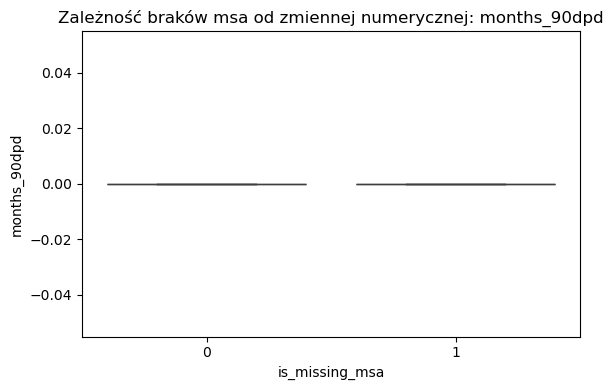

ValueError: List of boxplot statistics and `positions` values must have same the length

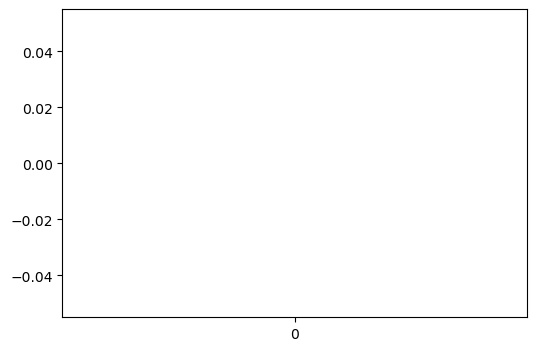

In [1]:
# 2.3 Wstępna weryfikacja mechanizmu braków (MCAR/MAR/MNAR)
#==========================================================
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import duckdb
import missingno as msno

# Połączenie i wczytanie danych
con = duckdb.connect()
df = con.execute("""
    SELECT * FROM 'modeling_base.parquet'
""").df()

# Wykluczenie zmiennych technicznych
excluded = ['loan_id']

# Wybór zmiennych numerycznych i kategorycznych (bez loan_id)
num_vars = [col for col in df.select_dtypes(include=['float64', 'int64']).columns if col.lower() not in excluded]
cat_vars = [col for col in df.select_dtypes(include=['object', 'category']).columns if col.lower() not in excluded]

# Pętla po zmiennych z brakami
for col in df.columns:
    if df[col].isnull().sum() == 0:
        continue  

    # Utworzenie wskaźnika braków
    missing_flag = f'is_missing_{col}'
    df[missing_flag] = df[col].isnull().astype(int)
    
    print(f"\n Zmienna: {col} (braków: {df[col].isnull().sum()})")

    # Zmienna zależna: missing_flag, reszta jako zmienne niezależne

    ## 1. Testy zależności z innymi zmiennymi numerycznymi
    for other in num_vars:
        if other == col:
            continue
        plt.figure(figsize=(6, 4))
        sns.boxplot(x=df[missing_flag], y=df[other])
        plt.title(f'Zależność braków {col} od zmiennej numerycznej: {other}')
        plt.xlabel(missing_flag)
        plt.ylabel(other)
        plt.tight_layout()
        plt.show()

    ## 2. Testy zależności z innymi zmiennymi kategorycznymi
    for other in cat_vars:
        if other == col:
            continue
        if df[other].nunique() > 20:
            continue  # ograniczeie do zmiennych z <=20 unikatowymi wartościami
        print(f"\nTabela krzyżowa: {missing_flag} vs {other}")
        print(pd.crosstab(df[missing_flag], df[other], normalize='index').round(2))

## 3. Statystyki opisowe dla zmiennych liczbowych

### 3.1 Podstawowe statystyki

In [ ]:
# ###################################################
# # 3.A STATYSTYKI OPISOWE DLA ZMIENNYCH LICZBOWYCH #
# ###################################################

#     'credit_score', 'cltv', 'dti', 'upb', 'ltv', 'interest_rate',
#     'original_loan_term', 'months_reported', 'avg_loan_age', 'max_loan_age',
#     'max_dpd', 'months_30dpd', 'months_60dpd', 'avg_actual_upb', 'avg_interest_bearing_upb',
#     'avg_estimated_ltv', 'sum_monthly_mod_cost'

# Daty
# 'first_payment_date',  'maturity_date'

# Te zmienne są numeryczne, ale zostaną potraktowane jak kategoryczne: 
# 'msa', 'number_of_units', 'postal_code', 'property_valuation_method'

# Zmienna celu
#  'default_flag'

In [2]:
# 3.A.1 Statystyki opisowe dla zmiennych liczbowych
#==================================================
import duckdb
import pandas as pd

# Wczytanie danych
con = duckdb.connect()
df = con.execute("""
    SELECT * FROM 'final_base.parquet'
""").df()

# Zmienne liczbowe do analizy
true_numeric_cols = [
    'credit_score', 'cltv', 'dti', 'upb', 'ltv', 'interest_rate',
    'original_loan_term', 'months_reported', 'avg_loan_age', 'max_loan_age',
    'max_dpd', 'months_30dpd', 'months_60dpd', 'avg_actual_upb',
    'avg_interest_bearing_upb', 'avg_estimated_ltv', 'sum_monthly_mod_cost'
]
# Statystyki opisowe
desc = df[true_numeric_cols].describe(percentiles=[.01, .05, .25, .5, .75, .95, .99]).T

# Wyświetlenie tabeli
print(desc)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

                               count           mean            std  \
credit_score              11494798.0     753.626078     129.964539   
cltv                      11494798.0      71.852378      17.892997   
dti                       11494798.0      39.064233      69.193245   
upb                       11494798.0  268723.188785  140268.469576   
ltv                       11494798.0      71.618937      17.737668   
interest_rate             11494798.0       3.467791       0.789009   
original_loan_term        11494798.0     321.699446      71.352455   
months_reported           11494798.0      13.906890       0.491493   
avg_loan_age              11494798.0       6.546555       0.245747   
max_loan_age              11494798.0      13.000000       0.000295   
max_dpd                   11494798.0       0.035095       0.195717   
months_30dpd              11494798.0       0.050034       0.351833   
months_60dpd              11494798.0       0.002816       0.069451   
avg_actual_upb      

### 3.2 Przedziały wartości

In [ ]:
# 3.A.2 Tabele częstości dla zmiennych liczbowych (przedziały)
# Tworzy przedziały wartości (bins=10) i pokazuje liczbę obserwacji
#=================================================
import duckdb
import pandas as pd
import numpy as np

# Inicjalizacja danych
con = duckdb.connect()
final_base = con.execute("""
    SELECT * FROM read_parquet('final_base.parquet')
""").df()

# Zmienne:
num_cols = [
    'credit_score', 'cltv', 'dti', 'upb', 'ltv', 'interest_rate',
    'original_loan_term', 'months_reported', 'avg_loan_age', 'max_loan_age',
    'max_dpd', 'months_30dpd', 'months_60dpd', 'avg_actual_upb',
    'avg_interest_bearing_upb', 'avg_estimated_ltv', 'sum_monthly_mod_cost'
]

# Tworzenie przedziałów i wyświetlanie ich liczebności
for col in num_cols:
    try:
        print(f"\n Przedziały wartości dla: {col}")
        binned = pd.cut(final_base[col], bins=10)
        display(binned.value_counts(dropna=False).sort_index().to_frame(name='liczba_obserwacji'))
    except Exception as e:
        print(f"Błąd w zmiennej {col}: {e}")
        continue

### 3.3. Najczęstsze wartości

In [1]:
# 3.A.3  Najczęstsze wartości dla zmiennych liczbowych
# Wyświetla 10 najczęstszych wartości dla każdej zmiennej numerycznej
# Pomija zmienne techniczne typu loan_id, postal_code
#====================================================

import matplotlib.pyplot as plt
import duckdb
import pandas as pd

# Połączenie z bazą i wczytanie danych
con = duckdb.connect()
df = con.execute("""
    SELECT * FROM 'modeling_base.parquet'
""").df()

# Zmienne:
numeric_cols = [
    'first_payment_date',  'maturity_date',
    'credit_score', 'cltv', 'dti', 'upb', 'ltv', 'interest_rate',
    'original_loan_term', 'months_reported', 'avg_loan_age', 'max_loan_age',
    'max_dpd', 'months_30dpd', 'months_60dpd', 'avg_actual_upb',
    'avg_interest_bearing_upb', 'avg_estimated_ltv', 'sum_monthly_mod_cost'
]

# Wyświetlenie najczęstszych wartości
for col in numeric_cols:
    print(f"\n Top wartości dla zmiennej liczbowej: {col}")
    print(df[col].value_counts(dropna=False).head(20))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))


 Top wartości dla zmiennej liczbowej: first_payment_date
first_payment_date
202105    410460
202012    405054
202102    385300
202011    377277
202101    365873
202104    365266
202103    356428
202010    343318
202110    342822
202111    336073
202108    324694
202009    317652
202112    309519
202008    309042
202109    302619
202106    300046
202107    271221
202201    267733
202202    246085
202007    232247
Name: count, dtype: int64

 Top wartości dla zmiennej liczbowej: maturity_date
maturity_date
205011    294109
205101    291649
205104    291628
205010    271548
205012    269370
205103    266502
205102    266460
205109    261362
205110    254218
205107    245159
205009    242197
205111    230704
205108    230677
205008    223528
205007    217653
205105    209626
205112    201008
205106    196061
205201    190766
205006    163405
Name: count, dtype: int64

 Top wartości dla zmiennej liczbowej: credit_score
credit_score
801    141583
790    134988
797    133556
787    131034
791

### 3.4. Histogramy

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

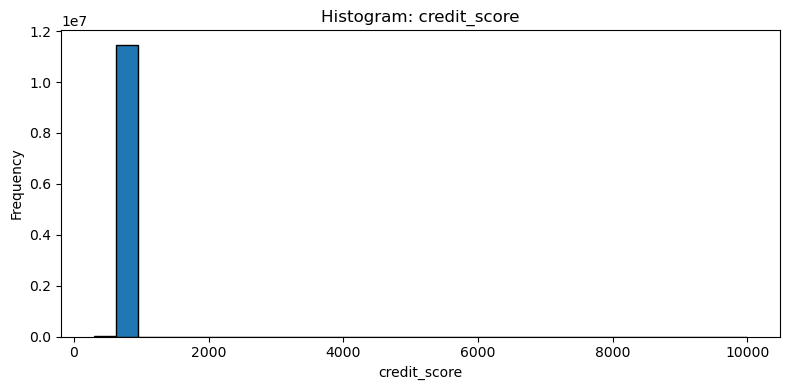

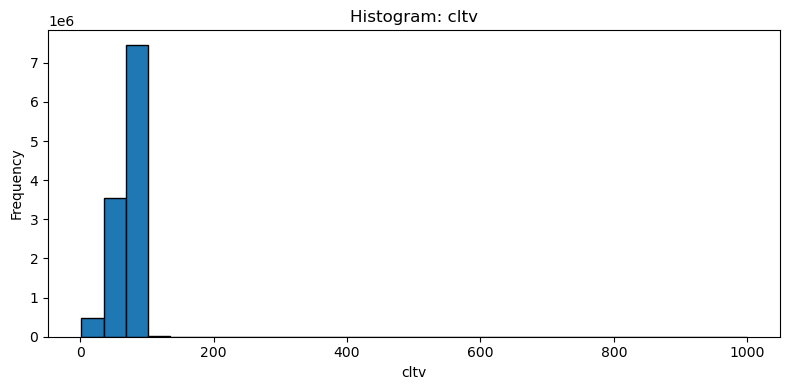

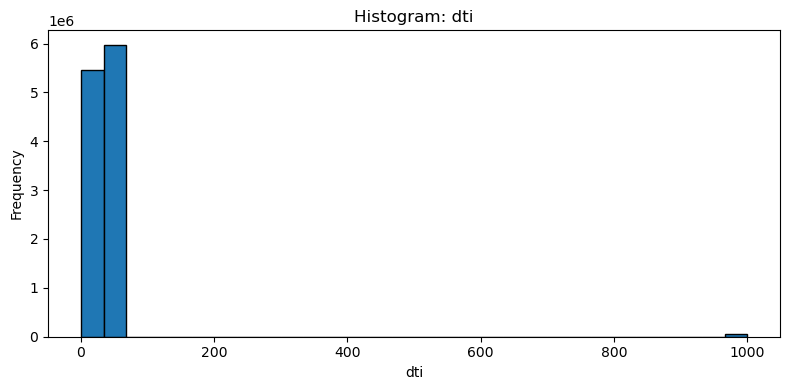

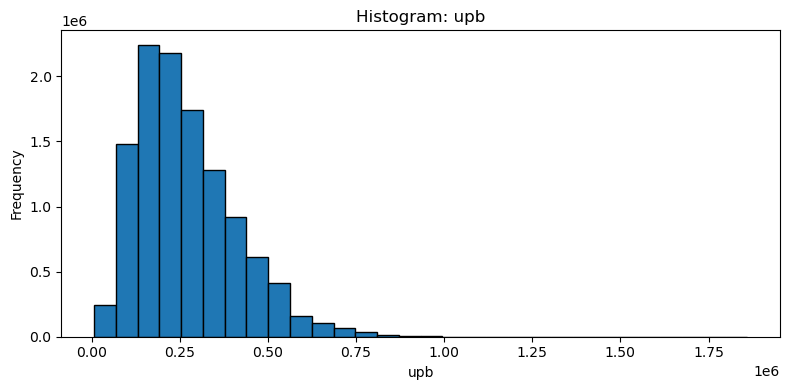

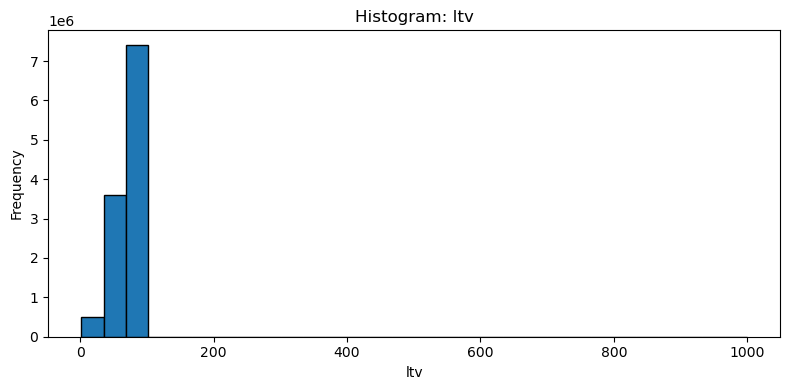

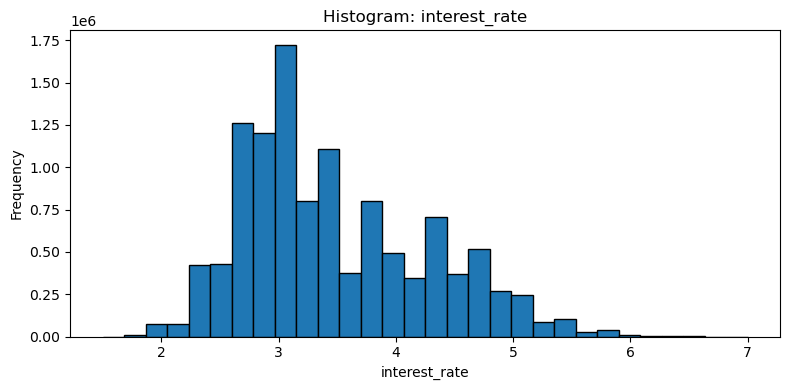

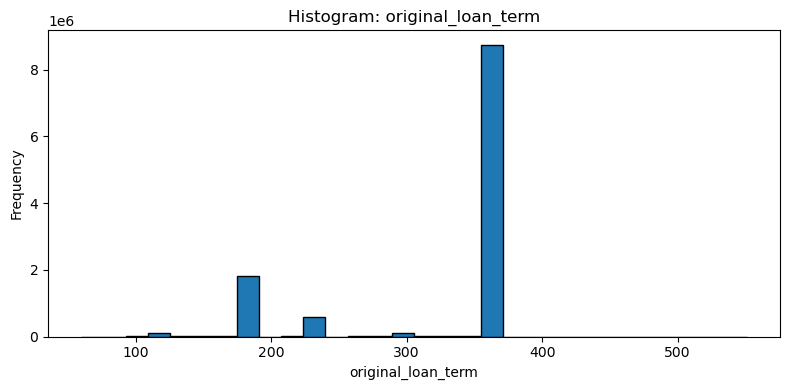

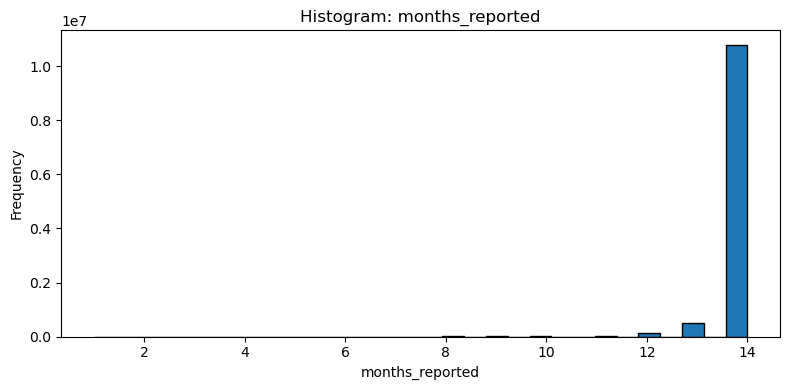

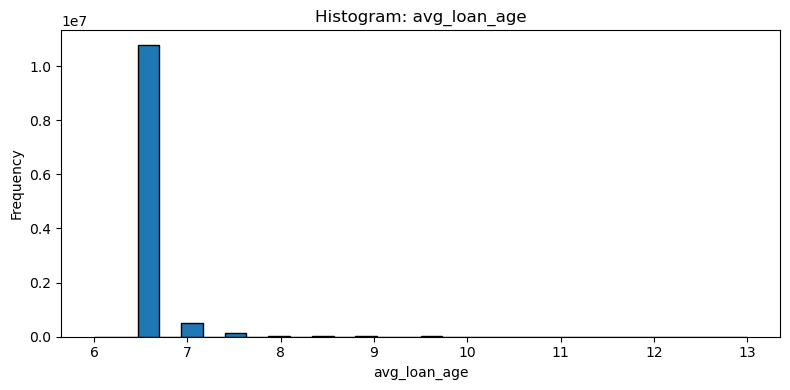

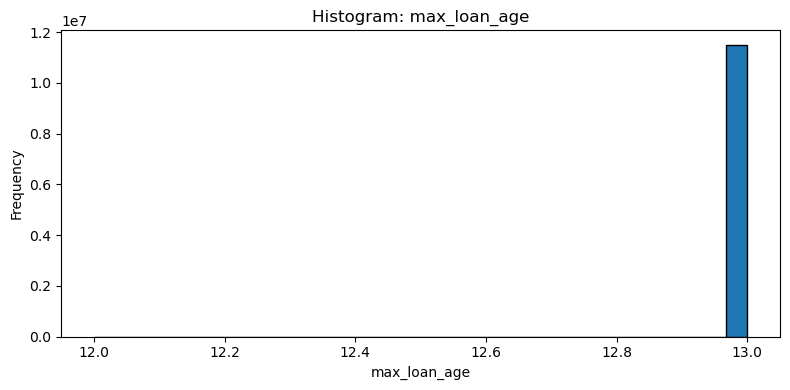

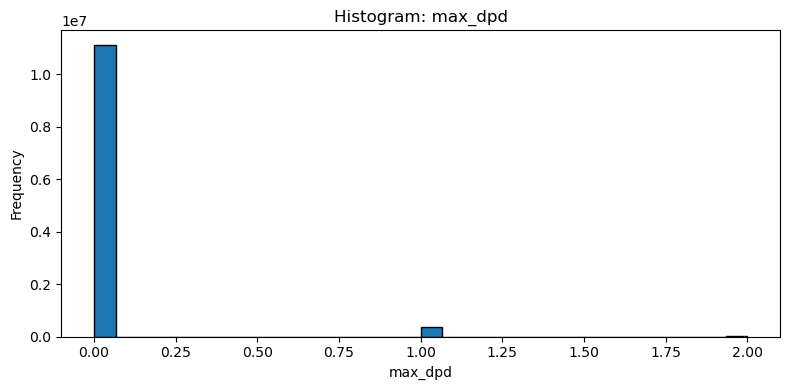

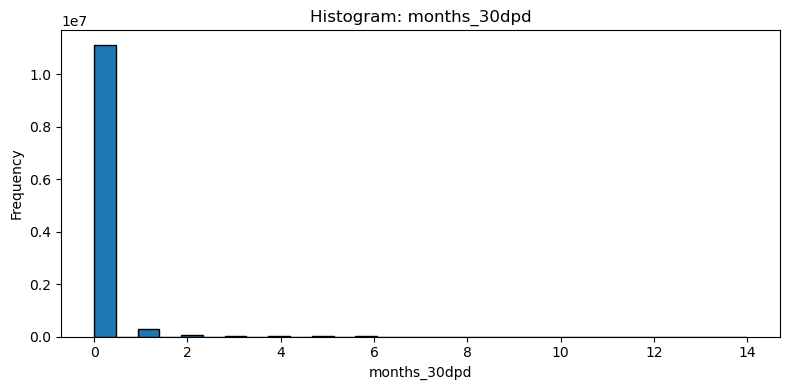

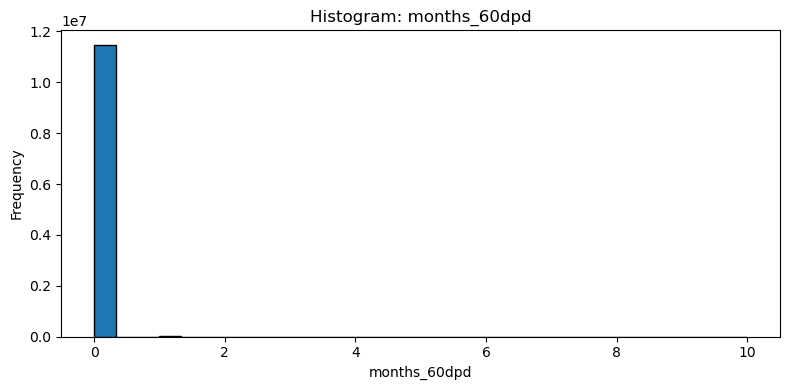

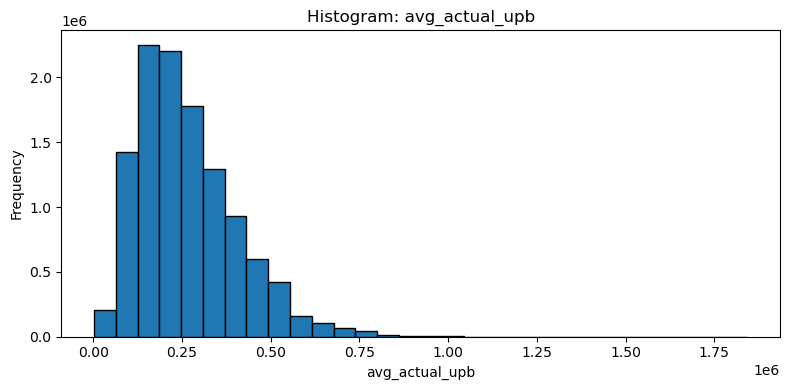

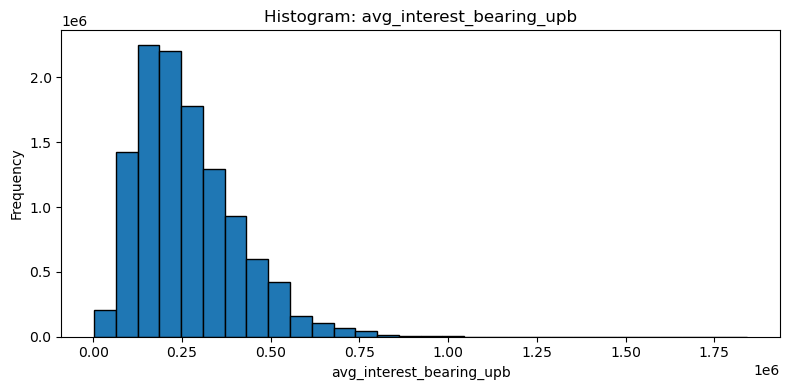

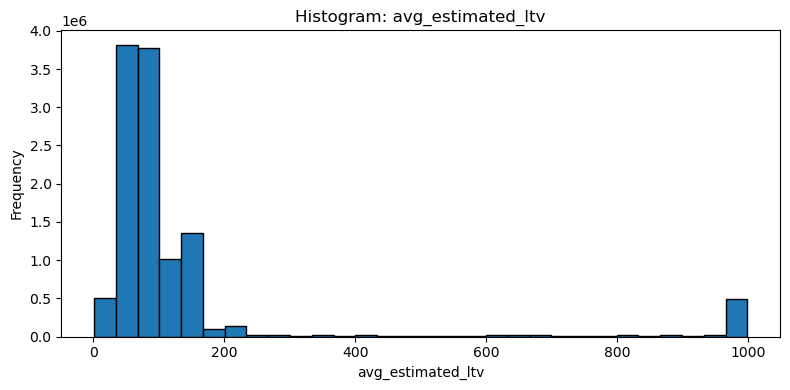

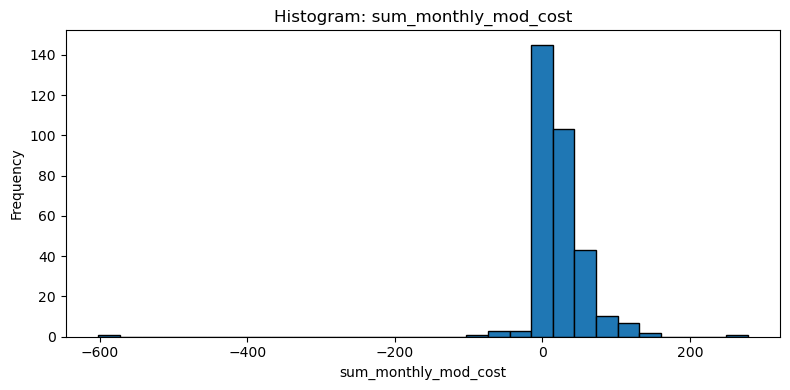

In [2]:
# 3.A.4 Histogramy dla zmiennych liczbowych
# =========================================

import duckdb
import pandas as pd
import matplotlib.pyplot as plt
import os

# Wczytanie danych
con = duckdb.connect()
df = con.execute("""
    SELECT * FROM read_parquet('final_base.parquet')
""").df()

# Tworzenie folderu na wykresy, jeśli nie istnieje
output_dir = ''
os.makedirs(output_dir, exist_ok=True)

# Lista wybranych zmiennych liczbowych
numeric_cols = [
    'credit_score', 'cltv', 'dti', 'upb', 'ltv', 'interest_rate',
    'original_loan_term', 'months_reported', 'avg_loan_age', 'max_loan_age',
    'max_dpd', 'months_30dpd', 'months_60dpd', 'avg_actual_upb',
    'avg_interest_bearing_upb', 'avg_estimated_ltv', 'sum_monthly_mod_cost'
]

# Tworzenie i zapisywanie histogramów
for col in numeric_cols:
    plt.figure(figsize=(8, 4))
    df[col].hist(bins=30, edgecolor='black')
    plt.title(f'Histogram: {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.grid(False)
    plt.tight_layout()
    plt.savefig(os.path.join(output_dir, f'histogram_{col}.png'))
    plt.show()
    plt.close()

### 3.5. Wykresy dla zmiennych czasowych (daty)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

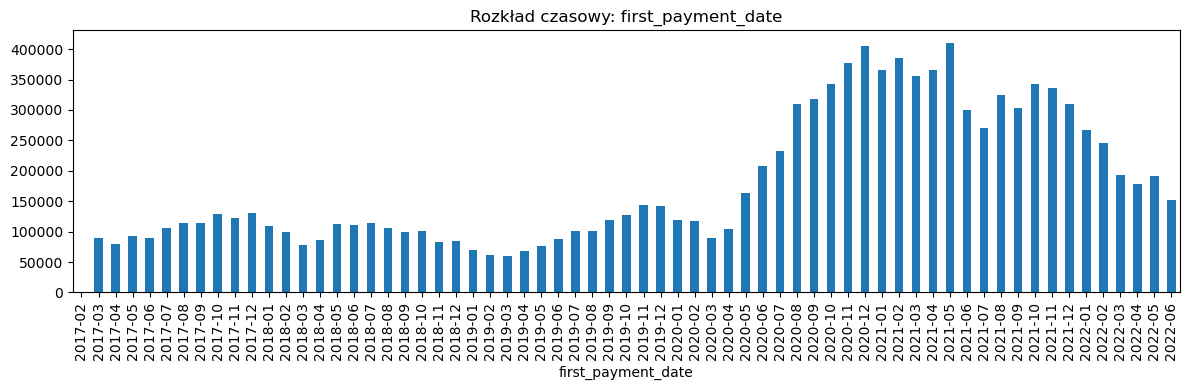

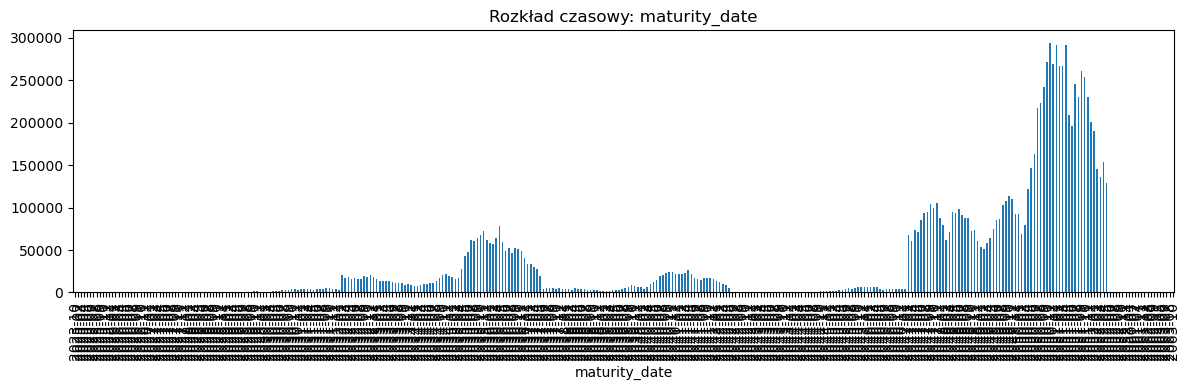

In [3]:
# 3.A.5 Wykresy dla dat (first_payment_date, maturity_date)
#==========================================================
import numpy as np
# Inicjalizacja i załadowanie danych z DuckDB
import duckdb
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

con = duckdb.connect()
final_base = con.execute("""
    SELECT * FROM read_parquet('final_base.parquet')
""").df()

dates = ['first_payment_date', 'maturity_date']

# Daty
for col in dates:
    if col in final_base.columns:
        try:
            df_date = final_base[col].dropna().astype(int).astype(str)
            date_converted = pd.to_datetime(df_date, format='%Y%m')
            date_counts = date_converted.dt.to_period("M").value_counts().sort_index()
            date_counts.plot(kind='bar', figsize=(12, 4), title=f"Rozkład czasowy: {col}")
            plt.tight_layout()
            plt.show()
        except Exception as e:
            print(f"Błąd konwersji kolumny {col}: {e}")

## 4. Statystyki opisowe dla zmiennych kategorycznych

In [ ]:
#######################################################
# 3.B STATYSTYKI OPISOWE DLA ZMIENNYCH KATEGORYCZNYCH #
#######################################################

    'first_time_homebuyer_flag',
    'number_of_borrowers',
    'mi_percentage',
    'channel',
    'property_state',
    'property_type',
    'loan_purpose',
    'seller_name',
    'servicer_name',
    'occupancy_status',
    'program_indicator',
    'super_conforming_flag',
    'harp_indicator',
    'mi_cancellation_indicator',
    'msa',
    'number_of_units',
    'postal_code',
    'property_valuation_method'    

# Zmienne liczbowe, które zostały potraktowane jako kategoryczne
'msa', 'number_of_units', 'postal_code', 'property_valuation_method'

### 4.1. Tabele częstości

In [1]:
# 3.B.1 Tabele częstości dla zmiennych kategorycznych (value_counts)
# ===================================================================
import duckdb
import pandas as pd

# Inicjalizacja danych
con = duckdb.connect()
final_base = con.execute("""
    SELECT * FROM read_parquet('final_base.parquet')
""").df()

cat_cols = [
    'first_time_homebuyer_flag',
    'number_of_borrowers',
    'mi_percentage',
    'channel',
    'property_state',
    'property_type',
    'loan_purpose',
    'seller_name',
    'servicer_name',
    'occupancy_status',
    'program_indicator',
    'super_conforming_flag',
    'harp_indicator',
    'mi_cancellation_indicator',
    'msa',
    'number_of_units',
    'postal_code',
    'property_valuation_method'
]

# Wyświetlanie częstości
for col in cat_cols:
    print(f"\n Rozkład wartości dla kolumny: {col}")
    display(final_base[col].value_counts(dropna=False).to_frame(name='liczba_obserwacji'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))


 Rozkład wartości dla kolumny: first_time_homebuyer_flag


,liczba_obserwacji
first_time_homebuyer_flag,
N,9528345
Y,1966451
9,2



 Rozkład wartości dla kolumny: number_of_borrowers


,liczba_obserwacji
number_of_borrowers,
01,6076585
02,5341073
03,66708
04,10270
05,161
06,1


...

,liczba_obserwacji
number_of_units,
1,11258782
2,170420
3,37717
4,27879



 Rozkład wartości dla kolumny: postal_code


,liczba_obserwacji
postal_code,
75000,126517
30000,114813
94500,110288
84000,109508
85200,107522
...,...
69200,67
24800,54
10200,49



 Rozkład wartości dla kolumny: property_valuation_method


,liczba_obserwacji
property_valuation_method,
2,8110041
1,3136494
3,244322
9,3941


### 4.2. Najczęstsze wartości

In [1]:
# 3.2 Najczęstsze wartości dla każdej zmiennej kategorycznej
# Wyświetla 10 najczęstszych wartości dla każdej kolumny typu object/category
#============================================================================

import matplotlib.pyplot as plt
import duckdb
import pandas as pd

# Wczytanie danych
con = duckdb.connect()
df = con.execute("""
    SELECT * FROM 'final_base.parquet'
""").df()

categorical_cols = [
    'first_time_homebuyer_flag',
    'number_of_borrowers',
    'mi_percentage',
    'channel',
    'property_state',
    'property_type',
    'loan_purpose',
    'seller_name',
    'servicer_name',
    'occupancy_status',
    'program_indicator',
    'super_conforming_flag',
    'harp_indicator',
    'mi_cancellation_indicator',
    'msa',
    'number_of_units',
    'postal_code',
    'property_valuation_method'
]

# Wyświetlenie 10 najczęstszych wartości dla każdej zmiennej
for col in categorical_cols:
    print(f"\nTop wartości dla zmiennej: {col}")
    print(df[col].value_counts(dropna=False).head(10))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))


Top wartości dla zmiennej: first_time_homebuyer_flag
first_time_homebuyer_flag
N    9528345
Y    1966451
9          2
Name: count, dtype: int64

Top wartości dla zmiennej: number_of_borrowers
number_of_borrowers
01    6076585
02    5341073
03      66708
04      10270
05        161
06          1
Name: count, dtype: int64

Top wartości dla zmiennej: mi_percentage
mi_percentage
000    8659271
25     1112317
30     1096323
12      457762
35       64042
6        49471
18       33526
16       21265
20         598
15          75
Name: count, dtype: int64

Top wartości dla zmiennej: channel
channel
R    6654454
C    3435579
B    1404759
9          6
Name: count, dtype: int64

Top wartości dla zmiennej: property_state
property_state
CA    1423842
TX     847525
FL     768571
IL     491830
OH     433170
MI     400557
AZ     392791
GA     360730
WA     360278
NC     354021
Name: count, dtype: int64

Top wartości dla zmiennej: property_type
property_type
SF    7362147
PU    3162220
CO     899206
M

### 4.3 Wykresy słupkowe

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

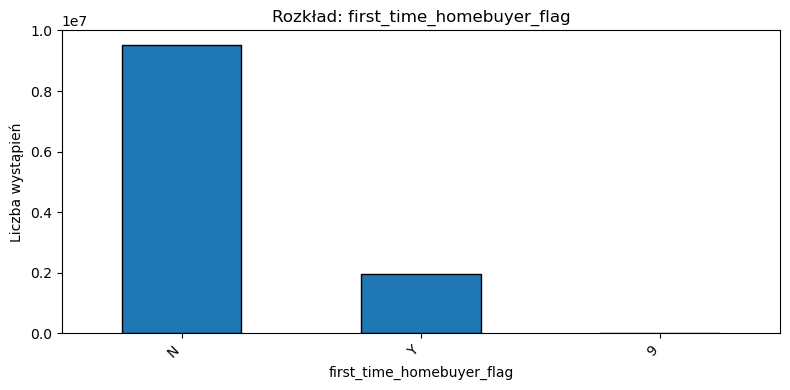

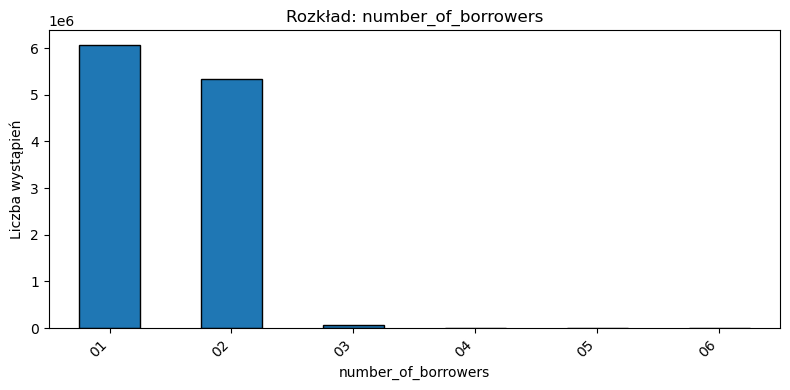

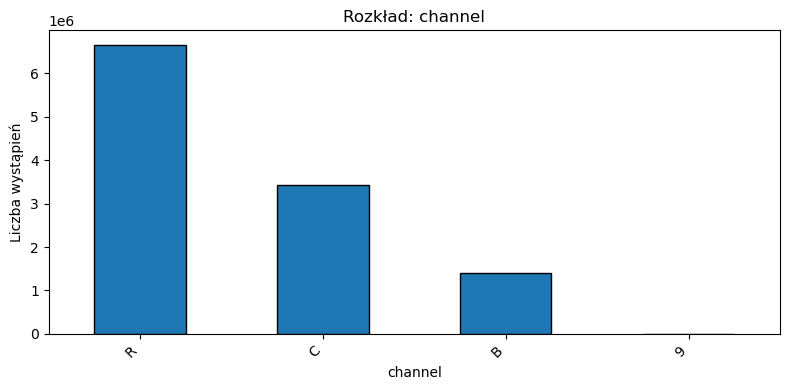

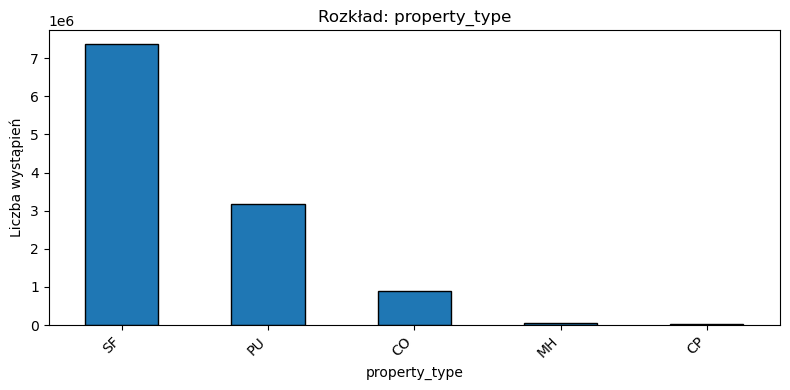

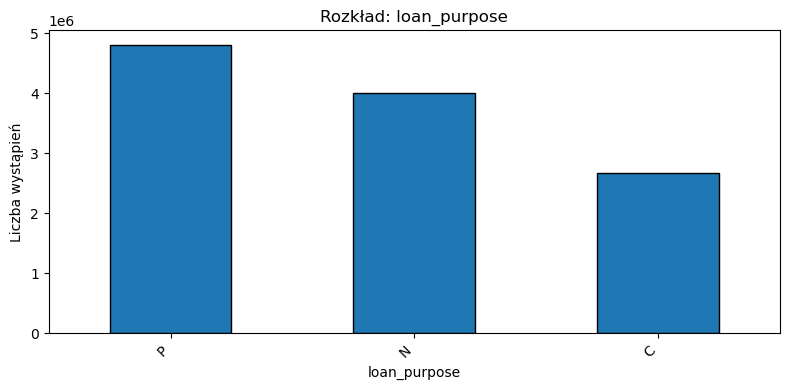

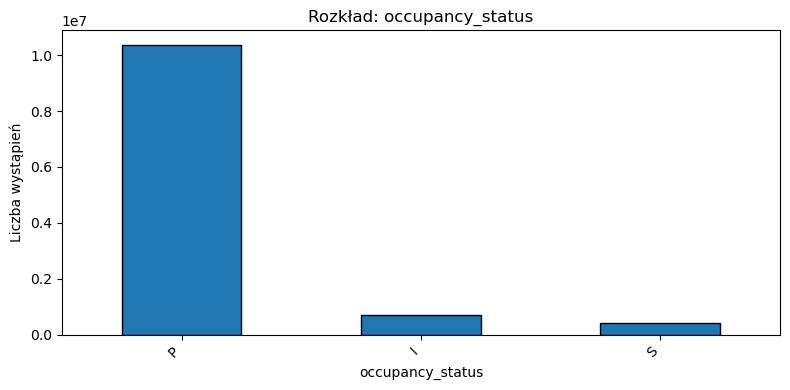

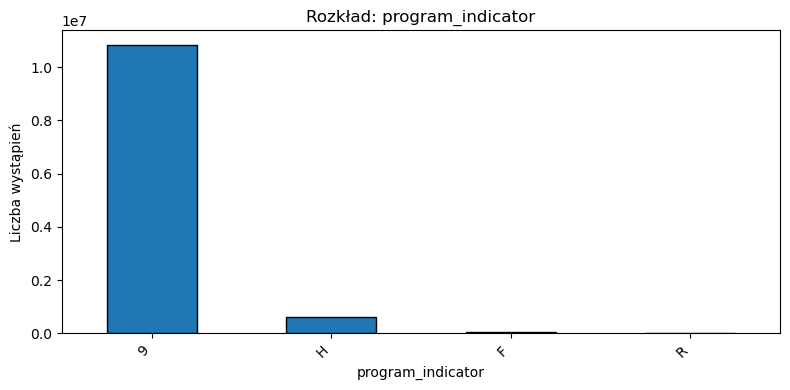

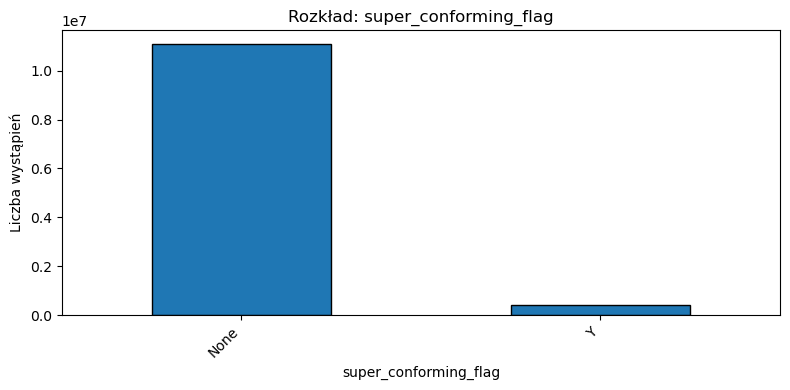

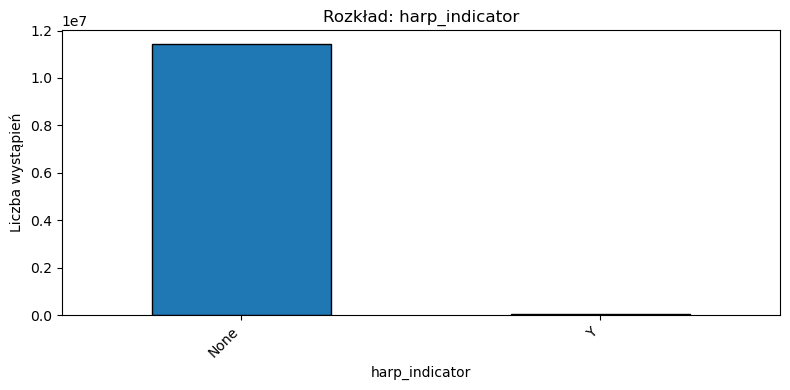

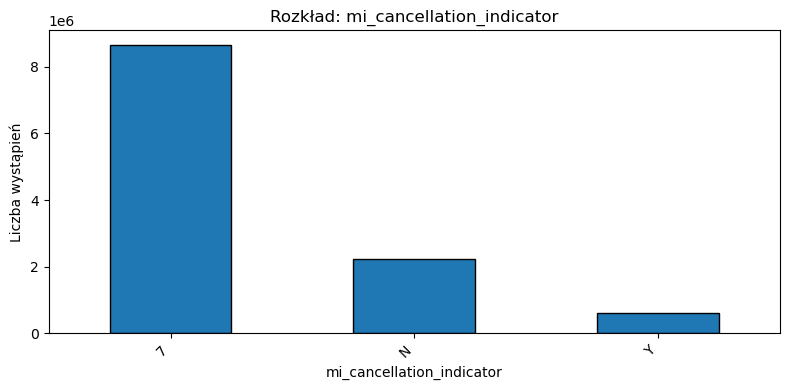

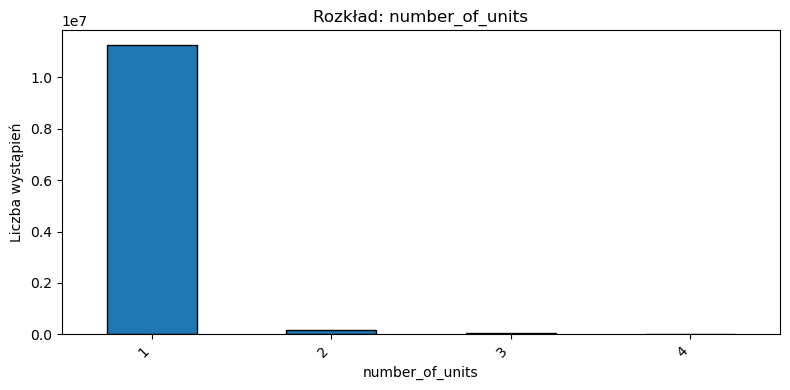

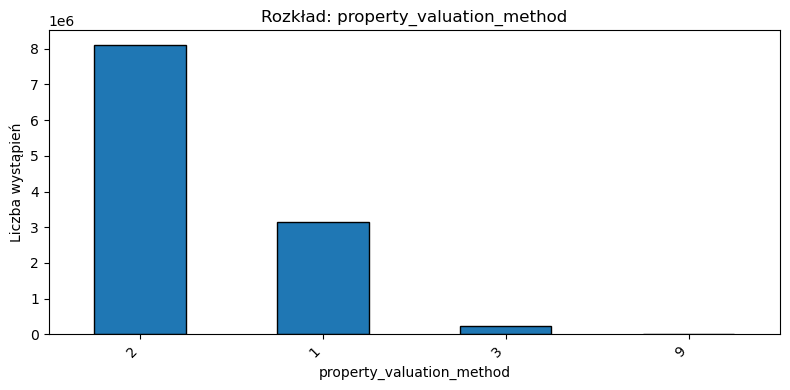

In [1]:
# 4.3 Wykresy słupkowe dla zmiennych kategorycznych
# Tworzy i zapisuje wykresy słupkowe dla zmiennych kategorycznych
#================================================================

import duckdb
import pandas as pd
import matplotlib.pyplot as plt
import os

# Wczytanie danych
con = duckdb.connect()
df = con.execute("""
    SELECT * FROM read_parquet('final_base.parquet')
""").df()

# Tworzenie folderu do zapisu
output_dir = ''
os.makedirs(output_dir, exist_ok=True)

categorical_cols = [
    'first_time_homebuyer_flag',
    'number_of_borrowers',
    'mi_percentage',
    'channel',
    'property_state',
    'property_type',
    'loan_purpose',
    'seller_name',
    'servicer_name',
    'occupancy_status',
    'program_indicator',
    'super_conforming_flag',
    'harp_indicator',
    'mi_cancellation_indicator',
    'msa',
    'number_of_units',
    'postal_code',
    'property_valuation_method'
]

# Tworzenie i zapisywanie wykresów słupkowych
for col in categorical_cols:
    if df[col].nunique(dropna=False) > 20:
        continue  # pominięcie bardzo rzadkich kategorii
    plt.figure(figsize=(8, 4))
    df[col].value_counts(dropna=False).plot(kind='bar', edgecolor='black')
    plt.title(f'Rozkład: {col}')
    plt.xlabel(col)
    plt.ylabel('Liczba wystąpień')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.savefig(os.path.join(output_dir, f'slupkowy_{col}.png'))
    plt.show()
    plt.close()

## 5. Analiza wartości odstających

### 5.1. IQR i percentyle

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

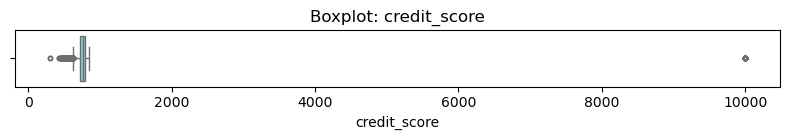

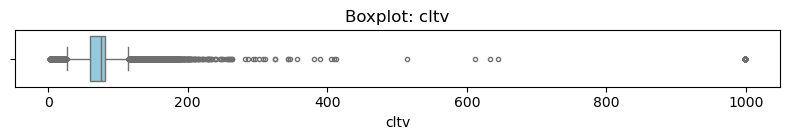

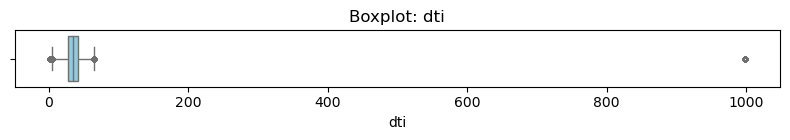

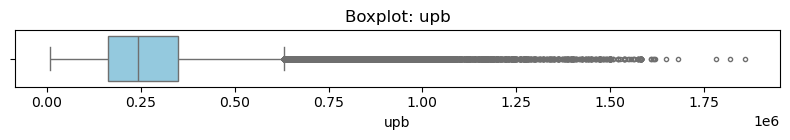

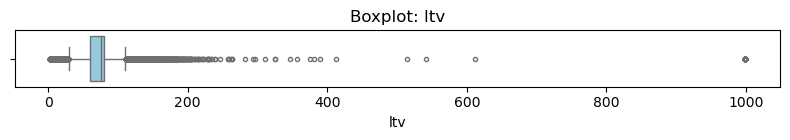

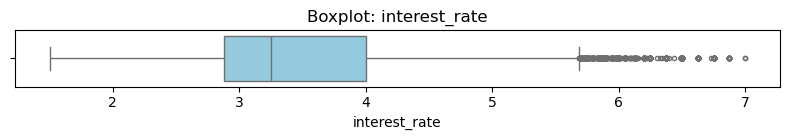

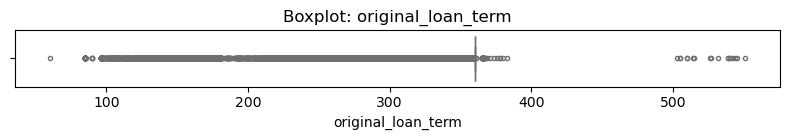

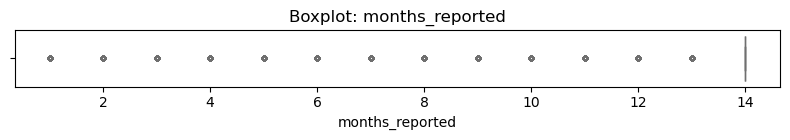

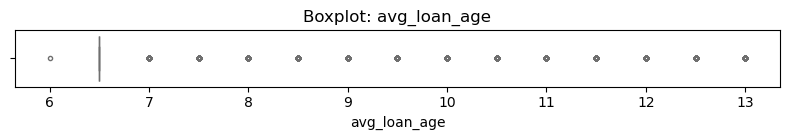

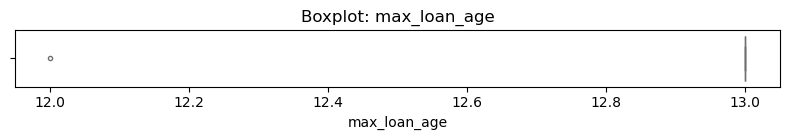

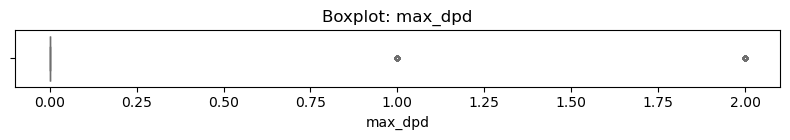

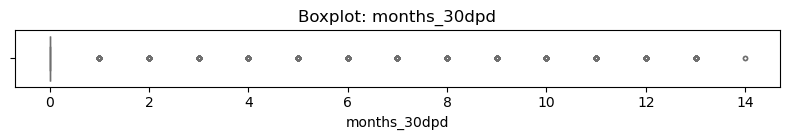

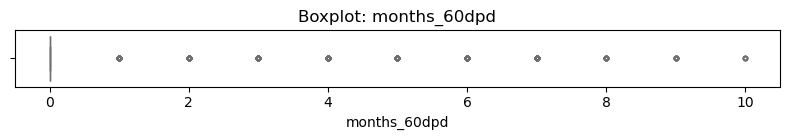

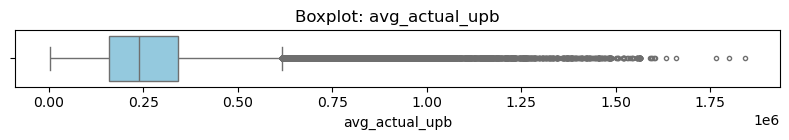

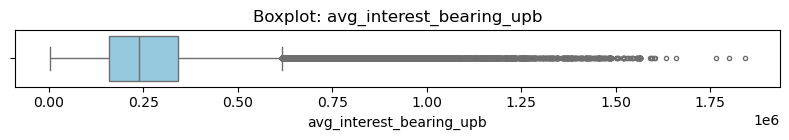

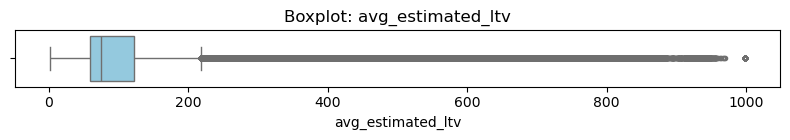

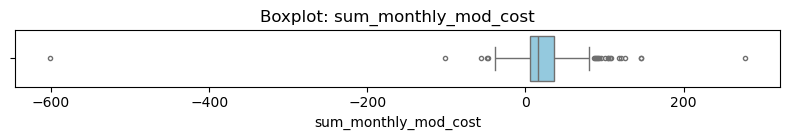

,liczba_outlierów_iqr,liczba_outlierów_percentyl
original_loan_term,2753557,109673
avg_estimated_ltv,826520,114568
avg_loan_age,701299,64034
months_reported,701299,64033
max_dpd,377879,25529
months_30dpd,377879,96818
ltv,265816,106839
avg_actual_upb,230309,229895
avg_interest_bearing_upb,230309,229895
upb,220334,221874


In [2]:
# 5.1 Outliery IQR + percentyle
# ==================================================

import duckdb
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Wczytanie danych
con = duckdb.connect()
df = con.execute("""
    SELECT * FROM read_parquet('final_base.parquet')
""").df()

# Zmienne do analizy
numeric_cols = [
    'credit_score', 'cltv', 'dti', 'upb', 'ltv', 'interest_rate',
    'original_loan_term', 'months_reported', 'avg_loan_age', 'max_loan_age',
    'max_dpd', 'months_30dpd', 'months_60dpd', 'avg_actual_upb',
    'avg_interest_bearing_upb', 'avg_estimated_ltv', 'sum_monthly_mod_cost'
]

# Folder zapisu
output_dir = ""
os.makedirs(output_dir, exist_ok=True)

# Słowniki z liczbą outlierów
iqr_outliers = {}
pct_outliers = {}

# Analiza outlierów
for col in numeric_cols:
    series = df[col].dropna()

    # IQR
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lower_iqr = Q1 - 1.5 * IQR
    upper_iqr = Q3 + 1.5 * IQR
    iqr_outliers[col] = ((series < lower_iqr) | (series > upper_iqr)).sum()

    # Percentyle 1–99
    lower_pct = series.quantile(0.01)
    upper_pct = series.quantile(0.99)
    pct_outliers[col] = ((series < lower_pct) | (series > upper_pct)).sum()

    # Wykres boxplot
    plt.figure(figsize=(8, 1.5))
    sns.boxplot(x=series, color="skyblue", fliersize=3)
    plt.title(f"Boxplot: {col}")
    plt.xlabel(col)
    plt.tight_layout()
    plt.savefig(os.path.join(output_dir, f'boxplot_{col}.png'))
    plt.show()
    plt.close()

# Tabela wyników
iqr_df = pd.DataFrame.from_dict(iqr_outliers, orient='index', columns=['liczba_outlierów_iqr'])
pct_df = pd.DataFrame.from_dict(pct_outliers, orient='index', columns=['liczba_outlierów_percentyl'])
outlier_df = pd.concat([iqr_df, pct_df], axis=1).sort_values(by='liczba_outlierów_iqr', ascending=False)

from IPython.display import display
display(outlier_df)

### 5.2 Udział % wartości odstających

In [3]:
# 5.2 Udział outlierów w %
# Obliczenie liczby i procentu dolnych oraz górnych outlierów dla wybranych zmiennych
#====================================================================================

import duckdb
import pandas as pd

# Wczytanie danych
con = duckdb.connect()
df = con.execute("""
    SELECT * FROM read_parquet('final_base.parquet')
""").df()

# Lista zmiennych liczbowych do analizy
numeric_cols = [
    'credit_score', 'cltv', 'dti', 'upb', 'ltv', 'interest_rate',
    'original_loan_term', 'months_reported', 'avg_loan_age', 'max_loan_age',
    'max_dpd', 'months_30dpd', 'months_60dpd', 'avg_actual_upb',
    'avg_interest_bearing_upb', 'avg_estimated_ltv', 'sum_monthly_mod_cost'
]

# Lista słowników ze statystykami outlierów
outlier_stats = []

for col in numeric_cols:
    series = df[col].dropna()
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers_low = (series < lower_bound).sum()
    outliers_high = (series > upper_bound).sum()
    total = len(series)
    outlier_stats.append({
        'zmienna': col,
        'outliers_low': outliers_low,
        'outliers_high': outliers_high,
        'outliers_total': outliers_low + outliers_high,
        'procent_outlierów': round(100 * (outliers_low + outliers_high) / total, 2)
    })

# Tabela wyników
outlier_summary = pd.DataFrame(outlier_stats)
outlier_summary = outlier_summary.sort_values('procent_outlierów', ascending=False)

from IPython.display import display
display(outlier_summary)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,zmienna,outliers_low,outliers_high,outliers_total,procent_outlierów
6,original_loan_term,2753469,88,2753557,23.95
16,sum_monthly_mod_cost,5,18,23,7.21
15,avg_estimated_ltv,0,826520,826520,7.19
7,months_reported,701299,0,701299,6.10
8,avg_loan_age,1,701298,701299,6.10
10,max_dpd,0,377879,377879,3.29
11,months_30dpd,0,377879,377879,3.29
4,ltv,263608,2208,265816,2.31
13,avg_actual_upb,0,230309,230309,2.00
14,avg_interest_bearing_upb,0,230309,230309,2.00


### 5.3. Sposób postępowania z wartosciami odstającymi

In [ ]:
# STRATEGIA WOBEC WARTOŚCI ODSTAJĄCYCH
#=====================================

# W niniejszej analizie outlierów zastosowano podejście dwustopniowe:
# 1) Walidacja merytoryczna: oceniono, czy wartości skrajne są logiczne i poprawne z punktu widzenia danych kredytowych.
# 2) Walidacja modelowa: dla zmiennych wykorzystywanych przez regresję i sieci neuronowe przewidziano dalsze transformacje (np. log, winsoryzacja), 
# aby ograniczyć wpływ ekstremalnych wartości na uczenie modelu, nawet jeśli nie zostaną one usunięte na tym etapie.

# Walidacja merytoryczna
# 1. original_loan_term:  outliery pozostawione; mimo że część terminów odbiega od dominującej wartości 360 miesięcy (standard dla kredytów hipotecznych),
# dokumentacja Freddie Mac dopuszcza inne terminy (np. 180, 240, 300, 480, 540 czy 551 miesięcy).

# 2. sum_monthly_mod_cost: outliery pozostawione; mimo obecności wartości ekstremalnych (np. < -600),
# zmienna występuje tylko w 319 przypadkach, więc każda obserwacja może nieść istotną informację.
# Ujemne lub wysokie wartości mogą wynikać z indywidualnych modyfikacji kosztów, a nie z błędów danych.

# 3. avg_estimated_ltv: outliery pozostawione. Wartość 999 zgodnie z dokumentacją Freddie Mac oznacza brak danych.

# 4. months_reported: outliery pozostawione; niższe wartości wynikają z krótszego okresu istnienia kredytu
# i są zgodne z logiką danych – nie stanowią anomalii ani błędów.

# 5. avg_loan_age: outliery pozostawione; wyższe wartości to starsze kredyty – są poprawne i potencjalnie predykcyjne.

# 6. max_dpd: outliery pozostawione; wartości mieszczą się w zakresie 0–2, są informacyjne i nie stanowią błędów.

# 7. months_30dpd: outliery pozostawione; wyższe wartości oznaczają liczbę miesięcy z przeterminowaniem 30+ dni,
# co stanowi ważny sygnał ryzyka – obserwacje są poprawne, mimo rzadkości.

# 8. ltv: outliery pozostawione. Wartość 999 zgodnie z dokumentacją Freddie Mac oznacza brak danych.

# 9. avg_actual_upb: outliery pozostawione; wyższe wartości (nawet powyżej 1 mln USD) mogą występować w przypadku dużych kredytów hipotecznych i nie stanowią błędów danych.
# Są one zgodne z profilem portfela Freddie Mac i mogą mieć znaczenie prognostyczne w kontekście oceny ryzyka kredytowego.

# 10. avg_interest_bearing_upb: outliery pozostawione; wysokie wartości (nawet >1 mln USD) występują w przypadku dużych kredytów
# i są zgodne z dokumentacją Freddie Mac. Nie są to błędy danych, lecz obserwacje typowe dla niektórych segmentów portfela.

# 11. upb: outliery pozostawione; wysokie wartości salda głównego (UPB) powyżej 1 mln USD są typowe dla dużych kredytów hipotecznych.
# Dane te są zgodne z dokumentacją Freddie Mac i mogą mieć znaczenie predykcyjne — nie stanowią błędów ani anomalii.

# 12. cltv:  outliery pozostawione; wyższe wartości cltv odzwierciedlają relację między sumą zadłużenia a wartością nieruchomości,
# co może wskazywać na większe ryzyko kredytowe. Wartość 999 zgodnie z dokumentacją Freddie Mac oznacza brak danych.

# 13. dti: outliery pozostawione; wyższe wartości cltv odzwierciedlają relację między sumą zadłużenia a wartością nieruchomości,
# co może wskazywać na większe ryzyko kredytowe. Wartość 999 zgodnie z dokumentacją Freddie Mac oznacza brak danych.

# 14. outliery usunięte; wartości powyżej 6.5–7% są ekstremalne w kontekście standardowych warunków kredytów hipotecznych Freddie Mac z lat 2017–2022.
# Wysokie stopy procentowe mogą wskazywać na błędy rejestracji lub niereprezentatywne przypadki spoza głównego rozkładu portfela.

# 15. usunięto wartości poniżej 300 i powyżej 900 – zakres ten wykracza poza standardową skalę punktacji kredytowej (300–850/900),
# a skrajnie wysokie wartości (np. 9999) najprawdopodobniej oznaczają brak danych lub błędną imputację.

# 16. months_60dpd: outliery pozostawione; #wyższe wartości oznaczają liczbę miesięcy z przeterminowaniem 60+ dni – 
# są rzadkie, ale bardzo istotne z perspektywy oceny ryzyka kredytowego.

# 17. max_loan_age: zmienna informuje o maksymalnym możliwym wieku kredytu w zbiorze i nie wnosi informacji różnicującej między przypadkami.
# Modelowo: brak wariancji czyni ją nieprzydatną predykcyjnie; zostanie usunięta z bazy modelowej.

# Walidacja modelowa dla regresji logistycznej i sieci neuronowych:

# original_loan_term: duża liczba unikalnych wartości może być problematyczna; zalecana transformacja do zmiennej kategorycznej lub binning (np. <=240, 360, >360)
# sum_monthly_mod_cost: outliery skrajne (poniżej -600 i powyżej 270) zostały usunięte – ekstremalne wartości mogą wynikać z błędów agregacji lub księgowania.
#  avg_estimated_ltv: usunięto obserwacje z wartościami powyżej 200 – dokumentacja wskazuje na możliwe występowanie nienaturalnie wysokich wartości (np. domyślnie przypisanych 999).
# months_reported: outliery dolne nie są usuwane – niosą informację o czasie życia kredytu po cutoffie. Stanowią potencjalnie silny sygnał predykcyjny i nie wskazują na błędy w danych.
# avg_loan_age: pozostawiono outliery – wartości odstające (powyżej 7.5 roku) odpowiadają starszym kredytom i mogą zawierać istotną informację prognostyczną.
# max_dpd: nie ma potrzeby transformacji ani usuwania obserwacji. Wartości odstające (1 i 2) wskazują na przekroczenia granic opóźnienia i mogą odzwierciedlać różne stopnie problemów ze spłatą.
# months_30dpd: pozostawiono outliery - niski odsetek obserwacji odstających (3.3%) i sensowny rozkład, nie ma konieczności transformacji ani usuwania.
# ltv: outliery pozostawione. Wartość 999 zgodnie z dokumentacją Freddie Mac oznacza brak danych.
# avg_actual_upb: usunięto obserwacje powyżej 1 000 000 – ekstremalnie wysokie wartości mogą destabilizować modele..
# avg_interest_bearing_upb: analogicznie do avg_actual_upb – usunięto wartości powyżej 1 000 000.
# credit_score: usunięto wartości poniżej 300 i powyżej 900 – mogą wskazywać na błędy lub sztuczne ekstremum.
# interest_rate: usunięto wartości powyżej 15% – skrajne, mogą zaburzać rozkład i wpływ na model liniowy.
# avg_interest_bearing_upb: usunięto obserwacje powyżej 1 000 000 – ekstremalnie wysokie wartości mogą destabilizować modele.
# upb: usunięto obserwacje powyżej 1 000 000 – skrajnie wysokie kwoty zadłużenia mogą destabilizować model.
# cltv: wartości równe 999 oznaczają brak danych; pozostałe ekstremalne wartości zachowane, ponieważ mogą mieć znaczenie prognostyczne.
# dti: wartości ekstremalne (poza 999) zachowane – mogą być istotne dla modeli predykcyjnych jako wskaźnik wysokiego ryzyka.
# Wartość 999 zgodnie z dokumentacją Freddie Mac oznacza brak danych.
# interest_rate: usunięto obserwacje z oprocentowaniem powyżej 6.5% – ze względu na ich rzadkość i potencjalne odstępstwo od głównej struktury danych,
# mogą one wpływać destabilizująco na model.
# credit_score: bserwacje z wartościami powyżej 850 (np. 9999) traktowane jako braki danych i zostaną wykluczone lub imputowane przed treningiem modelu.
# max_loan_age: zmienna praktycznie stała – niemal wszystkie obserwacje przyjmują wartość 13, z jednym wyjątkiem; zmienna zostanie usunięta.

### 5.4. Makro do analizy wartości odstających dla pojedynczej zmiennej

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))


 Analiza zmiennej: **ltv**

Statystyki opisowe:


,ltv
count,1.149480e+07
mean,7.161894e+01
std,1.773767e+01
min,2.000000e+00
1%,2.300000e+01
5%,3.700000e+01
25%,6.000000e+01
50%,7.500000e+01
75%,8.000000e+01
95%,9.500000e+01



Outliery dolne: 263608, górne: 2208, razem: 265816 (2.31%)


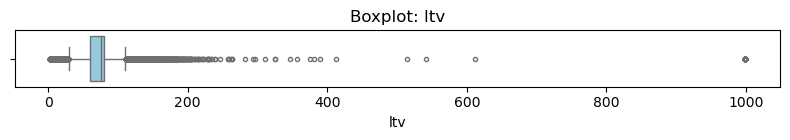

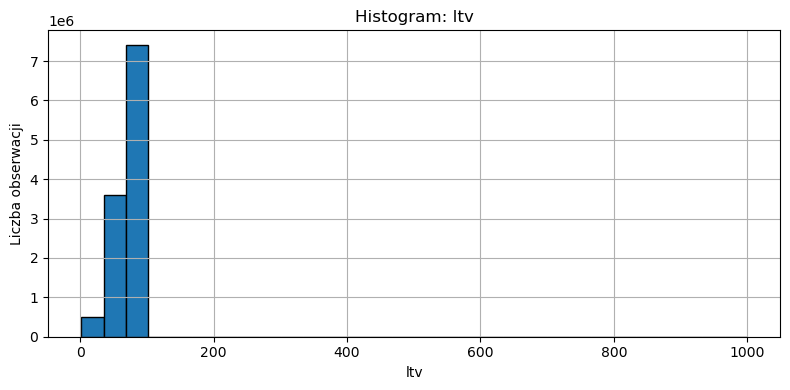

In [5]:
# Makro do analizy jednej zmiennej liczbowej z outlierami i wykresem
#===================================================================
import duckdb
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Wczytanie danych
con = duckdb.connect()
df = con.execute("""
    SELECT * FROM read_parquet('final_base.parquet')
""").df()

# Lista analizowanych zmiennych liczbowych
numeric_cols = [
    'original_loan_term',
    'sum_monthly_mod_cost',
    'avg_estimated_ltv',
    'months_reported',
    'avg_loan_age',
    'max_dpd',
    'months_30dpd',
    'ltv',
    'avg_actual_upb',
    'avg_interest_bearing_upb',
    'upb',
    'cltv',
    'dti',
    'interest_rate',
    'credit_score',
    'months_60dpd',
    'max_loan_age'
]

# FUNKCJA ANALIZUJĄCA WYBRANĄ ZMIENNĄ

def analyze_numeric_variable(col):
    print(f"\n Analiza zmiennej: **{col}**")

    series = df[col].dropna()
    
    # Statystyki opisowe
    print("\nStatystyki opisowe:")
    display(series.describe(percentiles=[.01, .05, .25, .5, .75, .95, .99]).to_frame(name=col))

    # Obliczanie outlierów metodą IQR
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers_low = (series < lower_bound).sum()
    outliers_high = (series > upper_bound).sum()
    total = len(series)
    print(f"\nOutliery dolne: {outliers_low}, górne: {outliers_high}, razem: {outliers_low + outliers_high} ({(outliers_low + outliers_high)/total:.2%})")

    # Boxplot
    plt.figure(figsize=(8, 1.5))
    sns.boxplot(x=series, color='skyblue', fliersize=3)
    plt.title(f"Boxplot: {col}")
    plt.tight_layout()
    plt.show()

    # Histogram
    plt.figure(figsize=(8, 4))
    series.hist(bins=30, edgecolor='black')
    plt.title(f"Histogram: {col}")
    plt.xlabel(col)
    plt.ylabel("Liczba obserwacji")
    plt.tight_layout()
    plt.show()

# WYWOŁANIE ANALIZY
# Tutaj należy wpisać nazwę zmiennej do analizy:
analyze_numeric_variable('ltv')

## 6. Korelacja i współliniowość

### 6.1 Macierz korelacji Pearsona

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

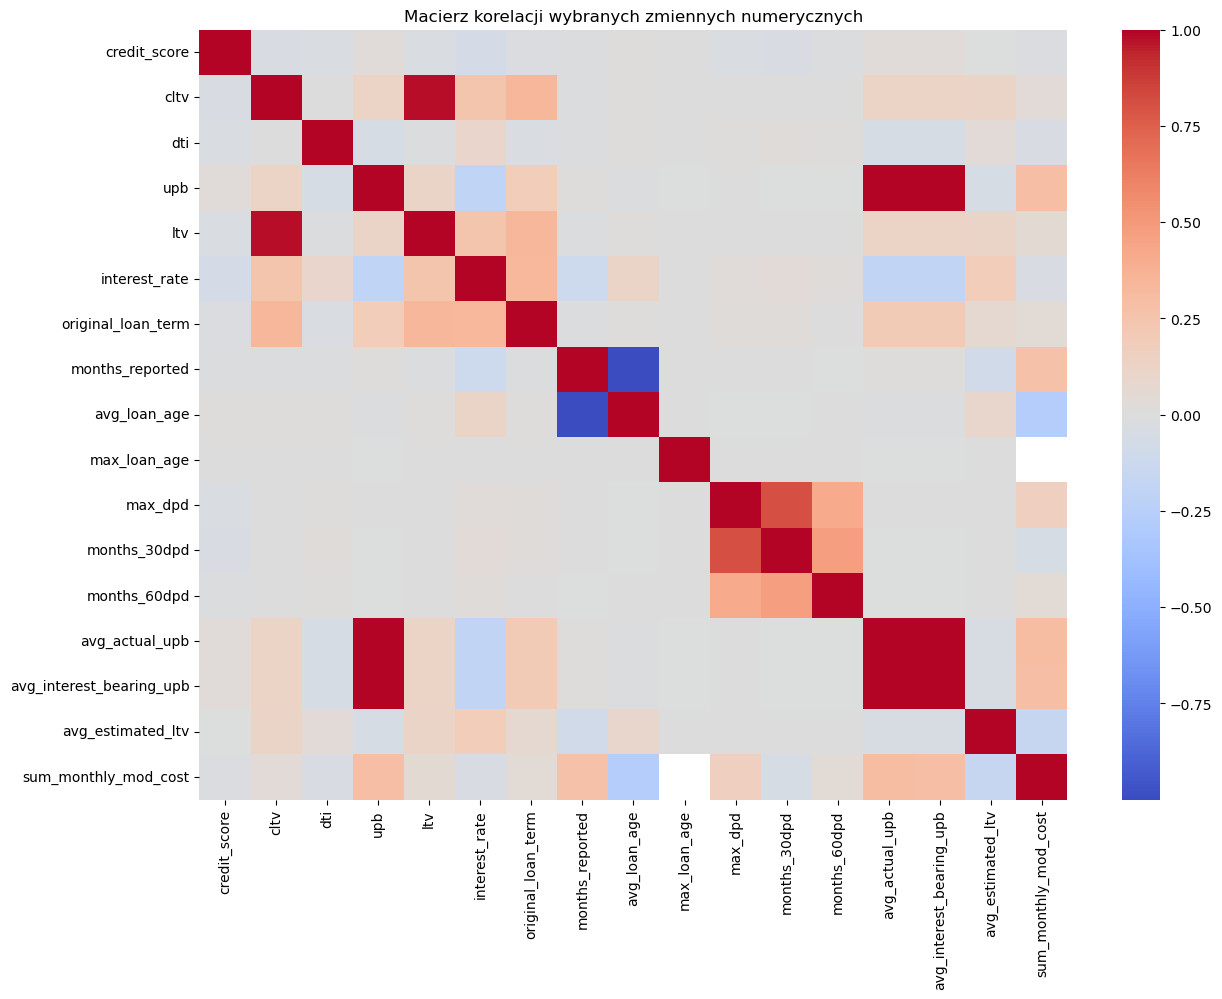

In [6]:
# 6.1 Macierz korelacji Pearsona dla zmiennych numerycznych
# Pokazuje liniową współzależność pomiędzy zmiennymi liczbowymi (bez loan_id i postal_code)
#==========================================================================================

import duckdb
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Wczytanie danych
con = duckdb.connect()
final_base = con.execute("""
    SELECT * FROM 'final_base.parquet'
""").df()

# Lista zmiennych liczbowych do analizy korelacji
selected_numeric_cols = [
    'credit_score', 'cltv', 'dti', 'upb', 'ltv', 'interest_rate',
    'original_loan_term', 'months_reported', 'avg_loan_age', 'max_loan_age',
    'max_dpd', 'months_30dpd', 'months_60dpd', 'avg_actual_upb', 'avg_interest_bearing_upb',
    'avg_estimated_ltv', 'sum_monthly_mod_cost'
]

# Tworzenie podzbioru tylko z wybranych zmiennych
numeric_df = final_base[selected_numeric_cols]

# Macierz korelacji Pearsona
correlation_matrix = numeric_df.corr()

# Wizualizacja
plt.figure(figsize=(14, 10))
sns.heatmap(correlation_matrix, cmap='coolwarm', annot=False)
plt.title("Macierz korelacji wybranych zmiennych numerycznych")
plt.show()

### 6.2. Pary zmiennych o silnej korelacji (Pearson)

In [7]:
# 6.2 Wyszukiwanie par zmiennych o silnej korelacji Pearsona (> 0.8)
# Wyszukuje wszystkie pary liczbowych zmiennych, które są silnie skorelowane (|r| > 0.8)
#=======================================================================================
import duckdb
import pandas as pd
import numpy as np

# Wczytanie danych
con = duckdb.connect()
final_base = con.execute("""
    SELECT * FROM 'final_base.parquet'
""").df()

# Lista zmiennych modelowych
model_variables = [
    'credit_score', 'cltv', 'dti', 'upb', 'ltv', 'interest_rate',
    'original_loan_term', 'months_reported', 'avg_loan_age', 'max_loan_age',
    'max_dpd', 'months_30dpd', 'months_60dpd', 'avg_actual_upb',
    'avg_interest_bearing_upb', 'avg_estimated_ltv', 'sum_monthly_mod_cost'
]

numeric_df = final_base[model_variables].copy()

# Macierz korelacji
corr_matrix = numeric_df.corr().abs()

# Górny trójkąt macierzy
upper_triangle = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

# Wyszukiwanie silnych korelacji > 0.8
high_corr = [(col1, col2, upper_triangle.loc[col2, col1])
             for col1 in upper_triangle.columns
             for col2 in upper_triangle.index
             if upper_triangle.loc[col2, col1] > 0.8]

# Tabela wynikowa
high_corr_df = pd.DataFrame(high_corr, columns=["Variable_1", "Variable_2", "Correlation"])

# Wyświetlenie
from IPython.display import display
display(high_corr_df.sort_values("Correlation", ascending=False))


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,Variable_1,Variable_2,Correlation
5,avg_interest_bearing_upb,avg_actual_upb,1.000000
1,avg_loan_age,months_reported,0.999999
4,avg_interest_bearing_upb,upb,0.995975
3,avg_actual_upb,upb,0.995975
0,ltv,cltv,0.983960
2,months_30dpd,max_dpd,0.811889


### 6.3 Macierz korelacji Spearmana

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

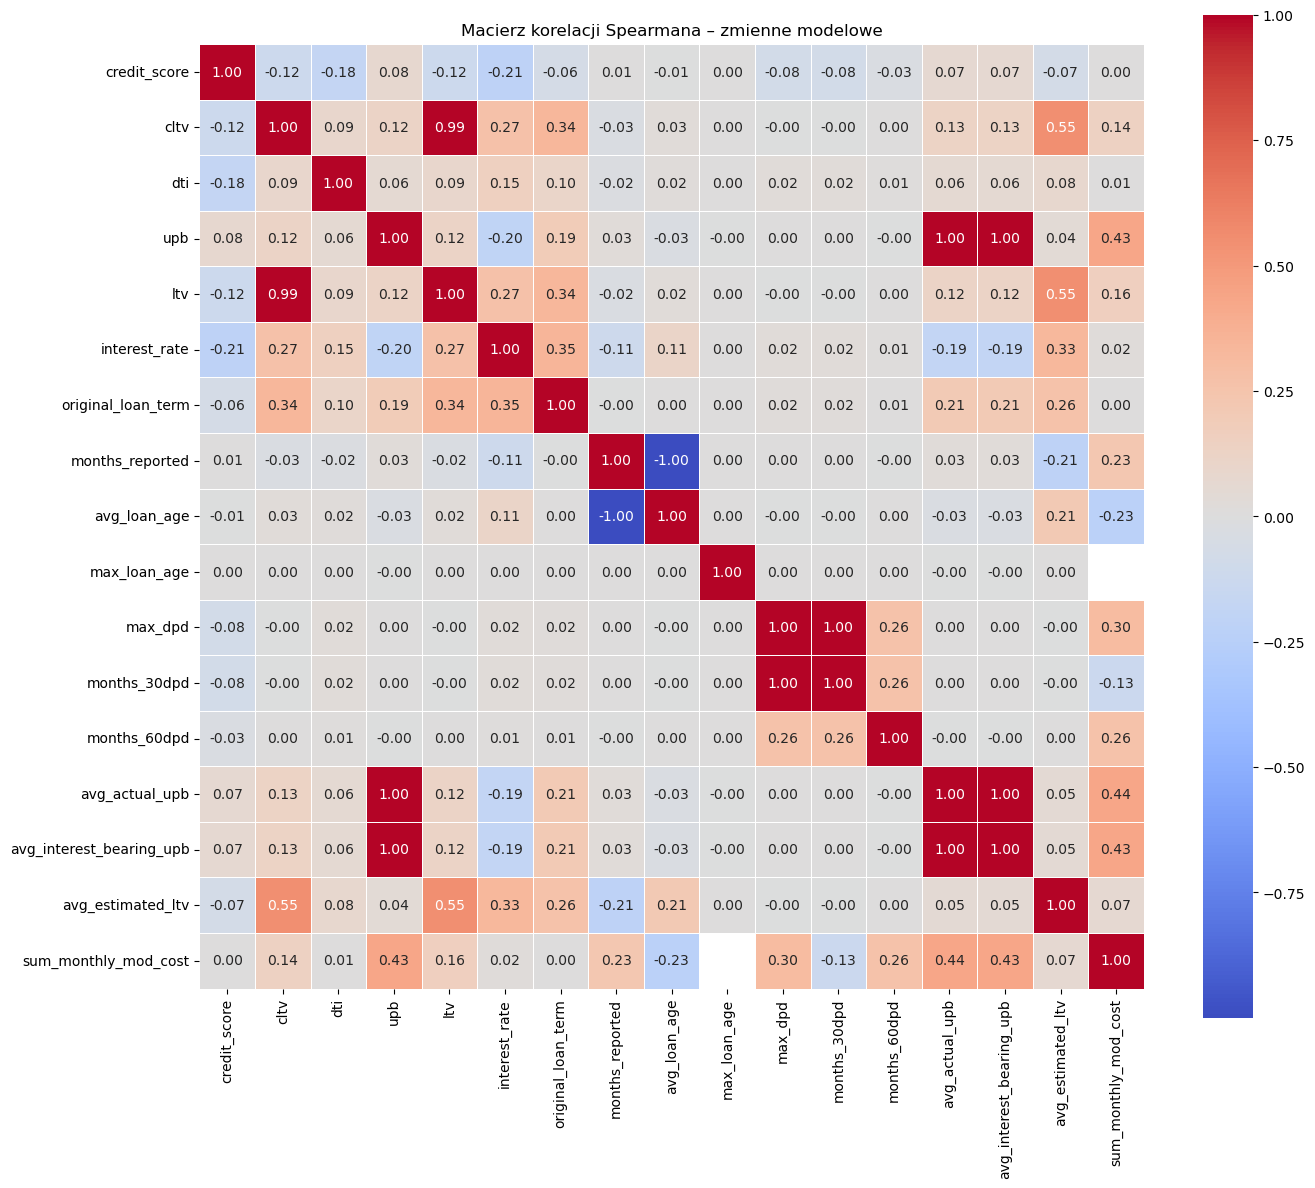

In [8]:
# 6.3 Korelacja Spearmana – heatmapa
# Analiza korelacji rangowej Spearmana dla zmiennych liczbowych
# - działa także przy zależnościach nieliniowych
# - nie wymaga normalności rozkładu
#==============================================================
import duckdb
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os

# Wczytanie danych z pliku parquet
con = duckdb.connect()
final_base = con.execute("""
    SELECT * FROM read_parquet('final_base.parquet')
""").df()

# Lista zmiennych do uwzględnienia w analizie korelacji
model_variables = [
    'credit_score', 'cltv', 'dti', 'upb', 'ltv', 'interest_rate',
    'original_loan_term', 'months_reported', 'avg_loan_age', 'max_loan_age',
    'max_dpd', 'months_30dpd', 'months_60dpd', 'avg_actual_upb',
    'avg_interest_bearing_upb', 'avg_estimated_ltv', 'sum_monthly_mod_cost'
]

# Wybranie tylko tych zmiennych ze zbioru
df_corr = final_base[model_variables].copy()

# Obliczenie korelacji Spearmana
spearman_corr = df_corr.corr(method='spearman')

# Folder zapisu wykresu
output_dir = ''
os.makedirs(output_dir, exist_ok=True)

# Rysowanie heatmapy
plt.figure(figsize=(14, 12))
sns.heatmap(spearman_corr, cmap='coolwarm', annot=True, fmt=".2f", square=True, linewidths=.5)
plt.title("Macierz korelacji Spearmana – zmienne modelowe")
plt.tight_layout()
plt.savefig(os.path.join(output_dir, "correlation_spearman_model_vars.png"))
plt.show()

### 6.4. Pary zmiennych o silnej korelacji (Spearman)

In [9]:
# 6.4 Wyszukiwanie par zmiennych o silnej korelacji Spearmana (> 0.8)
# ====================================================================

import duckdb
import pandas as pd
import numpy as np

# Wczytanie final_base
con = duckdb.connect()
final_base = con.execute("""
    SELECT * FROM 'final_base.parquet'
""").df()

# Lista wybranych zmiennych do analizy korelacji
selected_vars = [
    'credit_score', 'cltv', 'dti', 'upb', 'ltv', 'interest_rate',
    'original_loan_term', 'months_reported', 'avg_loan_age', 'max_loan_age',
    'max_dpd', 'months_30dpd', 'months_60dpd', 'avg_actual_upb',
    'avg_interest_bearing_upb', 'avg_estimated_ltv', 'sum_monthly_mod_cost'
]

# Podzbiór danych tylko z tymi zmiennymi
numeric_df = final_base[selected_vars].copy()

# Macierz korelacji Spearmana
spearman_corr = numeric_df.corr(method='spearman').abs()

# Górny trójkąt bez duplikatów
upper_triangle = spearman_corr.where(np.triu(np.ones(spearman_corr.shape), k=1).astype(bool))

# Wyszukiwanie par o korelacji > 0.8
high_corr_spearman = [
    (col1, col2, upper_triangle.loc[col2, col1])
    for col1 in upper_triangle.columns
    for col2 in upper_triangle.index
    if upper_triangle.loc[col2, col1] > 0.8
]

# Tabela wynikowa
spearman_corr_df = pd.DataFrame(high_corr_spearman, columns=["Variable_1", "Variable_2", "Spearman_corr"])
spearman_corr_df = spearman_corr_df.sort_values("Spearman_corr", ascending=False).reset_index(drop=True)

from IPython.display import display
display(spearman_corr_df)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,Variable_1,Variable_2,Spearman_corr
0,avg_interest_bearing_upb,avg_actual_upb,1.000000
1,avg_loan_age,months_reported,0.999997
2,months_30dpd,max_dpd,0.999912
3,avg_interest_bearing_upb,upb,0.995325
4,avg_actual_upb,upb,0.995325
5,ltv,cltv,0.992520


### 6.5 Porównanie korelacji Pearsona i Spearmana

In [11]:
# 6.5 Porównanie korelacji Pearsona vs. Spearmana
# - dla których par zmiennych korelacja Spearmana jest istotnie wyższa niż Pearsona
# - Można wskazać potencjalnie nieliniowe zależności
#==================================================================================
import duckdb
import pandas as pd
import numpy as np
from IPython.display import display

# Wczytanie danych
con = duckdb.connect()
final_base = con.execute("""
    SELECT * FROM read_parquet('final_base.parquet')
""").df()

# Zmienne liczbowe do porównania
num_cols = [
    'credit_score', 'cltv', 'dti', 'upb', 'ltv', 'interest_rate',
    'original_loan_term', 'months_reported', 'avg_loan_age', 'max_loan_age',
    'max_dpd', 'months_30dpd', 'months_60dpd', 'avg_actual_upb',
    'avg_interest_bearing_upb', 'avg_estimated_ltv', 'sum_monthly_mod_cost'
]
# Filtracja — tylko zmienne dostępne w zbiorze
num_cols = [col for col in num_cols if col in final_base.columns]

# Macierze korelacji
pearson_corr = final_base[num_cols].corr(method='pearson')
spearman_corr = final_base[num_cols].corr(method='spearman')

# Różnica Spearman - Pearson
diff_corr = spearman_corr - pearson_corr

# Wyszukiwanie par o dużej różnicy korelacji
diff_pairs = []
for i in range(len(num_cols)):
    for j in range(i+1, len(num_cols)):
        delta = diff_corr.iloc[i, j]
        if abs(delta) > 0.2:
            diff_pairs.append({
                'Variable_1': num_cols[i],
                'Variable_2': num_cols[j],
                'Pearson': pearson_corr.iloc[i, j],
                'Spearman': spearman_corr.iloc[i, j],
                'Difference': delta
            })

# Tabela wynikowa
corr_diff_df = pd.DataFrame(diff_pairs)
corr_diff_df = corr_diff_df.sort_values(by='Difference', key=np.abs, ascending=False)

display(corr_diff_df)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,Variable_1,Variable_2,Pearson,Spearman,Difference
1,ltv,avg_estimated_ltv,0.110804,0.550366,0.439562
0,cltv,avg_estimated_ltv,0.109827,0.548272,0.438446
4,avg_estimated_ltv,sum_monthly_mod_cost,-0.161627,0.068586,0.230213
3,months_60dpd,sum_monthly_mod_cost,0.044927,0.262095,0.217168
2,months_30dpd,months_60dpd,0.474805,0.262314,-0.212491


### 6.6. ANOVA

  0%|          | 0/14 [00:00<?, ?it/s]C:\Users\khtur\anaconda3\Lib\site-packages\scipy\stats\_stats_py.py:4102: DegenerateDataWarning: at least one input has length 0
  if _f_oneway_is_too_small(samples):
  7%|▋         | 1/14 [01:06<14:22, 66.38s/it]C:\Users\khtur\anaconda3\Lib\site-packages\scipy\stats\_stats_py.py:4102: DegenerateDataWarning: at least one input has length 0
  if _f_oneway_is_too_small(samples):
 21%|██▏       | 3/14 [03:37<13:27, 73.41s/it]C:\Users\khtur\anaconda3\Lib\site-packages\scipy\stats\_stats_py.py:4102: DegenerateDataWarning: at least one input has length 0
  if _f_oneway_is_too_small(samples):
 29%|██▊       | 4/14 [04:51<12:14, 73.44s/it]C:\Users\khtur\anaconda3\Lib\site-packages\scipy\stats\_stats_py.py:4102: DegenerateDataWarning: at least one input has length 0
  if _f_oneway_is_too_small(samples):
 36%|███▌      | 5/14 [06:56<13:49, 92.17s/it]C:\Users\khtur\anaconda3\Lib\site-packages\scipy\stats\_stats_py.py:4102: DegenerateDataWarning: at least one 

,cat_variable,num_variable,f_stat,p_value,eta_squared
21,mi_percentage,ltv,2.163793e+05,0.0,0.435599
191,mi_cancellation_indicator,ltv,4.289352e+06,0.0,0.427365
18,mi_percentage,cltv,2.042519e+05,0.0,0.421475
188,mi_cancellation_indicator,cltv,4.047641e+06,0.0,0.413234
106,loan_purpose,ltv,1.880482e+06,0.0,0.246527
...,...,...,...,...,...
155,servicer_name,dti,2.704869e+03,0.0,0.011399
168,servicer_name,avg_estimated_ltv,2.687021e+03,0.0,0.011325
47,occupancy_status,avg_actual_upb,6.524961e+04,0.0,0.011225
48,occupancy_status,avg_interest_bearing_upb,6.524958e+04,0.0,0.011225


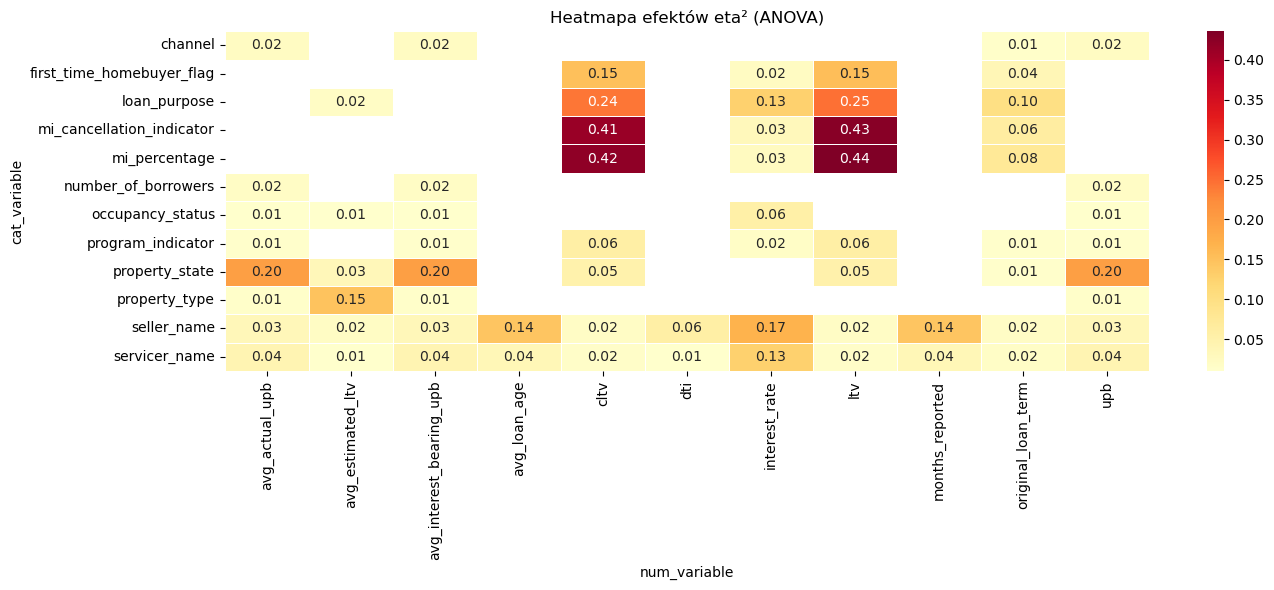

In [10]:
# 6.7 Rozszerzona analiza ANOVA: zależność liczba - kategoria
# - Testowanie  zależności wszystkich zmiennych liczbowych względem kategorycznych
# - Obliczanie p-value z testu ANOVA oraz eta² jako miarę efektu
# - Filtrowanie: p < 0.05 oraz eta² > 0.01
# - Wizualizacja wyników w formie heatmapy eta²
# ================================================================================

import pandas as pd
import numpy as np
import scipy.stats as stats
import seaborn as sns
import matplotlib.pyplot as plt
import os
from tqdm import tqdm
from IPython.display import display

# Wczytanie danych
df = pd.read_parquet('final_base.parquet')

# Wybór zmiennych kategorycznych
excluded = ['loan_id', 'postal_code']
cat_cols = [col for col in df.select_dtypes(include='object').columns if col in df.columns and col.lower() not in [e.lower() for e in excluded]]

# Wybrane zmienne liczbowe
num_cols = [
    'credit_score', 'cltv', 'dti', 'upb', 'ltv', 'interest_rate',
    'original_loan_term', 'months_reported', 'avg_loan_age', 'max_loan_age',
    'max_dpd', 'months_30dpd', 'months_60dpd', 'avg_actual_upb',
    'avg_interest_bearing_upb', 'avg_estimated_ltv', 'sum_monthly_mod_cost'
]
# Filtrowanie tylko tych, które faktycznie istnieją w zbiorze
num_cols = [col for col in num_cols if col in df.columns]

# Zbieranie wyników
results = []

for cat in tqdm(cat_cols):
    if df[cat].nunique() < 2 or df[cat].isnull().mean() > 0.9:
        continue

    for num in num_cols:
        try:
            groups = [group[num].dropna() for name, group in df.groupby(cat)]
            if len(groups) < 2:
                continue

            f_val, p_val = stats.f_oneway(*groups)

            overall_mean = df[num].mean()
            ssb = sum(len(g) * (g.mean() - overall_mean)**2 for g in groups)
            sst = sum((df[num] - overall_mean) ** 2)
            eta_sq = ssb / sst if sst > 0 else np.nan

            results.append({
                'cat_variable': cat,
                'num_variable': num,
                'f_stat': f_val,
                'p_value': p_val,
                'eta_squared': eta_sq
            })

        except:
            continue

# Tabela wynikowa
anova_df = pd.DataFrame(results)

# Filtrowanie wyników
anova_filtered = anova_df[(anova_df['p_value'] < 0.05) & (anova_df['eta_squared'] > 0.01)]
anova_filtered = anova_filtered.sort_values(by='eta_squared', ascending=False)

# Wyświetlenie tabeli
display(anova_filtered)

# Tworzenie pivotu do heatmapy
heatmap_data = anova_filtered.pivot(index='cat_variable', columns='num_variable', values='eta_squared')

# Wizualizacja heatmapy
plt.figure(figsize=(14, max(6, len(heatmap_data)*0.5)))
sns.heatmap(heatmap_data, cmap='YlOrRd', annot=True, fmt=".2f", linewidths=0.5)
plt.title("Heatmapa efektów eta² (ANOVA)")
plt.tight_layout()

# Zapis do pliku
output_dir = ""
os.makedirs(output_dir, exist_ok=True)
plt.savefig(os.path.join(output_dir, "anova_eta_squared_heatmap.png"))
plt.show()


### 6.7. Test Kruskala-Wallisa

100%|██████████| 14/14 [19:13<00:00, 82.38s/it] 


,cat_variable,num_variable,h_stat,p_value,eta_squared
20,mi_percentage,ltv,6.516836e+06,0.0,0.435599
180,mi_cancellation_indicator,ltv,6.441750e+06,0.0,0.427365
17,mi_percentage,cltv,6.460432e+06,0.0,0.421475
177,mi_cancellation_indicator,cltv,6.382031e+06,0.0,0.413234
100,loan_purpose,ltv,3.635144e+06,0.0,0.246527
...,...,...,...,...,...
146,servicer_name,dti,7.903557e+04,0.0,0.011399
159,servicer_name,avg_estimated_ltv,9.949343e+05,0.0,0.011325
45,occupancy_status,avg_actual_upb,1.837219e+05,0.0,0.011225
46,occupancy_status,avg_interest_bearing_upb,1.837218e+05,0.0,0.011225


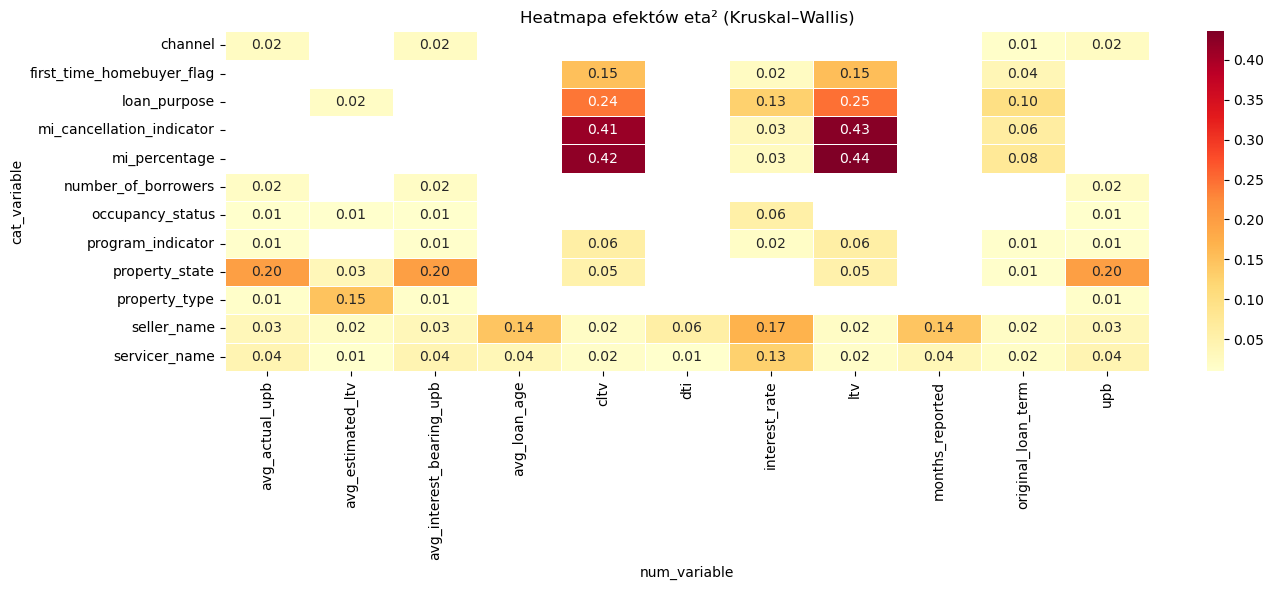

In [12]:
# 6.8 Test Kruskala–Wallisa + Heatmapa efektu eta²
# Alternatywa dla ANOVA przy braku normalności lub homogeniczności wariancji
# Dodatkowo: Heatmapa siły efektu (eta²)
#===========================================================================

import pandas as pd
import numpy as np
import scipy.stats as stats
from tqdm import tqdm
from IPython.display import display
import seaborn as sns
import matplotlib.pyplot as plt
import os

# Wczytanie danych
final_base = pd.read_parquet('final_base.parquet')

# Zmienne do wykluczenia
excluded = ['loan_id', 'postal_code']

# Zmienne kategoryczne
cat_cols = [
    col for col in final_base.select_dtypes(include='object').columns
    if col.lower() not in [e.lower() for e in excluded]
]

# Lista zmiennych liczbowych do testu
num_cols = [
    'credit_score', 'cltv', 'dti', 'upb', 'ltv', 'interest_rate',
    'original_loan_term', 'months_reported', 'avg_loan_age', 'max_loan_age',
    'max_dpd', 'months_30dpd', 'months_60dpd', 'avg_actual_upb',
    'avg_interest_bearing_upb', 'avg_estimated_ltv', 'sum_monthly_mod_cost'
]

# Filtrowanie — tylko te, które istnieją i mają <90% braków
num_cols = [
    col for col in num_cols
    if col in final_base.columns and final_base[col].isnull().mean() < 0.9
]

# Zbieranie wyników testu Kruskala–Wallisa + eta²
kruskal_results = []

for cat in tqdm(cat_cols):
    if final_base[cat].nunique() < 2 or final_base[cat].isnull().mean() > 0.9:
        continue

    for num in num_cols:
        try:
            groups = [group[num].dropna() for _, group in final_base.groupby(cat)]
            if len(groups) < 2:
                continue

            h_val, p_val = stats.kruskal(*groups)

            overall_mean = final_base[num].mean()
            ssb = sum(len(g) * (g.mean() - overall_mean)**2 for g in groups)
            sst = sum((final_base[num] - overall_mean)**2)
            eta_sq = ssb / sst if sst > 0 else np.nan

            kruskal_results.append({
                'cat_variable': cat,
                'num_variable': num,
                'h_stat': h_val,
                'p_value': p_val,
                'eta_squared': eta_sq
            })
        except:
            continue

# Tabela wynikowa
kruskal_df = pd.DataFrame(kruskal_results)

# Filtrowanie wyników
kruskal_filtered = kruskal_df[
    (kruskal_df['p_value'] < 0.05) & (kruskal_df['eta_squared'] > 0.01)
].sort_values(by='eta_squared', ascending=False)

display(kruskal_filtered)

# Tworzenie heatmapy
heatmap_data = kruskal_filtered.pivot(index='cat_variable', columns='num_variable', values='eta_squared')

plt.figure(figsize=(14, max(6, len(heatmap_data)*0.5)))
sns.heatmap(heatmap_data, cmap='YlOrRd', annot=True, fmt=".2f", linewidths=0.5)
plt.title("Heatmapa efektów eta² (Kruskal–Wallis)")
plt.tight_layout()

# Zapis do pliku
output_dir = ""
os.makedirs(output_dir, exist_ok=True)
plt.savefig(os.path.join(output_dir, "kruskal_eta_squared_heatmap.png"))
plt.show()

## 7. Zależność zmiennych względem default_flag

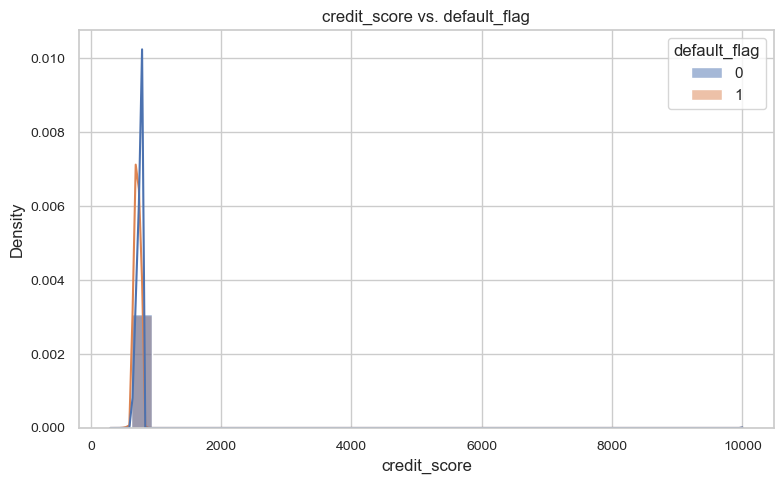

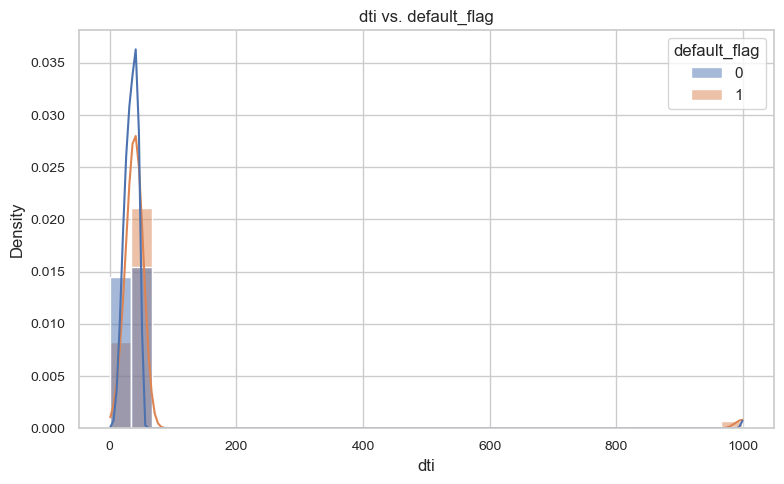

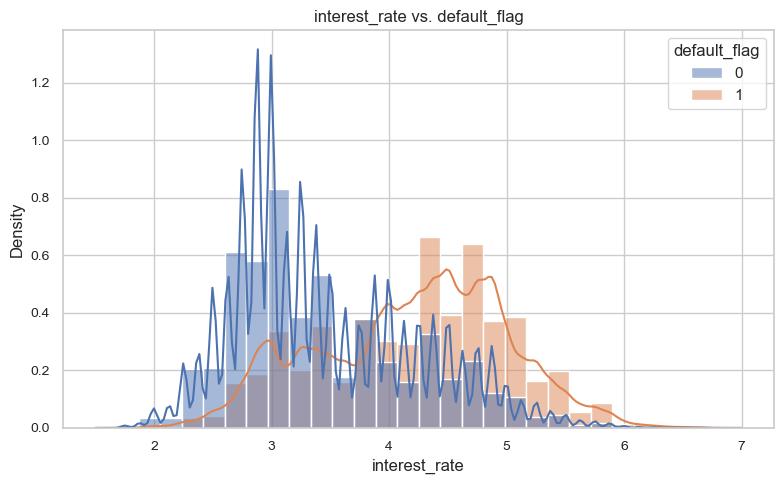

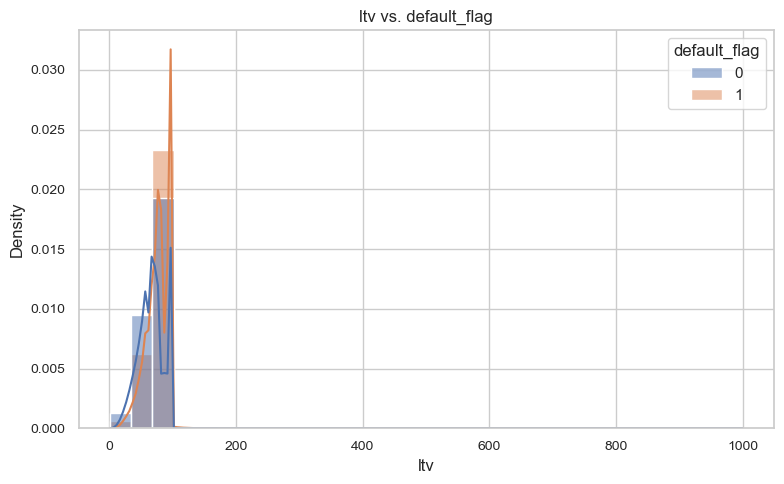

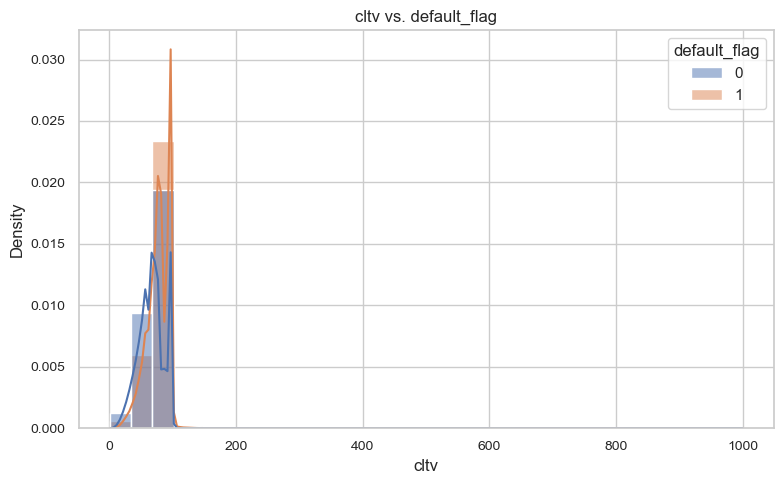

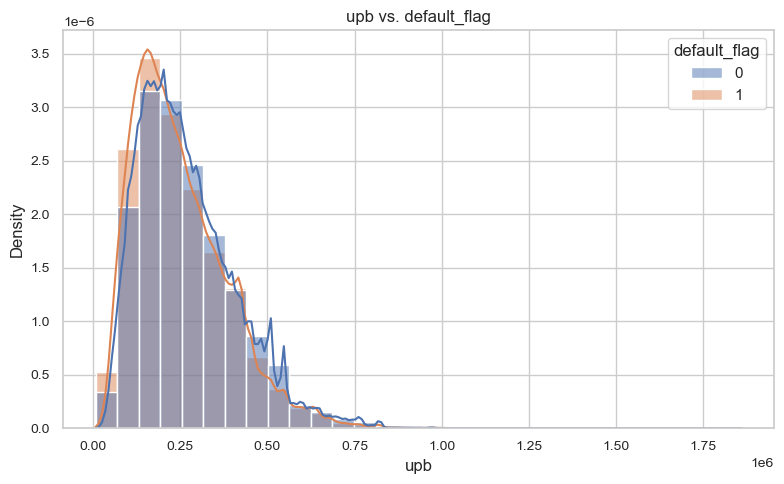

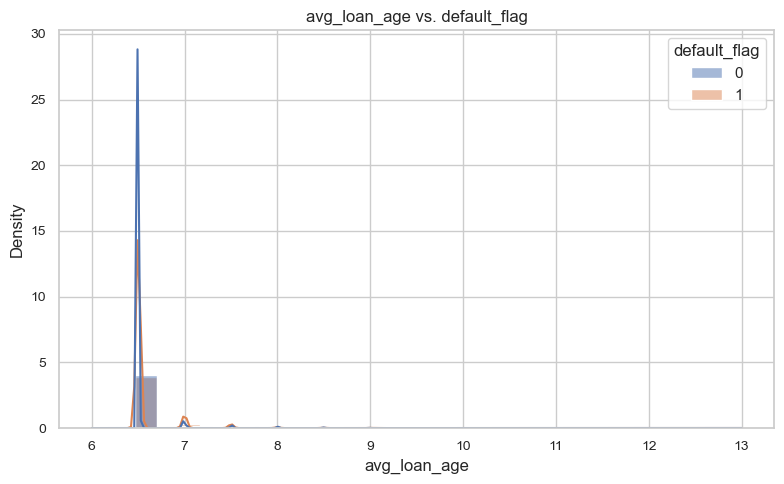

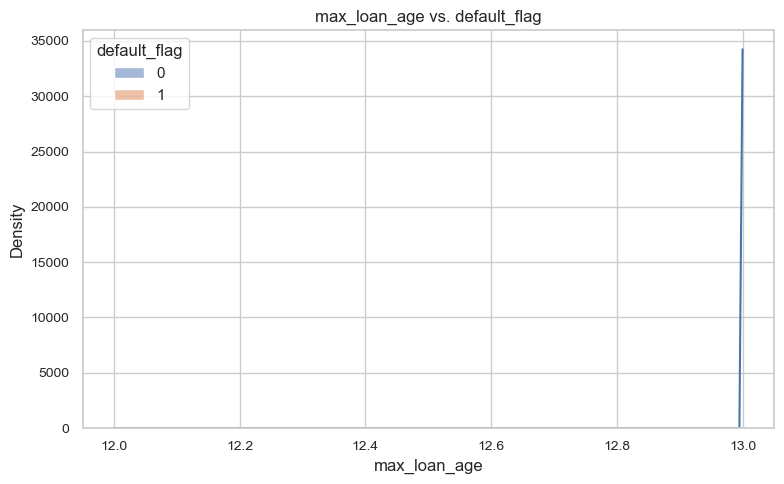

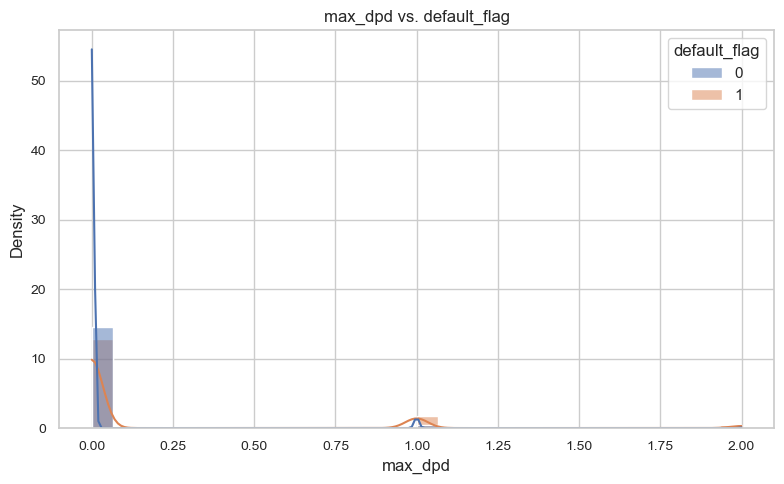

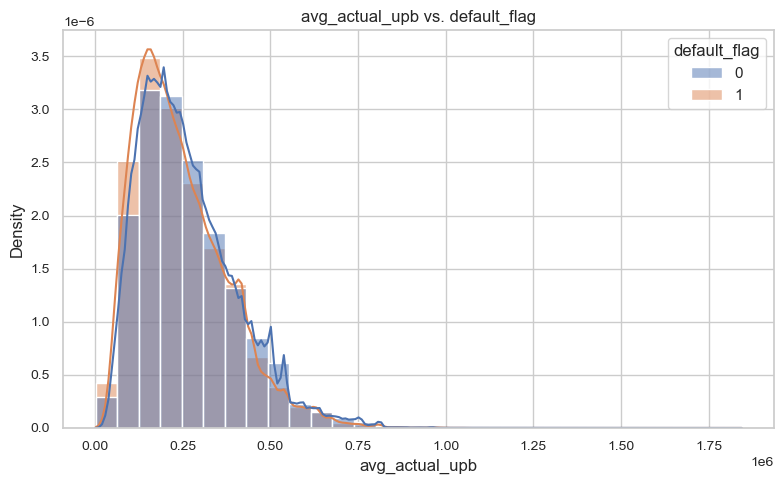

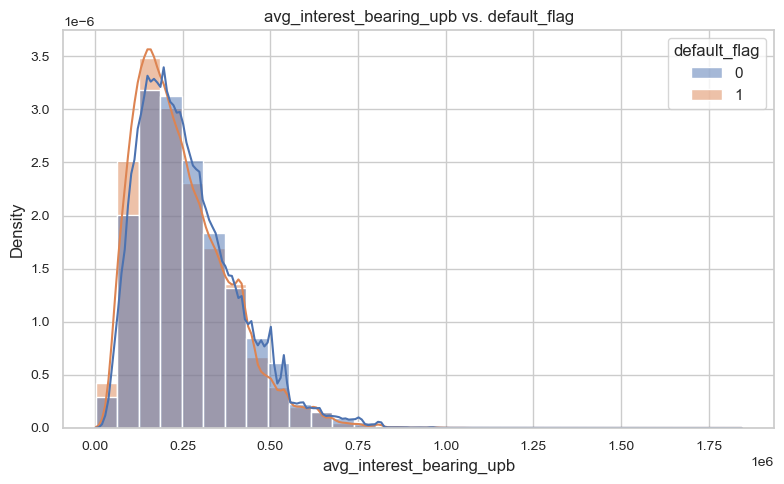

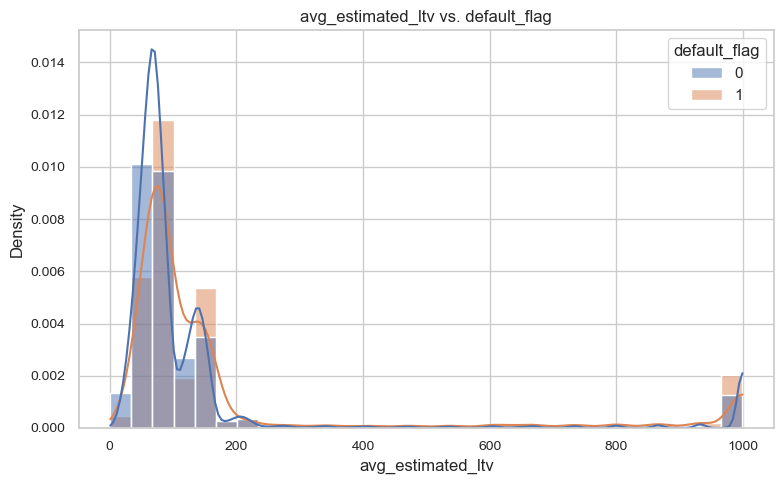

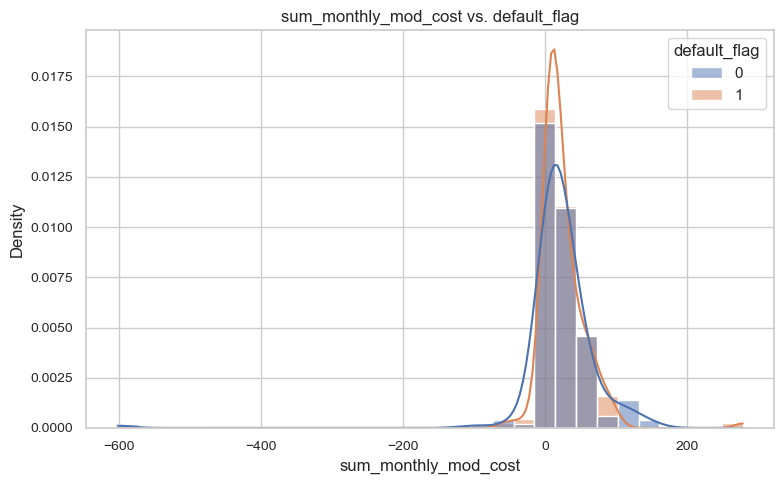

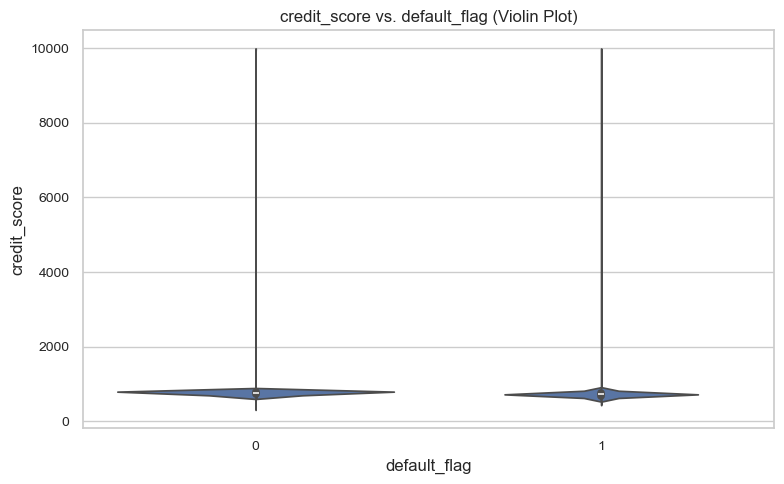

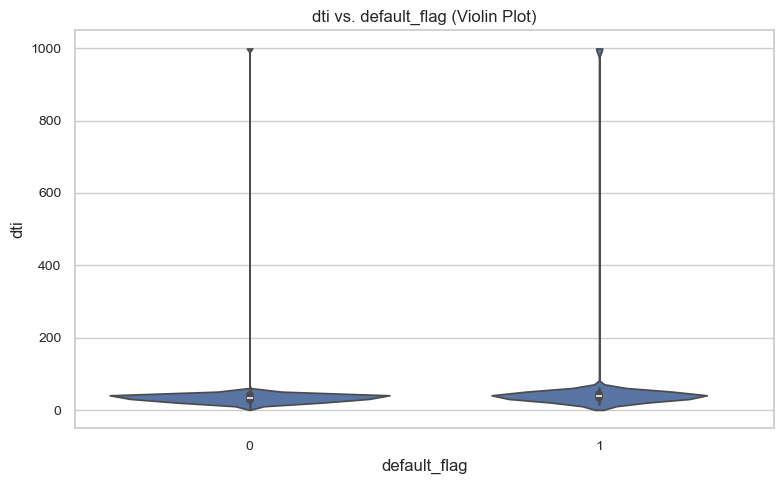

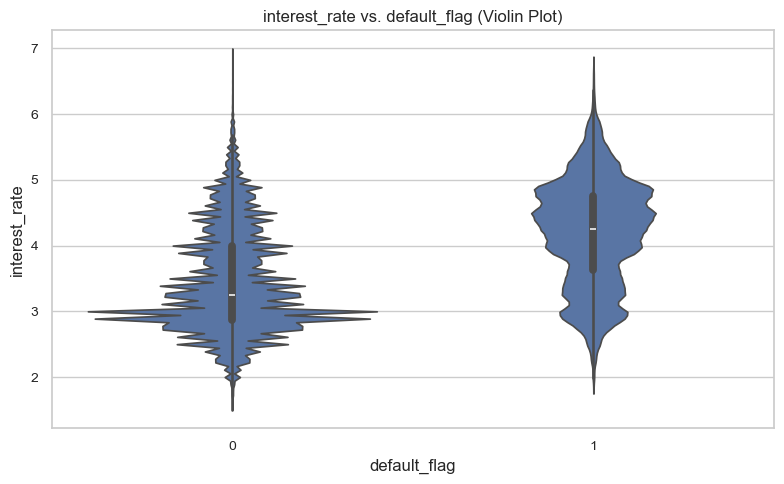

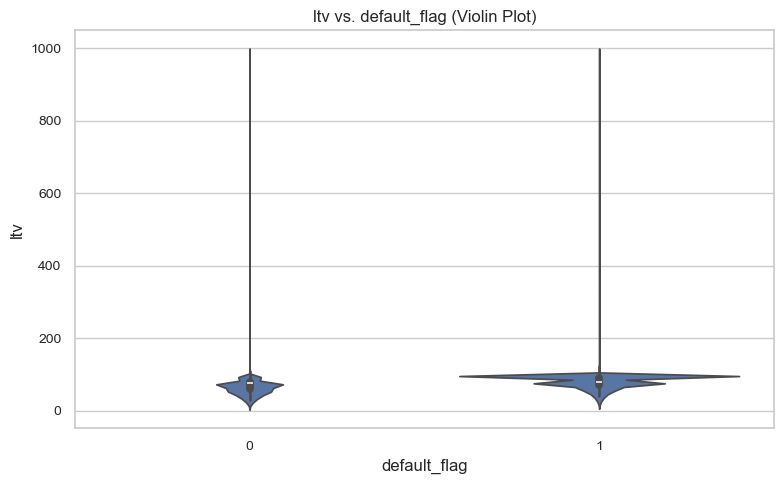

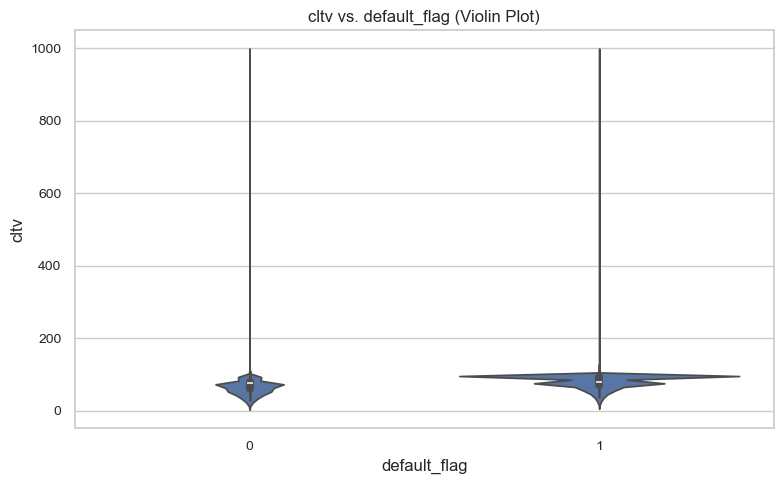

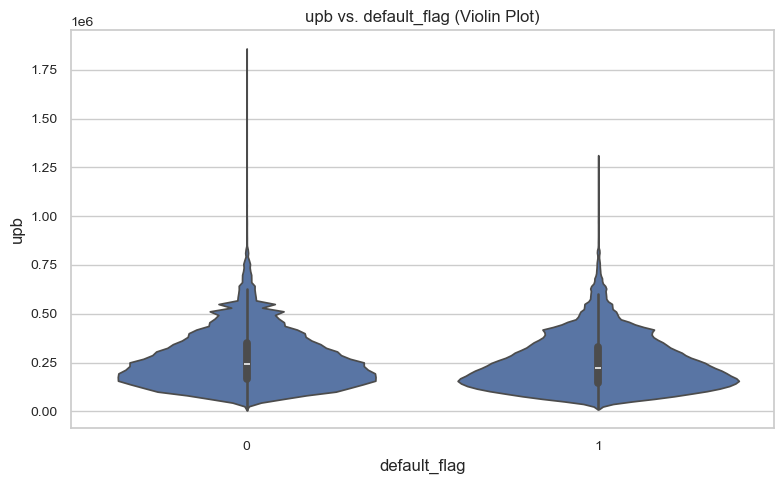

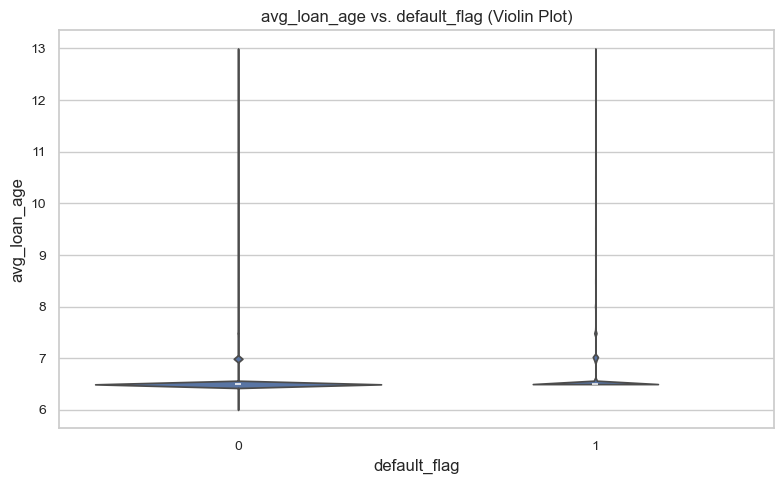

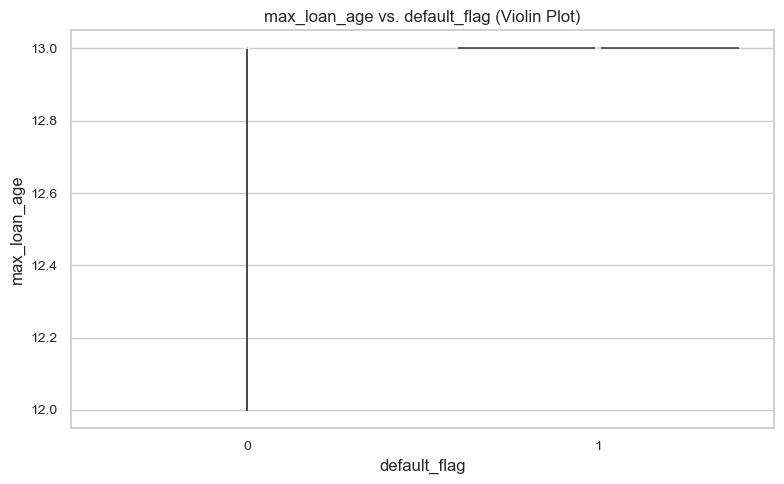

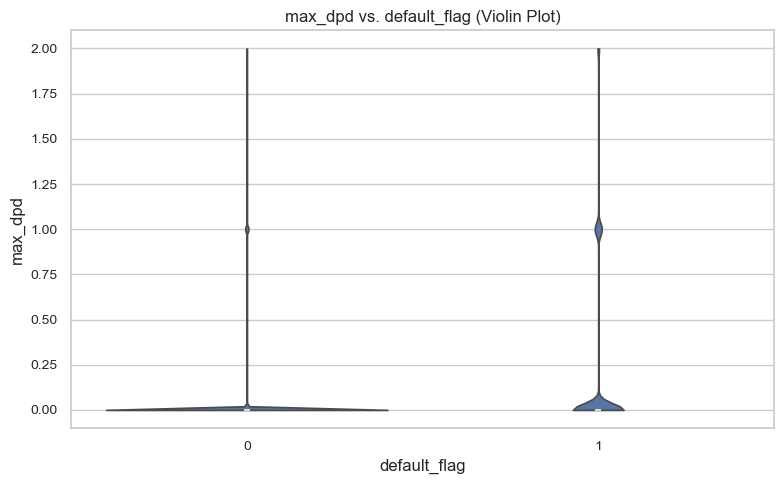

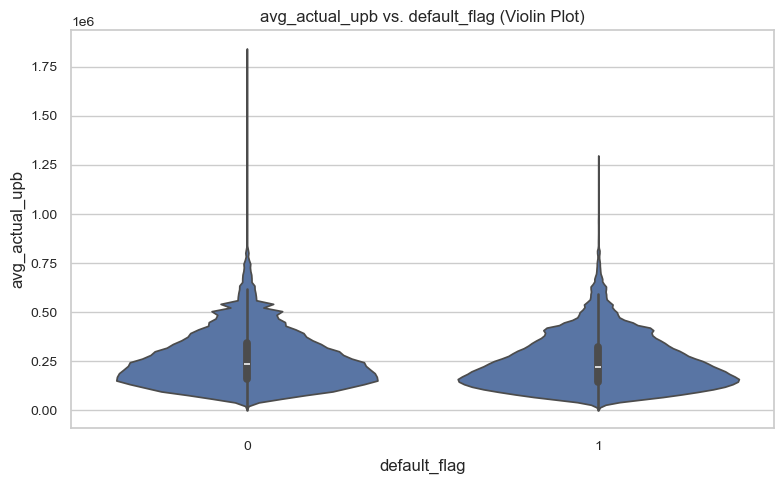

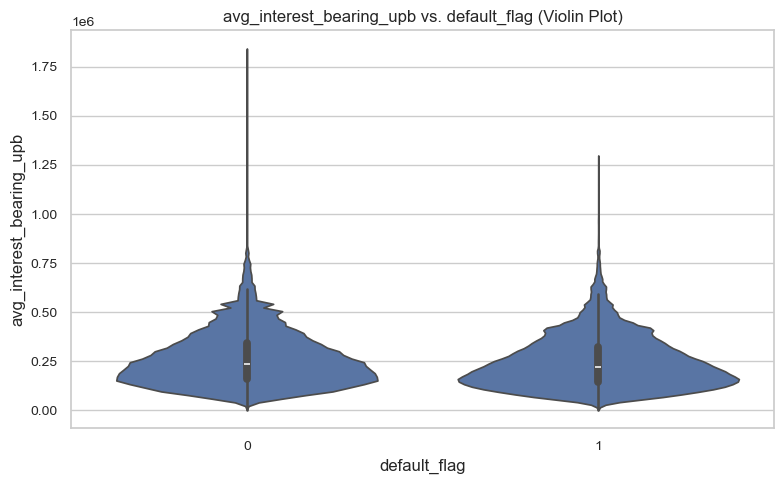

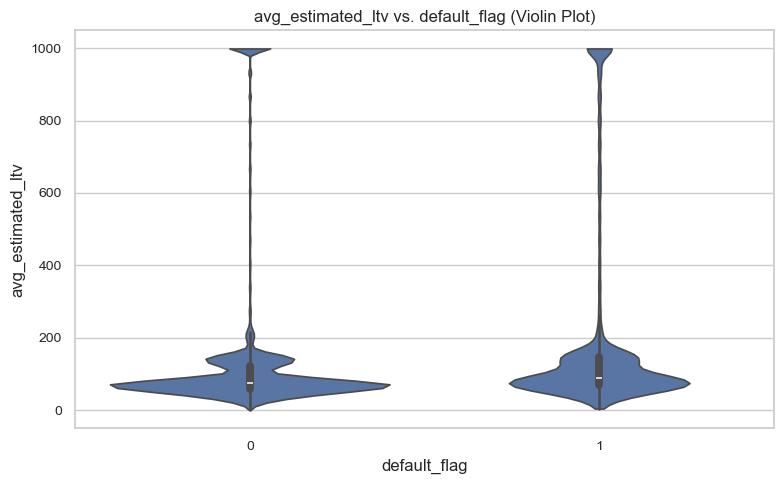

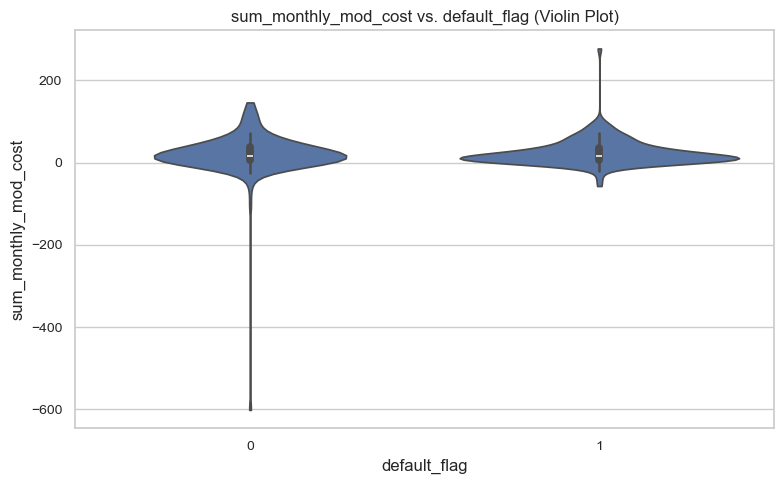

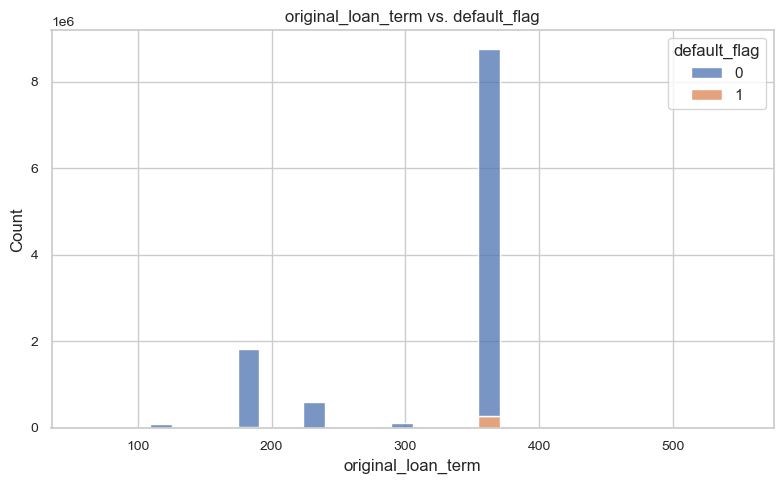

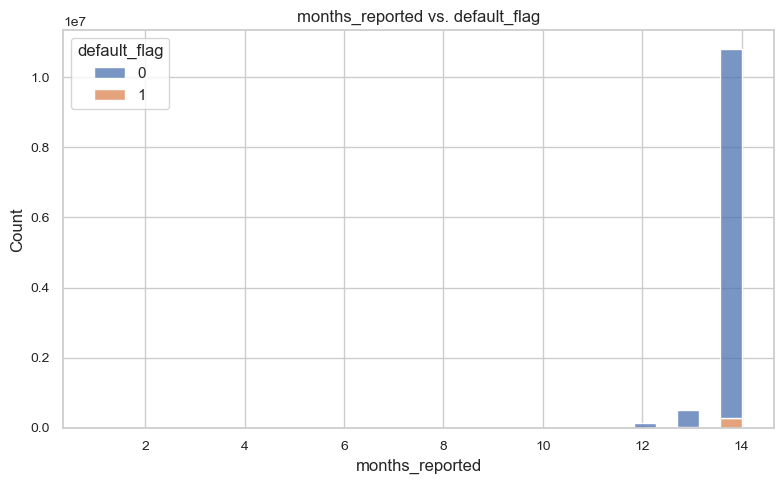

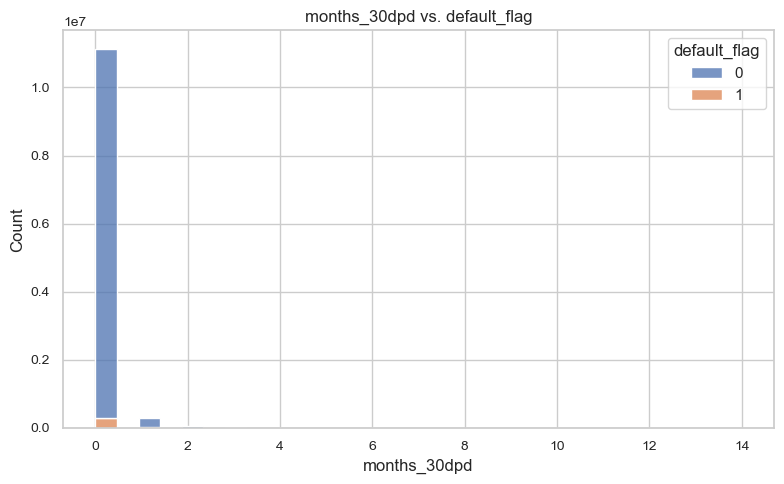

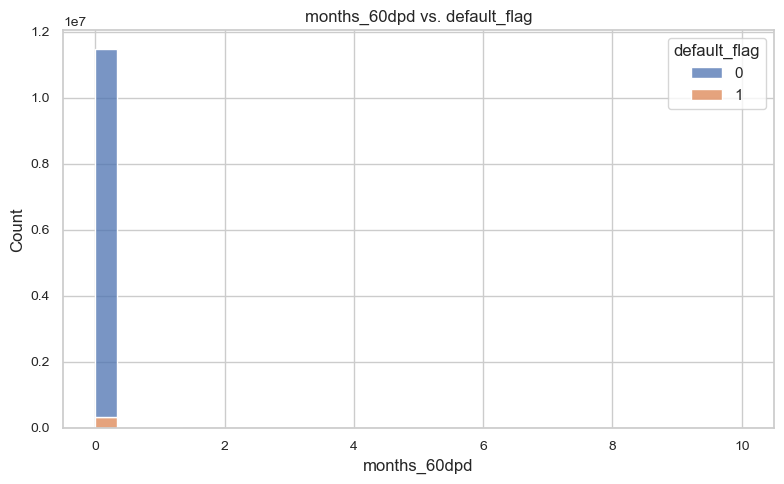

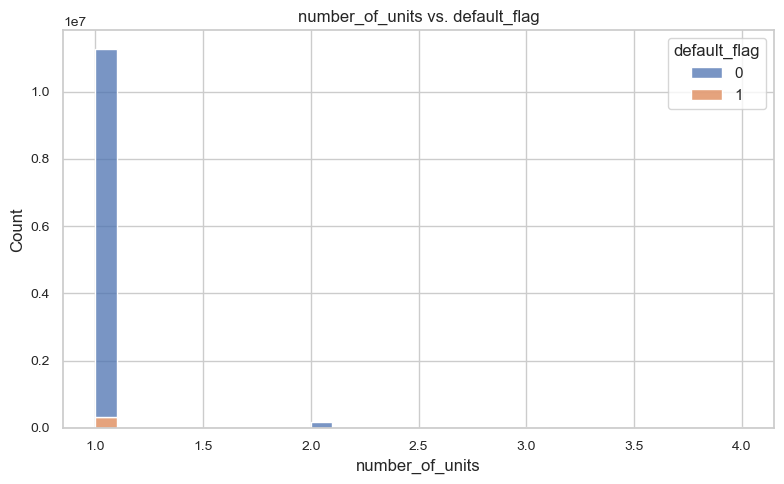

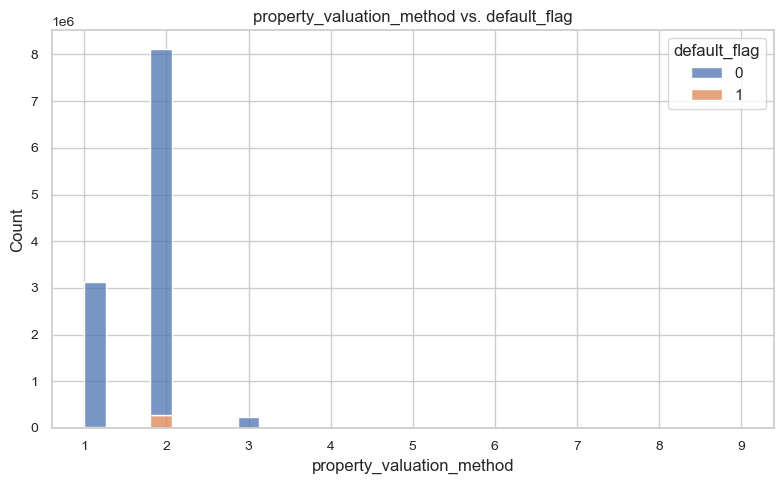

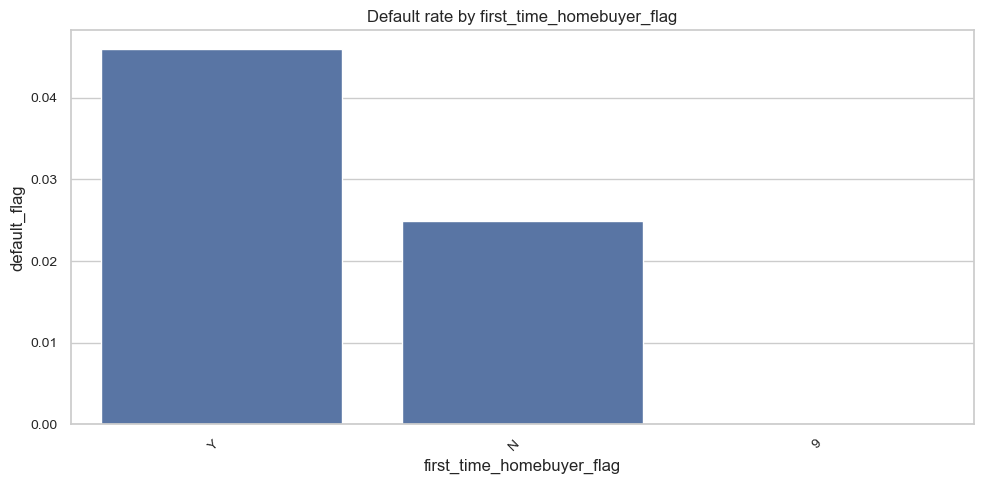

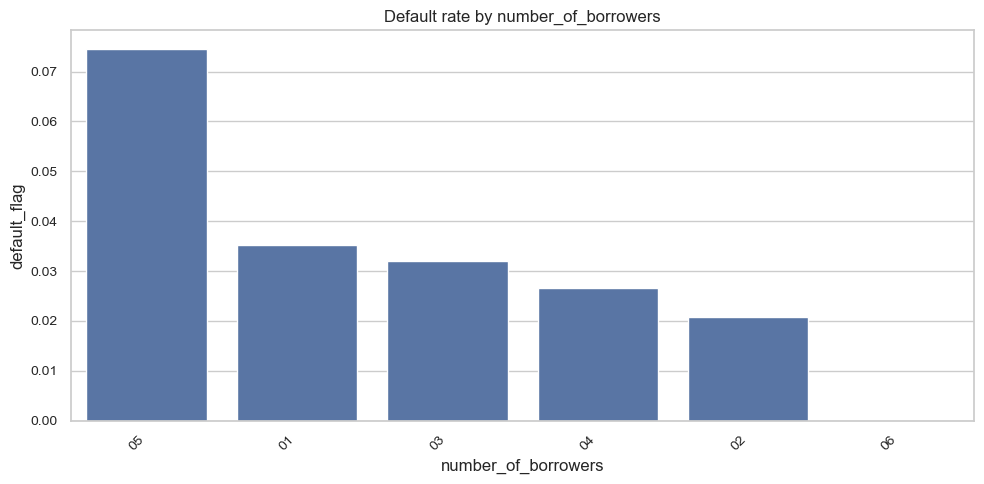

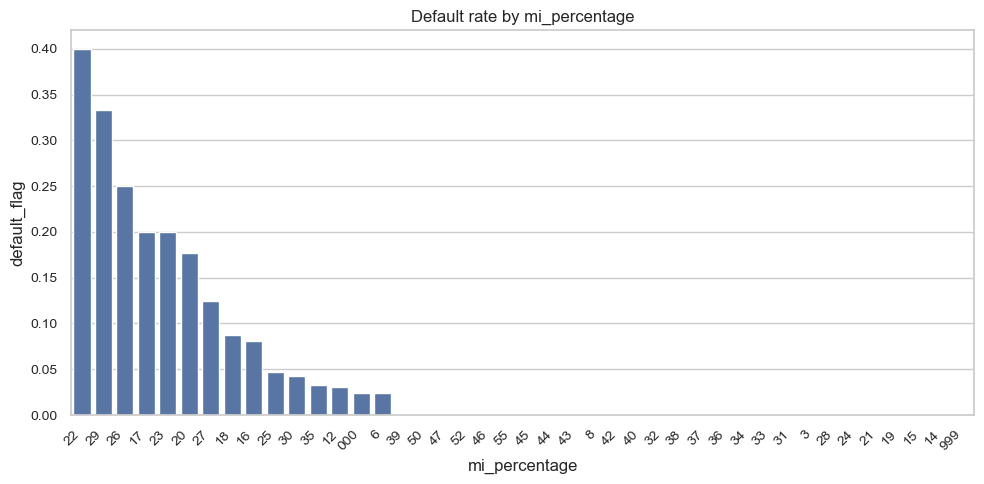

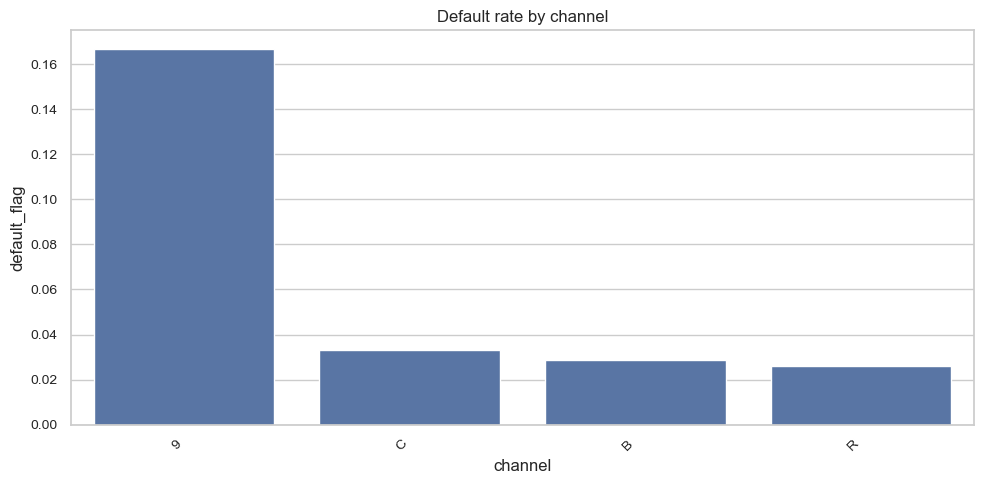

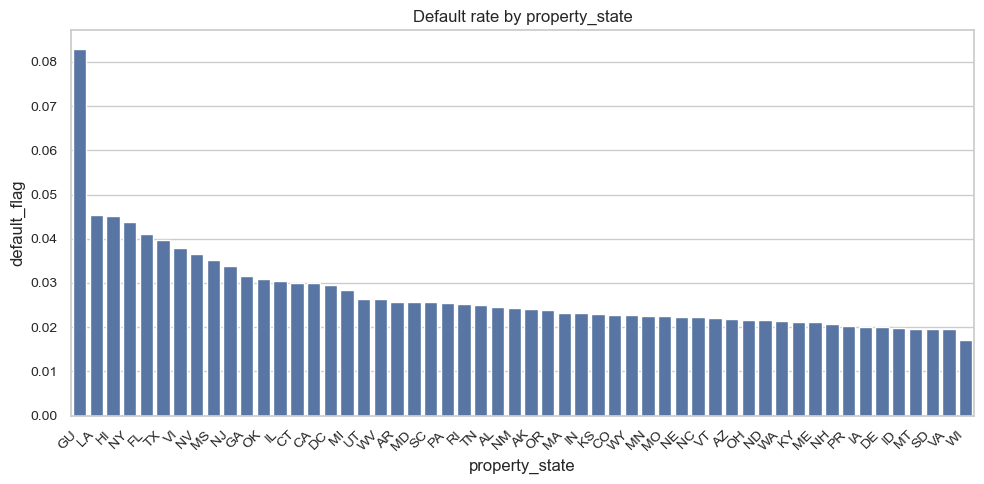

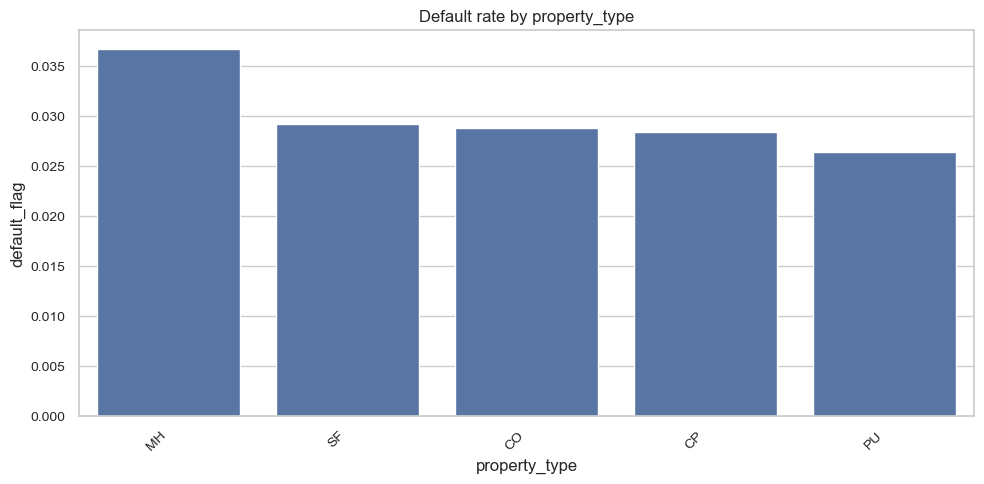

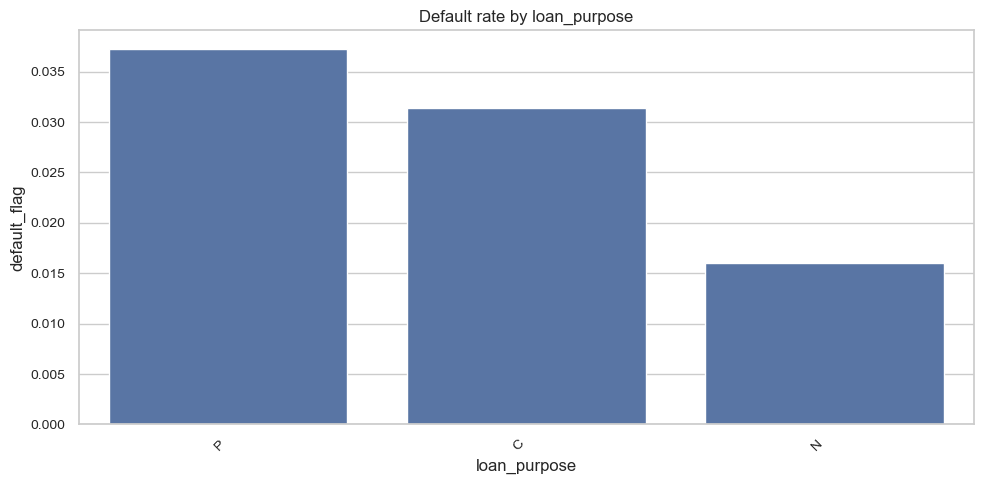

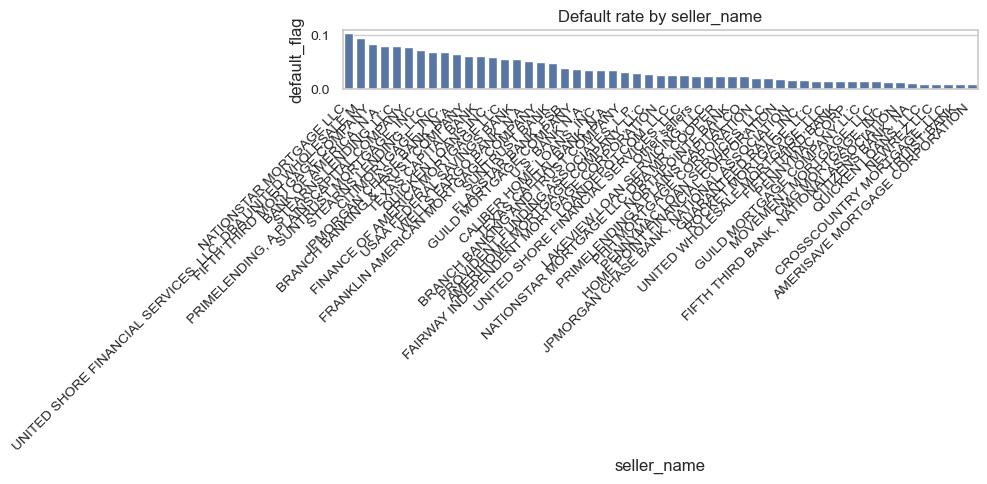

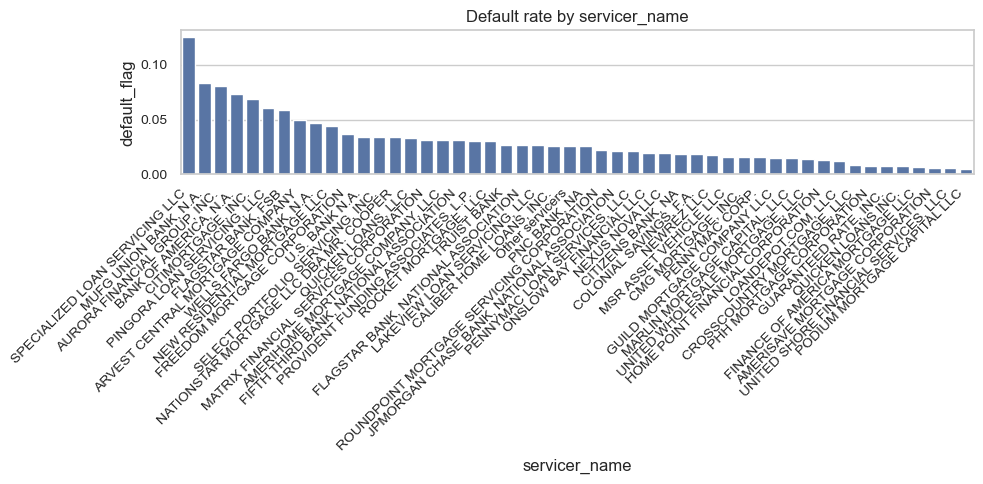

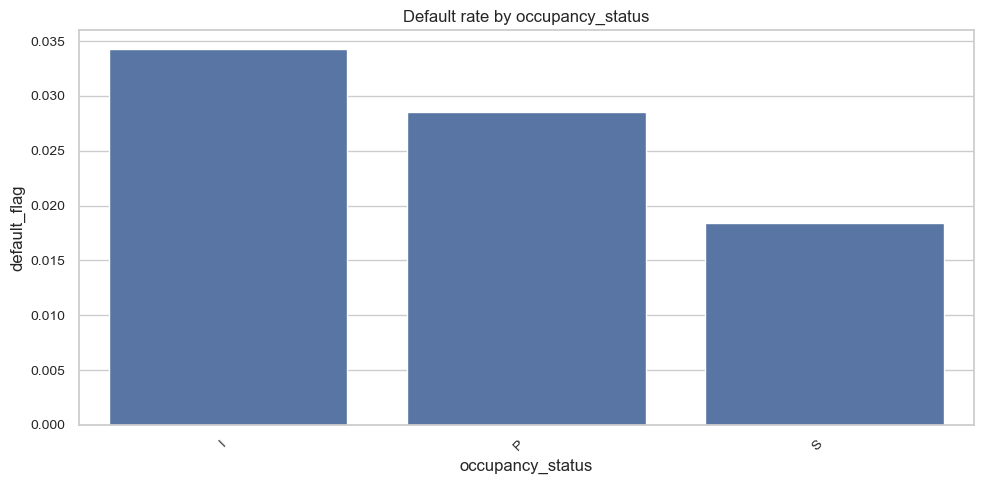

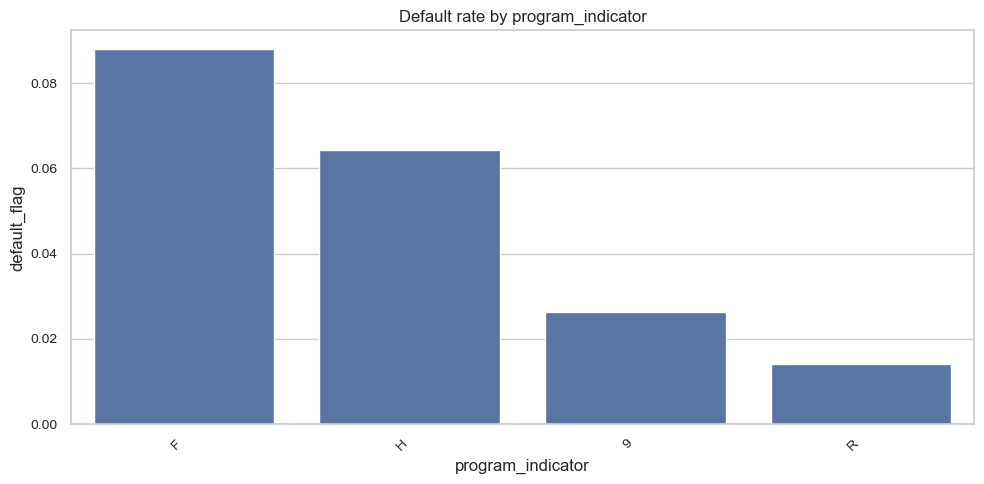

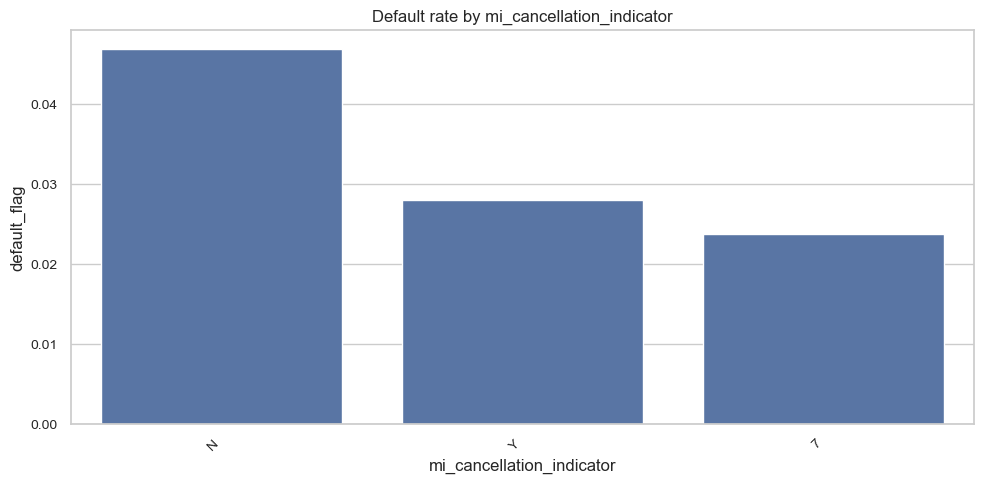

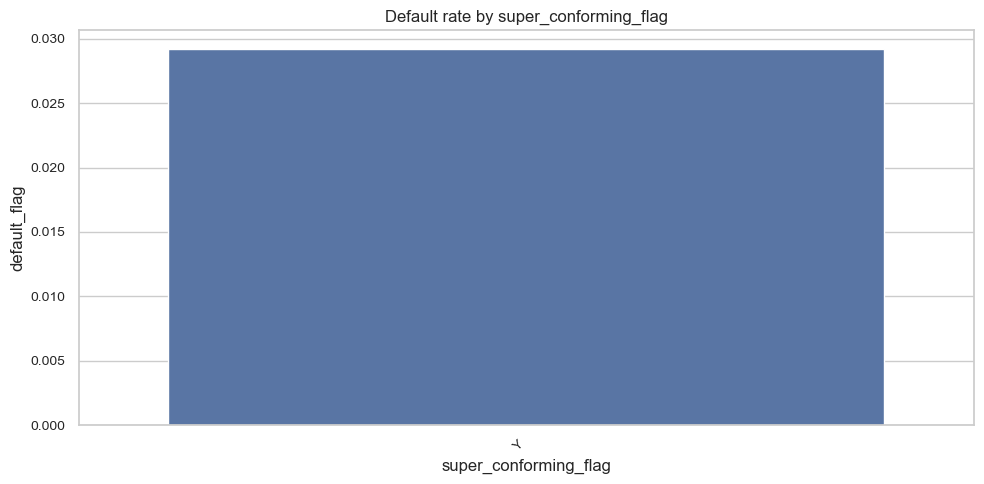

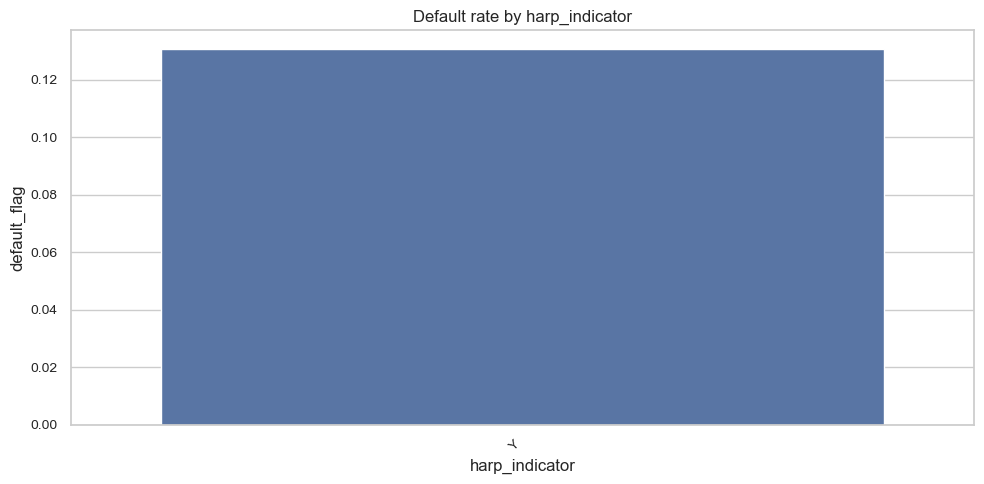

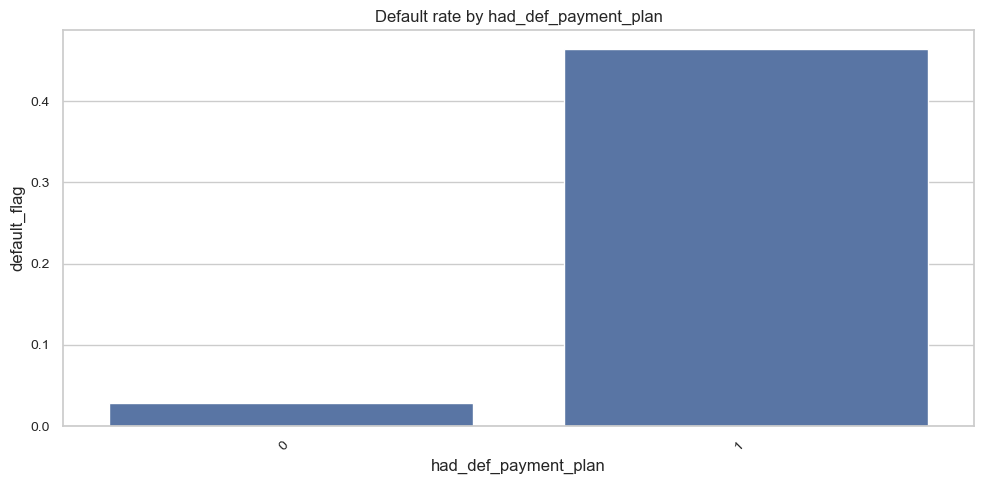

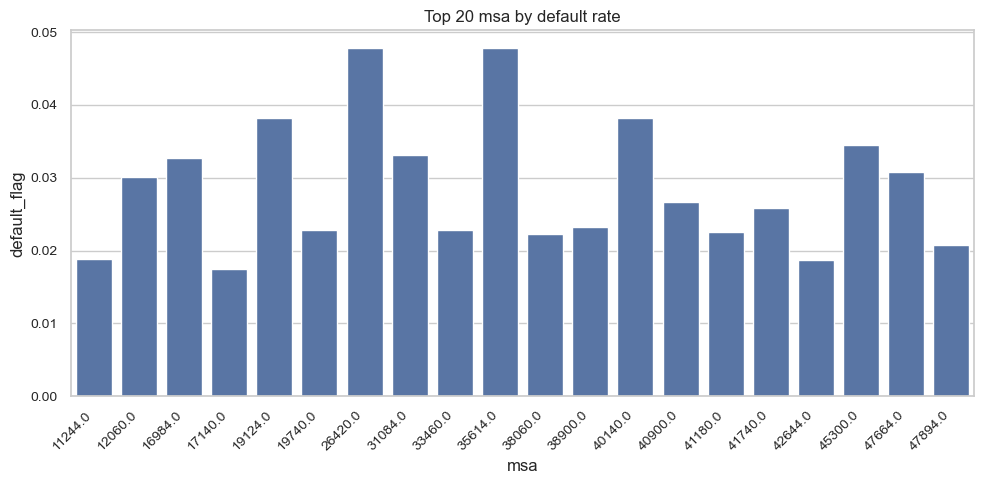

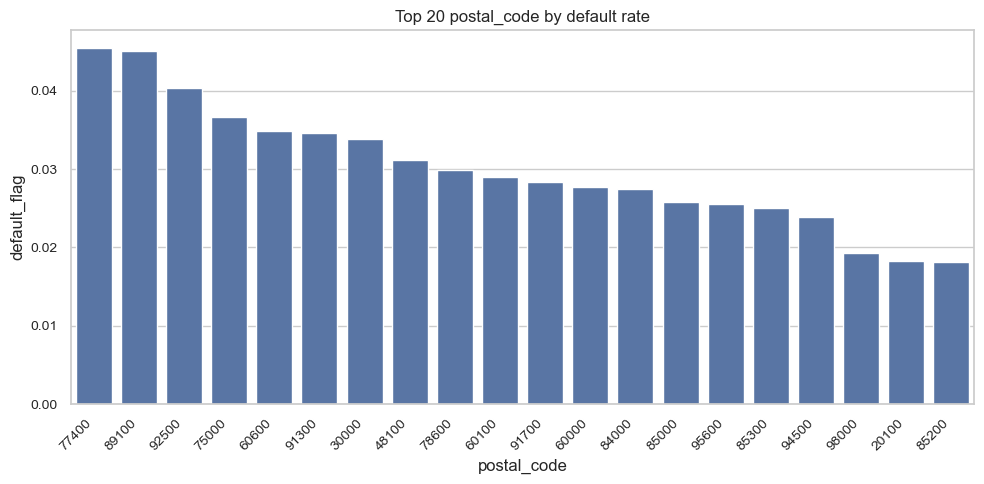

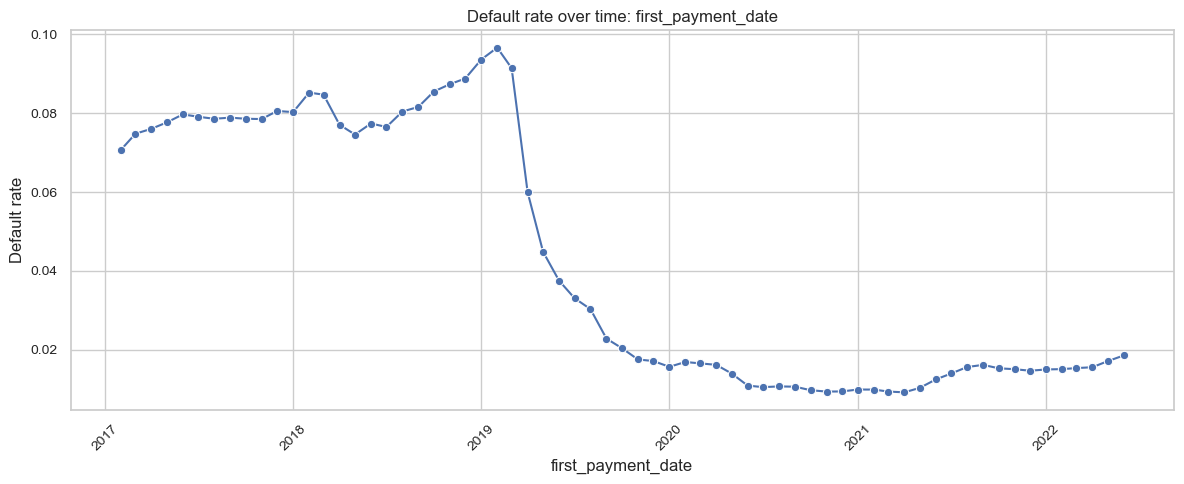

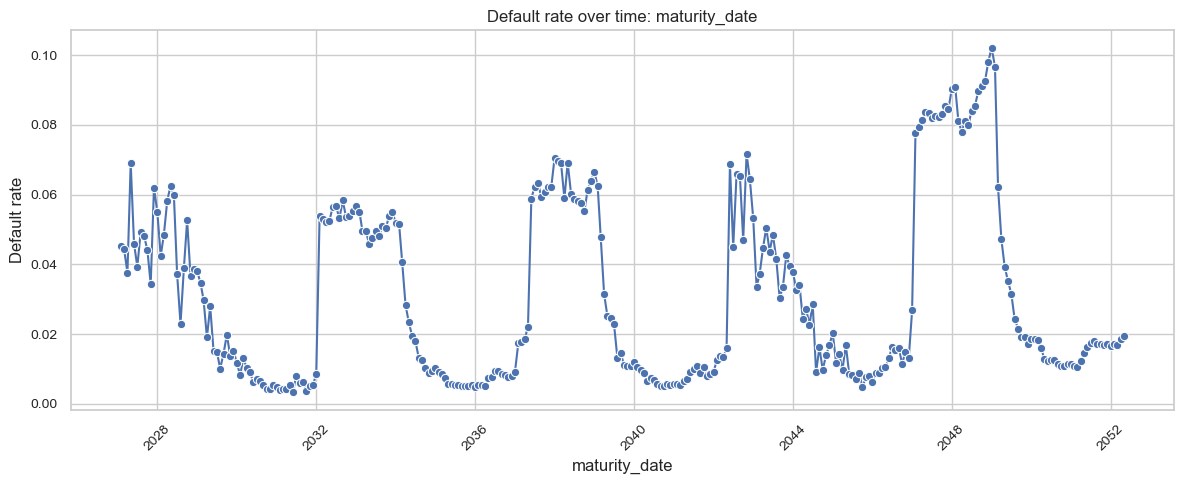

In [1]:
# Wykresy ilustrujące zależność zmiennych względem default_flag

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Ustawienia ogólne
sns.set(style="whitegrid")
plt.rcParams["axes.labelsize"] = 12
plt.rcParams["xtick.labelsize"] = 10
plt.rcParams["ytick.labelsize"] = 10

# Ścieżki
DATA_PATH = ""
OUTPUT_DIR = ""
VIOLIN_DIR = os.path.join(OUTPUT_DIR, "violiny")
os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(VIOLIN_DIR, exist_ok=True)

# Wczytanie danych
df = pd.read_parquet(DATA_PATH)

# Zmienne
target = 'default_flag'

# Zmienne ciągłe (numeryczne – wartości rzeczywiste)
num_continuous = [
    'credit_score', 'dti', 'interest_rate', 'ltv', 'cltv', 'upb',
    'avg_loan_age', 'max_loan_age', 'max_dpd',
    'avg_actual_upb', 'avg_interest_bearing_upb', 'avg_estimated_ltv', 'sum_monthly_mod_cost'
]

# Zmienne dyskretne (liczby całkowite, często w formie "liczba miesięcy")
num_discrete = [
    'original_loan_term', 'months_reported', 'months_30dpd', 'months_60dpd', 'number_of_units',
    'property_valuation_method'
]

# Zmienne kategoryczne
cat_vars = [
    'first_time_homebuyer_flag', 'number_of_borrowers', 'mi_percentage', 'channel',
    'property_state', 'property_type', 'loan_purpose', 'seller_name', 'servicer_name',
    'occupancy_status', 'program_indicator', 'mi_cancellation_indicator',
    'super_conforming_flag', 'harp_indicator', 'had_def_payment_plan'
]

pseudo_cat = ['msa', 'postal_code']

# Daty (w formacie YYYYMM)
date_vars = ['first_payment_date', 'maturity_date']

# Wykresy dla zmiennych liczbowych ciągłych: histogram + KDE
for col in num_continuous:
    plt.figure(figsize=(8, 5))
    sns.histplot(data=df, x=col, hue=target, kde=True, stat='density', common_norm=False, bins=30)
    plt.title(f'{col} vs. {target}')
    plt.tight_layout()
    plt.savefig(f"{OUTPUT_DIR}/{col}_hist_kde.png")
    plt.show()
    plt.close()

# Violinploty dla zmiennych liczbowych ciągłych względem default_flag
for col in num_continuous:
    plt.figure(figsize=(8, 5))
    sns.violinplot(data=df, x=target, y=col, inner='box', cut=0)
    plt.title(f'{col} vs. {target} (Violin Plot)')
    plt.tight_layout()
    plt.savefig(f"{VIOLIN_DIR}/{col}_violin.png")
    plt.show()
    plt.close()

# Wykresy dla zmiennych liczbowych dyskretnych: histogram bez KDE
for col in num_discrete:
    plt.figure(figsize=(8, 5))
    sns.histplot(data=df, x=col, hue=target, kde=False, stat='count', multiple='stack', bins=30)
    plt.title(f'{col} vs. {target}')
    plt.tight_layout()
    plt.savefig(f"{OUTPUT_DIR}/{col}_hist.png")
    plt.show()
    plt.close()

# Wykresy dla zmiennych kategorycznych: barplot z udziałem defaultów
for col in cat_vars:
    plt.figure(figsize=(10, 5))
    rate_df = df.groupby(col)[target].mean().sort_values(ascending=False).reset_index()
    sns.barplot(data=rate_df, x=col, y=target)
    plt.xticks(rotation=45, ha='right')
    plt.title(f'Default rate by {col}')
    plt.tight_layout()
    plt.savefig(f"{OUTPUT_DIR}/{col}_barplot.png")
    plt.show()
    plt.close()

# Pseudo-kategorie: top 20 kategorii o najwyższym default rate
for col in pseudo_cat:
    plt.figure(figsize=(10, 5))
    top_values = df[col].value_counts().head(20).index
    subset = df[df[col].isin(top_values)]
    rate_df = subset.groupby(col)[target].mean().sort_values(ascending=False).reset_index()
    sns.barplot(data=rate_df, x=col, y=target)
    plt.xticks(rotation=45, ha='right')
    plt.title(f'Top 20 {col} by default rate')
    plt.tight_layout()
    plt.savefig(f"{OUTPUT_DIR}/{col}_top20_barplot.png")
    plt.show()
    plt.close()

# Trend defaultów w czasie: first_payment_date i maturity_date
min_obs = 50  # Minimalna liczba obserwacji na datę

# Funkcja do konwersji YYYYMM do daty
def parse_yyyymm(val):
    try:
        val = int(val)
        year = val // 100
        month = val % 100
        return pd.Timestamp(year=year, month=month, day=1)
    except:
        return pd.NaT

# Parsowanie i rysowanie
for col in date_vars:
    if df[col].dtype != 'datetime64[ns]':
        df[col] = df[col].apply(parse_yyyymm)

    temp = df[[col, target]].dropna()
    temp_grouped = temp.groupby(col).agg(
        default_rate=(target, 'mean'),
        count=(target, 'count')
    ).reset_index()

    temp_grouped = temp_grouped[temp_grouped['count'] >= min_obs]

    plt.figure(figsize=(12, 5))
    sns.lineplot(data=temp_grouped, x=col, y='default_rate', marker='o')
    plt.title(f'Default rate over time: {col}')
    plt.ylabel("Default rate")
    plt.xlabel(col)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.savefig(f"{OUTPUT_DIR}/{col}_trend.png")
    plt.show()
    plt.close()

# Tworzenie zbiorów dla konkretnych modeli

## Zbiór dla regresji logistycznej i sieci neuronowej

In [1]:
# TWORZENIE ZBIORU DLA REGRESJI LOGISTYCZNEJ I SIECI NEURONOWEJ
# =============================================================

import pandas as pd
import numpy as np
import duckdb
import os
import joblib
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from scipy.stats import zscore

# Ścieżka zapisu
output_data_path = ""
os.makedirs(output_data_path, exist_ok=True)

# Wczytanie danych
con = duckdb.connect()
con.execute("""
    CREATE OR REPLACE TABLE final_base AS 
    SELECT * FROM read_parquet('final_base.parquet')
""")

# Usunięcie loan_id
con.execute("ALTER TABLE final_base DROP COLUMN IF EXISTS loan_id")

# Grupowanie kategorycznych (Top10 + 'other')
info_df = con.execute("PRAGMA table_info('final_base')").fetchdf()
cat_cols_duck = info_df[info_df['type'].str.contains("VARCHAR|TEXT", case=False, na=False)]['name'].tolist()

for col in cat_cols_duck:
    con.execute(f"""
        CREATE OR REPLACE TABLE final_base AS
        SELECT *, 
               CASE 
                    WHEN {col} IN (
                        SELECT {col}
                        FROM final_base
                        GROUP BY {col}
                        ORDER BY COUNT(*) DESC
                        LIMIT 10
                    ) THEN {col}
                    ELSE 'other'
               END AS {col}_grouped
        FROM final_base
    """)
    con.execute(f"ALTER TABLE final_base DROP COLUMN {col}")
    con.execute(f"ALTER TABLE final_base RENAME COLUMN {col}_grouped TO {col}")

# Do pandas
df = con.execute("SELECT * FROM final_base").fetchdf()
con.close()

# FILTRACJA I TRANSFORMACJE

df = df.copy()

# === Daty: rok (YYYYMM:Timestamp - year)
def yyyymm_to_date(val):
    try:
        val = int(val)
        return pd.Timestamp(year=val // 100, month=val % 100, day=1)
    except:
        return pd.NaT

# Daty: YEAR zamiast RAW DATE
if ("first_payment_year" not in df.columns) and ("first_payment_date" in df.columns):
    df["first_payment_year"] = pd.to_datetime(
        df["first_payment_date"].astype(str), format="%Y%m", errors="coerce"
    ).dt.year.astype(np.float32)
else:
    if "first_payment_year" in df.columns:
        df["first_payment_year"] = pd.to_numeric(
            df["first_payment_year"], errors="coerce"
        ).astype(np.float32)

# usunięcie dat
df.drop(columns=["first_payment_date", "first_payment_date_dt"], inplace=True, errors="ignore")

# Reguły czyszczenia
df = df[df['credit_score'].between(300, 900)]
df['credit_score'] = df['credit_score'].replace(9999, np.nan)
df = df[df['interest_rate'] <= 6.5]
df = df[df['avg_estimated_ltv'] <= 200]
df['sum_monthly_mod_cost'] = df['sum_monthly_mod_cost'].clip(-600, 270)

for col in ['ltv', 'cltv', 'dti']:
    df[col] = df[col].replace(999, np.nan)

df['credit_score'] = df['credit_score'].replace(9999, np.nan)

for col in ['upb', 'avg_actual_upb', 'avg_interest_bearing_upb']:
    df = df[df[col] <= 1_000_000]
    df[col] = df[col].apply(lambda x: np.log1p(x) if x >= 0 else np.nan)

if 'max_loan_age' in df.columns:
    df = df.drop(columns=['max_loan_age'])

if 'original_loan_term' in df.columns:
    df['original_loan_term'] = df['original_loan_term'].apply(
        lambda x: 'short' if x < 180 else 'standard' if 180 <= x <= 360 else 'long'
    )

for col in ['max_dpd', 'months_30dpd', 'months_60dpd']:
    if col in df.columns:
        df[col] = df[col].apply(lambda x: 1 if x > 0 else 0)

# MODEL PREPROCESSING

y = df["default_flag"]
X = df.drop(columns=["default_flag", "postal_code"]) 
# Typy
num_cols = X.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = X.select_dtypes(include=["object", "category"]).columns.tolist()

# Outliery Z-score (<=3 zmienne odstające)
z_scores = np.abs(zscore(X[num_cols]))
mask = (z_scores >= 3).sum(axis=1) <= 3
X = X[mask]
y = y[mask]

# Pozbycie się zmiennych o niskiej wariancji
selected_num = []
for col in num_cols:
    non_null = X[col].dropna()
    if len(non_null) / len(X) < 0.5:
        selected_num.append(col); continue
    top_freq_ratio = non_null.value_counts(normalize=True).values[0]
    if top_freq_ratio < 0.99:
        selected_num.append(col)

# Silna współliniowość (|r|>0.9)
X_num_reduced = X[selected_num]
corr = X_num_reduced.corr().abs()
upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
to_drop_corr = [col for col in upper.columns if any(upper[col] > 0.9)]
selected_num = [col for col in selected_num if col not in to_drop_corr]

selected_num = [c for c in selected_num if c != "first_payment_year"]
pass_cols = [c for c in ["first_payment_year"] if c in X.columns]

# Pipelines
numeric_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

# ColumnTransformer z passthrough dla roku
preprocessor = ColumnTransformer([
    ('num', numeric_transformer, selected_num),
    ('cat', categorical_transformer, cat_cols),
    ('pass', 'passthrough', pass_cols)
])

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, stratify=y, test_size=0.3, random_state=42
)

# Finalny pipeline
final_pipeline = Pipeline([('preprocessor', preprocessor)])

# Transformacja
X_train_trans = final_pipeline.fit_transform(X_train)
X_test_trans  = final_pipeline.transform(X_test)

# Nazwy kolumn po transformacji
feature_names = final_pipeline.named_steps['preprocessor'].get_feature_names_out()

# DataFrame z nazwami
train_df = pd.DataFrame(X_train_trans, columns=feature_names)
test_df  = pd.DataFrame(X_test_trans,  columns=feature_names)

# Przemianowanie pass__first_payment_year na  first_payment_year
if "pass__first_payment_year" in train_df.columns:
    train_df.rename(columns={"pass__first_payment_year": "first_payment_year"}, inplace=True)
if "pass__first_payment_year" in test_df.columns:
    test_df.rename(columns={"pass__first_payment_year": "first_payment_year"}, inplace=True)

# Target
train_df["default_flag"] = y_train.reset_index(drop=True)
test_df["default_flag"]  = y_test.reset_index(drop=True)

# Asercje spójności: brak duplikatu num__/first_payment_year
assert "num__first_payment_year" not in train_df.columns, \
    "Znaleziona kolumna num__first_payment_year – sprawdź selected_num/passthrough."
assert "first_payment_year" in train_df.columns, \
    "Brak first_payment_year po passthrough – sprawdź pass_cols."

# Zapis
train_df.to_parquet(f"{output_data_path}/final_base_nn_logit_train.parquet", index=False)
test_df.to_parquet(f"{output_data_path}/final_base_nn_logit_test.parquet", index=False)

# Zapis pipeline
joblib.dump(final_pipeline, f"{output_data_path}/pipeline_nn_logit_test.pkl")

print("Zapisano zbiory dla regresji logistycznej i sci neuronowej.")

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

...

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Zapisano zbiory dla regresji logistycznej i sci neuronowej.


## Zbiór dla lasów losowych

In [1]:
# ===============================
# TWORZENIE ZBIORU DLA RANDOM FOREST
# • Usunięcie loan_id, konwersja y
# • Brak skalowania i kodowania
# • Pipeline:
#     – num: imputacja medianą
#     – cat: imputacja trybem
# • category: pozostają jako stringi
# • Train/test: 75/25, stratified
# • Zamiana 999/9999 na NaN tam, gdzie dopuszcza dokumentacja Freddie Mac
# ===============================

import pandas as pd
import numpy as np
import duckdb
import os
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
import joblib

# Ścieżki
input_path = ""
output_path = ""
os.makedirs(output_path, exist_ok=True)

# ========================
# Krok 1: Wczytanie danych
# ========================

con = duckdb.connect()
df = con.execute(f"SELECT * FROM read_parquet('{input_path}')").fetchdf()
con.close()

df = df.drop(columns=["loan_id", "postal_code"], errors="ignore")

# ========================
# Krok 2: Zamiana placeholderów na NaN zgodnie z dokumentacją Freddie Mac
# ========================

# Dotyczy zmiennych: credit_score (9999), cltv, ltv, dti (999)
placeholder_mappings = {
    "credit_score": 9999,
    "cltv": 999,
    "ltv": 999,
    "dti": 999
}

for col, placeholder in placeholder_mappings.items():
    if col in df.columns:
        df[col] = df[col].replace(placeholder, np.nan)

# ========================
# Krok 3: Podział X/y
# ========================

y = df["default_flag"]
X = df.drop(columns=["default_flag"])

num_cols = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
cat_cols = X.select_dtypes(include=["object", "category"]).columns.tolist()

# ========================
# Krok 4: Pipeline imputacji (bez kodowania)
# ========================

numeric_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median'))
])

categorical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent'))
])

preprocessor = ColumnTransformer([
    ('num', numeric_transformer, num_cols),
    ('cat', categorical_transformer, cat_cols)
])

# ========================
# Krok 5: Train/test split
# ========================

print("X shape:", X.shape)
print("y shape:", y.shape)
print("Braki w X:", X.isnull().sum().sum())

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, stratify=y, random_state=42
)

# ========================
# Krok 6: Transformacja danych
# ========================

X_train_trans = preprocessor.fit_transform(X_train)
X_test_trans = preprocessor.transform(X_test)

# Odtworzenie jako DataFrame
X_train_df = pd.DataFrame(X_train_trans, columns=num_cols + cat_cols)
X_test_df = pd.DataFrame(X_test_trans, columns=num_cols + cat_cols)

X_train_df["default_flag"] = y_train.reset_index(drop=True)
X_test_df["default_flag"] = y_test.reset_index(drop=True)

# ========================
# Krok 7: Zapis
# ========================

X_train_df.to_parquet(f"{output_path}/final_base_rf_train.parquet", index=False)
X_test_df.to_parquet(f"{output_path}/final_base_rf_test.parquet", index=False)
joblib.dump(preprocessor, f"{output_path}/pipeline_rf.pkl")


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

X shape: (11494798, 37)
y shape: (11494798,)
Braki w X: 35144844


['C:/Users/khtur/Desktop/Praca magisterska/Dane/Dane_do_modelu/Analiza/pipeline_rf.pkl']

## Zbiór dla XGBoost

In [2]:
# TWORZENIE ZBIORU DLA XGBOOST
# • Usunięcie loan_id
# • Konwersja stringów na typ category (obsługiwany przez XGBoost)
# • Brak skalowania i kodowania
# • Train/test: 75/25, stratified
# ===============================

import os
import pandas as pd
from sklearn.model_selection import train_test_split

# Ścieżka
input_path = ""
output_path = ""
os.makedirs(output_path, exist_ok=True)

# Wczytanie danych
df = pd.read_parquet(input_path).drop(columns=["loan_id"], errors="ignore")

# Lista pseudo-kategorii liczbowych
pseudo_cat = ['msa', 'number_of_units', 'property_valuation_method']

# Konwersja zmiennych tekstowych i pseudo-kategorii do category
cat_vars = df.select_dtypes(include="object").columns.tolist() + pseudo_cat
for col in cat_vars:
    if col in df.columns:
        df[col] = df[col].astype("category")

# Podział
X = df.drop(columns=["default_flag", "postal_code"])
y = df["default_flag"]
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.25, random_state=42)

# Zapis
X_train.assign(default_flag=y_train).to_parquet(f"{output_path}/final_base_xgb_train.parquet", index=False)
X_test.assign(default_flag=y_test).to_parquet(f"{output_path}/final_base_xgb_test.parquet", index=False)


## Zbiór dla CatBoost

In [3]:
# TWORZENIE ZBIORU DLA CATBOOST
# • Usunięcie loan_id
# • Konwersja zmiennych tekstowych na category
# • Zapis listy cech kategorycznych (do użycia w CatBoostPool)
# • Brak skalowania i kodowania
# • Train/test: 75/25, stratified
# ===============================
import os
import pandas as pd
from sklearn.model_selection import train_test_split

# Ścieżki
input_path = ""
output_path = ""
os.makedirs(output_path, exist_ok=True)

# Wczytanie
df = pd.read_parquet(input_path).drop(columns=["loan_id"], errors="ignore")

# Lista pseudo-kategorii liczbowych
pseudo_cat = ['msa', 'number_of_units', 'property_valuation_method']

# Konwersja
cat_vars = df.select_dtypes(include="object").columns.tolist() + pseudo_cat
for col in cat_vars:
    if col in df.columns:
        df[col] = df[col].astype("category")

# Podział
X = df.drop(columns=["default_flag", "postal_code"])
y = df["default_flag"]
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.25, random_state=42)

# Zapis
X_train.assign(default_flag=y_train).to_parquet(f"{output_path}/final_base_cb_train.parquet", index=False)
X_test.assign(default_flag=y_test).to_parquet(f"{output_path}/final_base_cb_test.parquet", index=False)

# Zapis listy zmiennych kategorycznych
cat_features = X_train.select_dtypes(include="category").columns.tolist()
with open(f"{output_path}/catboost_cat_features.txt", "w") as f:
    f.write("\n".join(cat_features))